In [ ]:
#260807 이 notebook은 01255 로 conditioned 된 network의 feedforward part를 제거한 후 그것에 01255 자극을 주어 그 sdf profile을 평가하는 것을 목적으로 하고 있다. 

import seaborn
import os 
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pickle
import matplotlib
import pandas as pd
import plotly.graph_objects as go
matplotlib.rcParams.update(matplotlib.rcParamsDefault)
plt.rcParams['axes.labelsize'] = 30
plt.rcParams['xtick.labelsize'] = 22
plt.rcParams['ytick.labelsize'] = 22
plt.rcParams['axes.linewidth'] = 4
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.weight'] = 'semibold'
plt.rcParams['xtick.major.width'] = 4
plt.rcParams['ytick.major.width'] = 4
plt.rcParams['xtick.major.size'] = 8
plt.rcParams['ytick.major.size'] = 8
plt.rcParams['xtick.minor.width'] = 4
plt.rcParams['ytick.minor.width'] = 4
plt.rcParams['xtick.minor.size'] = 4
plt.rcParams['ytick.minor.size'] = 4
plt.rcParams['svg.fonttype'] = 'none'

def matrix_weight_in_out(matrix):
    pre_weight_sum = np.sum(matrix,axis = 0)
    post_weight_sum = np.sum(matrix, axis = 1)

    return np.vstack([pre_weight_sum, post_weight_sum])
def create_weight_matrix(path,time, matrix_size = 800):
    g = np.load(os.path.join(path,'5,5ms interval, weight in '+str(time)+'s_data.npy'))
    pre = np.load(os.path.join(path,'5,5ms interval, weight in '+str(time)+'s_row.npy'))
    post = np.load(os.path.join(path,'5,5ms interval, weight in '+str(time)+'s_col.npy'))
    matrix = np.zeros([matrix_size,matrix_size])
    for i in range(len(g)):
        
        matrix[pre[i],post[i]] = g[i]
    return matrix

#afferent weight의 summation에 대해 각 뉴런을 ascending order로 Index를 재부여한다. 
#재구성된 weight matrix를 그린다. 이때 matrix의 row index(y축)가 post neuron index를 의미하고, col index(x축)가 pre neuron index를 의미한다.  
#만약 tril_option = True일 경우, pre neuron index> post neuron index인 weights는 전부 0으로 만든다. 이는 작은 번호의 뉴런이 큰 번호의 뉴런으로만 연결이 되는 feedforward 구조를 만들기 위함이다.
#tril_option = True, recovered_save_dir != None일 경우 recover matrix도 저장한다. 


def sum_in_ordered_tril_sparse(datapath, save_path, time,
                               tril_option=False,
                               recovered_save_dir=None, recovered_tag=None,
                               matrix_size=800):
    """
    afferent weight 합(sum-in) 기준으로 각 뉴런에 ascending rank 를 부여한다.
    - 시각화: y축=post, x축=pre 인 재구성 weight matrix 를 그린다.
    - tril_option=True: rank[pre] > rank[post] 인 연결(weight)을 전부 삭제한다
      (작은 rank -> 큰 rank 로만 연결되는 feedforward 구조).
    - tril_option=True 이면 삭제 후 남은 연결을 '원래 뉴런 인덱스' 기준 sparse 로 저장한다.

    matrix 를 거치지 않고 sparse (pre,post,g) 에 직접 rank 조건을 적용하므로,
    '값 없음' 과 '값 0' 이 섞이는 문제가 없다.
    """
    # ---- 원본 sparse 로드 ----
    g = np.load(os.path.join(datapath, '5,5ms interval, weight in ' + str(time) + 's_data.npy'))
    pre = np.load(os.path.join(datapath, '5,5ms interval, weight in ' + str(time) + 's_row.npy'))
    post = np.load(os.path.join(datapath, '5,5ms interval, weight in ' + str(time) + 's_col.npy'))
    pre = pre.astype(np.int64)
    post = post.astype(np.int64)

    # ---- sum-in (afferent 합) = 각 post 뉴런으로 들어오는 weight 합 ----
    col_sums = np.zeros(matrix_size)
    np.add.at(col_sums, post, g)   # post 별 g 누적 = column 합 = sum in

    # ---- ascending rank 부여 ----
    # sorted_indices[k] = rank k 에 놓일 원래 뉴런 index
    sorted_indices = np.argsort(col_sums, kind='stable')
    # rank[n] = 원래 뉴런 n 의 순위 (0=가장 작은 sum-in)
    rank = np.argsort(sorted_indices, kind='stable')   # 역치환 = 각 뉴런의 rank

    # ---- tril: rank[pre] > rank[post] 인 연결 삭제 ----
    if tril_option:
        keep = rank[pre] <= rank[post]   # 낮은 rank -> 높은 rank 만 남김 (feedforward)
    else:
        keep = np.ones(len(g), dtype=bool)

    pre_keep = pre[keep]
    post_keep = post[keep]
    g_keep = g[keep]

    # ---- 시각화용 재구성 matrix (y=post, x=pre) ----
    # rank 좌표계에서 그린다: 위치 = rank, 값 = weight
    disp = np.zeros((matrix_size, matrix_size))
    # y축=post(rank), x축=pre(rank)
    disp[rank[post_keep], rank[pre_keep]] = g_keep

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(disp, cmap='afmhot', vmin=0, vmax=4.0, interpolation='none')
    ax.set_xticks([0, 800], labels=[0, 800]); ax.set_xticks([400], minor=True)
    ax.set_yticks([0, 800], labels=[0, 800]); ax.set_yticks([400], minor=True)
    ax.set_xlabel('pre neuron\n(sorted by sum in, ascending)', fontsize=8)
    ax.set_ylabel('post neuron\n(sorted by sum in, ascending)', fontsize=8)
    plt.savefig(save_path, format='svg', transparent=True)
    plt.show()

    # ---- 저장: 원래 뉴런 인덱스 기준 sparse (rank 아님!) ----
    if tril_option and recovered_save_dir is not None:
        os.makedirs(recovered_save_dir, exist_ok=True)
        # GeNN 로드용으로 pre(row) 기준 정렬해 두면 set_sparse_connections 와 정합
        order = np.lexsort((post_keep, pre_keep))   # pre 우선, post 차선
        pre_s = pre_keep[order].astype(np.int64)
        post_s = post_keep[order].astype(np.int64)
        g_s = g_keep[order]
        tag = recovered_tag or ('5,5ms interval, weight in ' + str(time) + 's')
        np.save(os.path.join(recovered_save_dir, tag + '_data.npy'), g_s)
        np.save(os.path.join(recovered_save_dir, tag + '_row.npy'), pre_s)
        np.save(os.path.join(recovered_save_dir, tag + '_col.npy'), post_s)

    # 검증용으로 keep 마스크 적용 전/후 개수 리턴
    print(f"원본 연결 수: {len(g)}, tril 후 남은 연결 수: {int(keep.sum())}")
    return pre_keep, post_keep, g_keep, rank


# ---- 검증: 원본 matrix 방식과 결과가 같은지 (tril 없이) ----
if __name__ == "__main__":
    # 간단 자기검증: 무작위 sparse 로 rank 조건 vs matrix+tril 조건이 같은 연결을 남기는지
    rng = np.random.default_rng(0)
    N = 20
    npre = 60
    pre = rng.integers(0, N, npre)
    post = rng.integers(0, N, npre)
    # 중복 좌표 제거
    uniq = {}
    for p, q in zip(pre, post):
        uniq[(int(p), int(q))] = rng.random() + 0.1
    pre = np.array([k[0] for k in uniq])
    post = np.array([k[1] for k in uniq])
    g = np.array([uniq[(p, q)] for p, q in zip(pre, post)])

    col_sums = np.zeros(N)
    np.add.at(col_sums, post, g)
    sorted_indices = np.argsort(col_sums, kind='stable')
    rank = np.argsort(sorted_indices, kind='stable')

    keep = rank[pre] <= rank[post]
    print("sparse 방식 남은 연결:", int(keep.sum()), "/", len(g))
    print("자기검증 통과 (rank[pre] <= rank[post] 조건 적용됨)")




def weight_sum_in_out_plot(datapath, save_path, time, pop : int):

    input_sets = np.load(os.path.join(datapath, '5,5ms interval, input_sets.npy'))
    index0 = input_sets[0][input_sets[0] < 800]
    index1 = input_sets[1][input_sets[1] < 800]
    index2 = input_sets[2][input_sets[2] < 800]

    
    matrix = create_weight_matrix(datapath, time)
    weight_sum = matrix_weight_in_out(matrix)

    fig,ax = plt.subplots(figsize = (5,5))
    ax.scatter(weight_sum[0],weight_sum[1], c = 'tab:gray', s = 15.0)
    ax.scatter(weight_sum[:,index0][0],weight_sum[:,index0][1], c = 'orange', alpha = 0.5, s = 50.0)
    ax.scatter(weight_sum[:,index1][0],weight_sum[:,index1][1], c = 'teal', alpha = 0.5, s = 50.0)
    ax.scatter(weight_sum[:,index2][0],weight_sum[:,index2][1], c = 'purple', alpha = 0.5, s = 50.0)
    ax.set_xlim((0, 250))
    ax.set_ylim((0, 250))
    ax.set_xticks([0,250])
    ax.set_yticks([0,250])
    plt.savefig(save_path,format='svg', transparent=True)
    plt.show()   

def weight_sum_in_out_spiking_timecourse(
        spikepath, weightpath, save_path, weight_time,
        t_start, t_end, bin_ms=10000.0,
        mark_groups=False, matrix_size=800):
    """
    맨 왼쪽 : (기존 방식) input set 0/1/2 를 색칠한 기준 패널.
    그 오른쪽 : t_start~t_end 를 bin_ms(기본 10s) 로 나눠, 각 구간에서 '한 번이라도
               발화한' 흥분성 뉴런을 색으로, 발화 안 한 뉴런은 회색으로 표시.
    weight 고정 -> 점의 위치는 모든 패널 동일, 색만 시간에 따라 변함.

    spikepath  : 5_5_izhikevich_e_spikes.csv 가 있는 폴더 (예: OUT_DIR)
    weightpath : weight npy + input_sets 가 있는 폴더 (예: record dir)
    weight_time: create_weight_matrix 가 읽을 weight 스냅샷 (예: 1200)
    t_start/t_end : ms 단위
    """
    # --- 위치: 고정 weight 로부터 sum-in / sum-out ---
    input_sets = np.load(os.path.join(weightpath, '5,5ms interval, input_sets.npy'))
    index0 = input_sets[0][input_sets[0] < matrix_size]
    index1 = input_sets[1][input_sets[1] < matrix_size]
    index2 = input_sets[2][input_sets[2] < matrix_size]

    matrix = create_weight_matrix(weightpath, weight_time, matrix_size=matrix_size)
    weight_sum = matrix_weight_in_out(matrix)          # [0]=sum-in, [1]=sum-out (뉴런 id 인덱싱)
    sum_in, sum_out = weight_sum[0], weight_sum[1]

    # --- spike 로드 (시간 정렬 보장) ---
    exc = pd.read_csv(os.path.join(spikepath, '5_5_izhikevich_e_spikes.csv'), header=0)
    spk_t = exc["Time [ms]"].values
    spk_id = exc[" Neuron ID"].values
    o = np.argsort(spk_t)
    spk_t, spk_id = spk_t[o], spk_id[o]

    # --- bin 경계 ---
    n_bins = int(np.ceil((t_end - t_start) / bin_ms))
    edges = t_start + bin_ms * np.arange(n_bins + 1)
    edges[-1] = min(edges[-1], t_end)

    n_panels = n_bins + 1
    ncols = min(n_panels, 8)          # 한 줄에 최대 8개
    nrows = int(np.ceil(n_panels / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                         figsize=(4 * ncols, 4 * nrows), squeeze=False)
    axes = axes.ravel() 

    def _style(ax):
        ax.set_xlim(0, 250); ax.set_ylim(0, 250)
        ax.set_xticks([0, 250]); ax.set_yticks([0, 250])
        ax.set_aspect('equal')      # 데이터 단위 1:1 -> 정사각형
    # --- 패널 0 : 기준 (input set 색칠) ---
    ax = axes[0]
    ax.scatter(sum_in, sum_out, c='tab:gray', s=15.0)
    ax.scatter(sum_in[index0], sum_out[index0], c='orange', alpha=0.5, s=50.0)
    ax.scatter(sum_in[index1], sum_out[index1], c='teal',   alpha=0.5, s=50.0)
    ax.scatter(sum_in[index2], sum_out[index2], c='purple', alpha=0.5, s=50.0)
    ax.set_title(f'start ({t_start/1000:.0f}s)', fontsize=10)
    _style(ax)

    # --- 패널 1..N : 구간별 발화 뉴런 ---
    for b in range(n_bins):
        ax = axes[b + 1]
        lo, hi = edges[b], edges[b + 1]
        li = np.searchsorted(spk_t, lo, 'left')
        ri = np.searchsorted(spk_t, hi, 'right')
        fired = np.unique(spk_id[li:ri]).astype(int)
        fired = fired[fired < matrix_size]
        mask = np.zeros(matrix_size, dtype=bool)
        mask[fired] = True

        ax.scatter(sum_in[~mask], sum_out[~mask], c='tab:gray', s=15.0)      # 비발화 회색
        ax.scatter(sum_in[mask],  sum_out[mask],  c='crimson', alpha=0.6, s=50.0)  # 발화 색

        if mark_groups:   # 발화한 뉴런 중 S0/S1/S2 는 원래 색으로 덮기
            for idx, col in [(index0, 'orange'), (index1, 'teal'), (index2, 'purple')]:
                gm = mask[idx]
                ax.scatter(sum_in[idx][gm], sum_out[idx][gm], c=col, alpha=0.9, s=60.0)

        ax.set_title(f'{b * bin_ms:.0f} ms', fontsize=10)
        _style(ax)

    plt.tight_layout()
    plt.savefig(save_path, format='png', transparent=True)
    plt.show()

import numpy as np, os
import pandas as pd
import matplotlib, matplotlib.pyplot as plt
from matplotlib.lines import Line2D


import numpy as np, os
import pandas as pd
import matplotlib, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def spike_bump_frames_plot(
        spikepath, weightpath, save_path, weight_time,
        bump_intervals, t_start, t_end, bin_ms=1.0,
        bump_colors=None, bump_labels=None,
        ncols=8, matrix_size=800, point_size=45.0, show_ref=True):
    """
    색 = '전역 bump membership' (frame과 무관하게 고정)
      - 한 bump 소속: 그 bump 색
      - 여러 bump 소속: 색 평균(섞은 색) + 크게 + 검은 테두리로 강조
    패널 = [t_start, t_end) 를 bin_ms 로 쪼갠 frame들 (예전 timecourse 처럼 grid)
      각 frame: 그 frame에 발화한 뉴런만 자기 membership 색으로,
                bump 소속 없이 발화 = 빨강, 미발화 = 회색.
    bump_intervals, [t_start,t_end] 는 서로 독립. 모두 반열림 [lo,hi).
    """
    # --- 위치(고정 weight) ---
    matrix = create_weight_matrix(weightpath, weight_time, matrix_size=matrix_size)
    ws = matrix_weight_in_out(matrix)
    sum_in, sum_out = ws[0], ws[1]
    input_sets = np.load(os.path.join(weightpath, '5,5ms interval, input_sets.npy'))
    idx = [input_sets[i][input_sets[i] < matrix_size] for i in range(3)]

    # --- spike 로드 & 정렬 ---
    exc = pd.read_csv(os.path.join(spikepath, '5_5_izhikevich_e_spikes.csv'), header=0)
    spk_t  = exc["Time [ms]"].values
    spk_id = exc[" Neuron ID"].values.astype(int)
    o = np.argsort(spk_t, kind='stable'); spk_t, spk_id = spk_t[o], spk_id[o]

    def fired_ids(lo, hi):                    # 반열림 [lo,hi)
        li = np.searchsorted(spk_t, lo, 'left')
        ri = np.searchsorted(spk_t, hi, 'left')
        ids = np.unique(spk_id[li:ri])
        return ids[ids < matrix_size]

    # --- 전역 membership & 색 ---
    n_bump = len(bump_intervals)
    if bump_colors is None:
        default = [(0.15,0.35,0.90),(0.10,0.70,0.25),(0.95,0.55,0.10),
                   (0.55,0.20,0.80),(0.00,0.65,0.65)]
        bump_colors = [default[i % len(default)] for i in range(n_bump)]
    bump_colors = np.array([matplotlib.colors.to_rgb(c) for c in bump_colors])
    if bump_labels is None:
        bump_labels = ['bump%d' % (i+1) for i in range(n_bump)]

    member = np.zeros((matrix_size, n_bump), dtype=bool)
    for i, (lo, hi) in enumerate(bump_intervals):
        member[fired_ids(lo, hi), i] = True
    n_member = member.sum(axis=1)

    sum_rgb = member.astype(float) @ bump_colors
    cnt = n_member.reshape(-1, 1)
    memb_rgb  = np.divide(sum_rgb, cnt, out=np.zeros_like(sum_rgb), where=cnt > 0)
    memb_size = point_size * (1.0 + 0.7 * np.clip(n_member - 1, 0, None))  # 겹칠수록 크게

    # --- frame 경계 ---
    n_frames = int(np.ceil((t_end - t_start) / bin_ms))
    edges = t_start + bin_ms * np.arange(n_frames + 1)
    edges[-1] = min(edges[-1], t_end)

    n_panels = n_frames + (1 if show_ref else 0)
    nrows = int(np.ceil(n_panels / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.0*ncols, 3.0*nrows), squeeze=False)
    axes = axes.ravel()
    gray, red = (0.80,0.80,0.80), (0.85,0.12,0.12)

    def _style(ax):
        ax.set_xlim(0,250); ax.set_ylim(0,250)
        ax.set_xticks([0,250]); ax.set_yticks([0,250]); ax.set_aspect('equal')

    p0 = 0
    if show_ref:                              # 패널 0 = input set 기준
        ax = axes[0]
        ax.scatter(sum_in, sum_out, color=gray, s=12.0)
        for i, c in zip(range(3), ['orange','teal','purple']):
            ax.scatter(sum_in[idx[i]], sum_out[idx[i]], c=c, alpha=0.5, s=40.0)
        ax.set_title('input sets', fontsize=9); _style(ax); p0 = 1

    for b in range(n_frames):
        ax = axes[p0 + b]
        lo, hi = edges[b], edges[b+1]
        f = fired_ids(lo, hi)
        fmask = np.zeros(matrix_size, bool); fmask[f] = True

        c_bg   = ~fmask
        c_out  = fmask & (n_member == 0)
        single = fmask & (n_member == 1)
        multi  = fmask & (n_member >= 2)

        ax.scatter(sum_in[c_bg],  sum_out[c_bg],  color=gray, s=10.0)
        ax.scatter(sum_in[c_out], sum_out[c_out], color=red,  s=point_size*0.6, alpha=0.55)
        ax.scatter(sum_in[single], sum_out[single], c=memb_rgb[single],
                   s=memb_size[single], alpha=0.9, edgecolors='none')
        ax.scatter(sum_in[multi], sum_out[multi], c='k',       # 겹치는 뉴런 = 위에, 크게, 테두리
                   s=memb_size[multi], alpha=0.95, edgecolors='k', linewidths=1.3)

        ax.set_title(f'{lo:.0f} ms', fontsize=9); _style(ax)
        print(f'{lo:.0f}-{hi:.0f}ms | fired={fmask.sum()}, bg(gray)={c_bg.sum()}, '
      f'out(red)={c_out.sum()}, single={single.sum()}, multi={multi.sum()}')
    for k in range(n_panels, len(axes)):     # 남는 칸 끄기
        axes[k].axis('off')

    handles = [Line2D([0],[0],marker='o',ls='',mfc=bump_colors[i],mec='none',ms=9,label=bump_labels[i])
               for i in range(n_bump)]
    handles += [Line2D([0],[0],marker='o',ls='',mfc='k',mec='k',mew=1.3,ms=12,
                       label='multi-bump (mixed, enlarged)'),
                Line2D([0],[0],marker='o',ls='',mfc=red,mec='none',ms=9,label='fired, no bump')]
    fig.legend(handles=handles, fontsize=10, loc='lower center',
               ncol=len(handles), frameon=False, bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout()
    plt.savefig(save_path, format='png', transparent=True, bbox_inches='tight')
    plt.show()

import numpy as np, os
import pandas as pd
import matplotlib, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def spike_interval_overlap_plot(
        spikepath, weightpath, save_path, weight_time,
        intervals, interval_colors=None, interval_labels=None,
        context=None, matrix_size=800, point_size=55.0):
    """
    intervals : [(lo0,hi0),(lo1,hi1),(lo2,hi2), ...] (ms), 반열림 [lo,hi) 처리.
    - 각 interval 에서 한 번이라도 발화한 흥분성 뉴런 = 그 interval 색
    - 여러 interval 에 걸쳐 발화 = 해당 색들의 평균(섞인 색)
    - interval 밖(단, context 안)에서만 발화 = 빨강
    - 아예 미발화 = 회색
    context : (a,b) '바깥' 판정 창. None 이면 (min lo, max hi).
    """
    # --- 위치(고정 weight) ---
    matrix = create_weight_matrix(weightpath, weight_time, matrix_size=matrix_size)
    ws = matrix_weight_in_out(matrix)
    sum_in, sum_out = ws[0], ws[1]

    # --- spike 로드 & 시간정렬 ---
    exc = pd.read_csv(os.path.join(spikepath, '5_5_izhikevich_e_spikes.csv'), header=0)
    spk_t  = exc["Time [ms]"].values
    spk_id = exc[" Neuron ID"].values.astype(int)
    o = np.argsort(spk_t, kind='stable'); spk_t, spk_id = spk_t[o], spk_id[o]

    def fired_set(lo, hi):                      # 반열림 [lo,hi)
        li = np.searchsorted(spk_t, lo, 'left')
        ri = np.searchsorted(spk_t, hi, 'left')
        ids = np.unique(spk_id[li:ri])
        return ids[ids < matrix_size]

    n_int = len(intervals)

    # --- base color (빨강 예약, 서로 구분되는 non-red) ---
    if interval_colors is None:
        default = [(0.15,0.35,0.90),   # blue
                   (0.10,0.70,0.25),   # green
                   (0.95,0.55,0.10),   # orange
                   (0.55,0.20,0.80),   # purple
                   (0.00,0.65,0.65)]   # teal
        interval_colors = [default[i % len(default)] for i in range(n_int)]
    interval_colors = np.array([matplotlib.colors.to_rgb(c) for c in interval_colors])

    # --- 뉴런별 membership ---
    member = np.zeros((matrix_size, n_int), dtype=bool)
    for i, (lo, hi) in enumerate(intervals):
        member[fired_set(lo, hi), i] = True
    n_member = member.sum(axis=1)

    # --- context 안 발화 여부(바깥 빨강 판정) ---
    if context is None:
        clo = min(lo for lo, _ in intervals); chi = max(hi for _, hi in intervals)
    else:
        clo, chi = context
    ctx_mask = np.zeros(matrix_size, dtype=bool); ctx_mask[fired_set(clo, chi)] = True

    is_colored = n_member > 0
    is_single  = n_member == 1
    is_multi   = n_member >= 2
    is_outside = (~is_colored) & ctx_mask      # ← full_mask 아니라 ctx_mask
    is_bg      = (~is_colored) & (~ctx_mask)   # ← 여기도

    # --- 섞인 색 = 소속 interval 색들의 평균 (벡터화) ---
    sum_rgb = member.astype(float) @ interval_colors
    cnt = n_member.reshape(-1, 1)
    colored_rgb = np.divide(sum_rgb, cnt, out=np.zeros_like(sum_rgb), where=cnt > 0)



    gray, red, black = (0.78,0.78,0.78), (0.85,0.12,0.12), (0,0,0)
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    ax.scatter(sum_in[is_bg],      sum_out[is_bg],      color=gray, s=15.0, zorder=1)
    ax.scatter(sum_in[is_outside], sum_out[is_outside], color=red,  s=point_size*0.7,
               alpha=0.6, zorder=2)
    # 한 bump 소속 = 그 bump 색
    ax.scatter(sum_in[is_single], sum_out[is_single],
               c=colored_rgb[is_single], s=point_size, alpha=0.92,
               edgecolors='none', zorder=3)
    # 여러 bump 중복 = 검은색, 크게, 맨 위
    ax.scatter(sum_in[is_multi], sum_out[is_multi],
               color=black, s=point_size*1.4, alpha=1.0,
               edgecolors='none', zorder=5)

    ax.set_xlim(0, 250); ax.set_ylim(0, 250)
    ax.set_xticks([0, 250]); ax.set_yticks([0, 250]); ax.set_aspect('equal')
    ax.set_xlabel('afferent weight sum in'); ax.set_ylabel('efferent weight sum out')

    # --- 실제로 등장한 조합만 legend 로 ---
    if interval_labels is None:
        interval_labels = ['S%d' % i for i in range(n_int)]
    present = {}
    for nid in np.where(is_colored)[0]:
        key = tuple(np.where(member[nid])[0]); present[key] = present.get(key, 0) + 1
    handles = []
    for key in sorted(present, key=lambda k: (len(k), k)):
        if len(key) >= 2:
            col = black                                    # 중복 = 검정
        else:
            col = interval_colors[list(key)].mean(axis=0)  # 단일 = 그 색
        lab = '∩'.join(interval_labels[k] for k in key) + f'  (n={present[key]})'
        handles.append(Line2D([0],[0], marker='o', ls='', mfc=col, mec='none', ms=10, label=lab))
    if is_outside.any():
        handles.append(Line2D([0],[0], marker='o', ls='', mfc=red, mec='none', ms=10,
                              label=f'outside  (n={int(is_outside.sum())})'))
    ax.legend(handles=handles, fontsize=9, loc='upper left',
              frameon=False, bbox_to_anchor=(1.02, 1.0))

    plt.savefig(save_path, format='png', transparent=True, bbox_inches='tight')
    plt.show()

    # --- 겹침 요약 ---
    print("interval별 발화 수:", [int(member[:,i].sum()) for i in range(n_int)])
    for i in range(n_int):
        for j in range(i+1, n_int):
            print(f"  {interval_labels[i]}∩{interval_labels[j]}: {int((member[:,i]&member[:,j]).sum())}")
    if n_int >= 3:
        print("  전체 공통:", int((n_member == n_int).sum()))
    print("바깥 발화:", int(is_outside.sum()), "| 미발화:", int(is_bg.sum()))

sparse 방식 남은 연결: 39 / 51
자기검증 통과 (rank[pre] <= rank[post] 조건 적용됨)


In [34]:
def weight_sum_in_out_plot(datapath, save_path, time, pop):
    np.random.seed(1234)
    input_sets = [
        np.random.choice(1000, 50, replace=False)
        for _ in range(100)
    ]

    # pop별 색 매핑 (필요하면 추가)
    color_map = {0: 'orange', 1: 'teal', 2: 'purple'}

    # pop 인자에 있는 그룹만 인덱스 계산
    pop_indices = {
        p: input_sets[p][input_sets[p] < 800]
        for p in pop
    }

    # 선택된 pop들만 union → 나머지는 전부 회색으로 감
    group_union = np.array([], dtype=int)
    for idx in pop_indices.values():
        group_union = np.union1d(group_union, idx)

    all_neurons = np.arange(800)
    index_rest = np.setdiff1d(all_neurons, group_union)

    matrix = create_weight_matrix(datapath, time)
    weight_sum = matrix_weight_in_out(matrix)

    fig, ax = plt.subplots(figsize=(5, 5))
    # 나머지 회색
    ax.scatter(weight_sum[:, index_rest][0], weight_sum[:, index_rest][1], c='tab:gray')
    # 선택된 pop만 color coding
    for p in pop:
        idx = pop_indices[p]
        ax.scatter(weight_sum[:, idx][0], weight_sum[:, idx][1],
                   c=color_map[p], alpha=0.5)
        
        # 중심(평균)에 crossbar, 길이 = SD
        ax.errorbar(x.mean(), y.mean(),
                xerr=x.std(), yerr=y.std(),
                fmt='+', color=color_map[p],
                markersize=12, markeredgewidth=2.5,
                elinewidth=2.5, capsize=0, zorder=5)

    ax.set_xlim((0, 250))
    ax.set_ylim((0, 250))
    ax.set_xticks([0, 250])
    ax.set_yticks([0, 250])

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    arrowprops = dict(arrowstyle='->', color='black', linewidth=1.5, shrinkA=0, shrinkB=0)
    ax.annotate('', xy=(405, 0), xytext=(400, 0), arrowprops=arrowprops)
    ax.annotate('', xy=(0, 405), xytext=(0, 400), arrowprops=arrowprops)

    ax.tick_params(direction='out')

    plt.savefig(save_path, format='svg', transparent=True)
    plt.show()

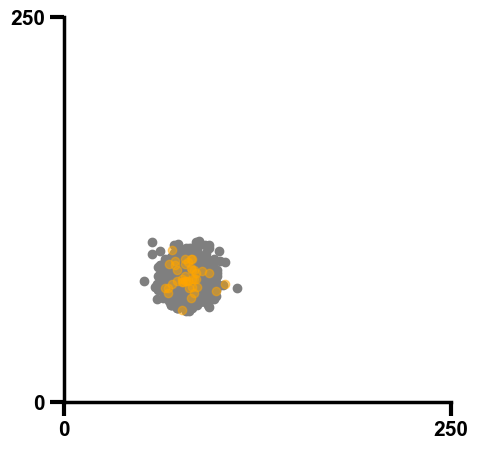

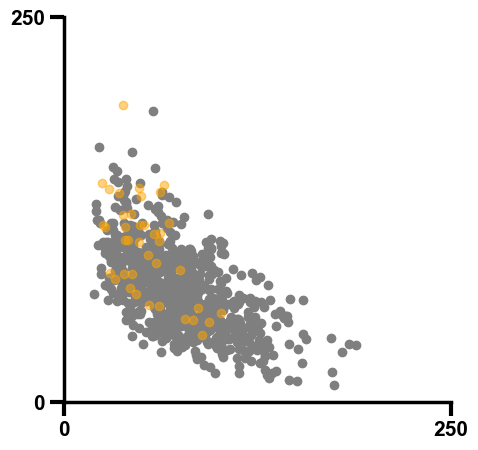

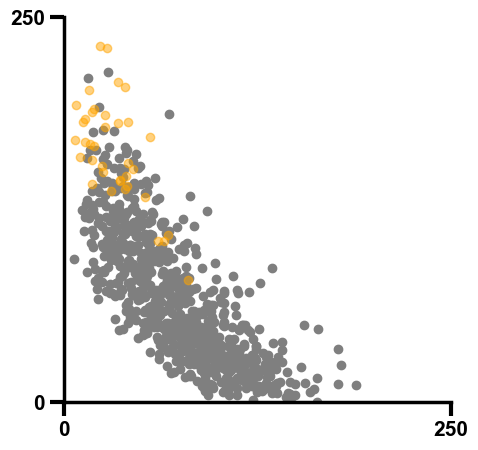

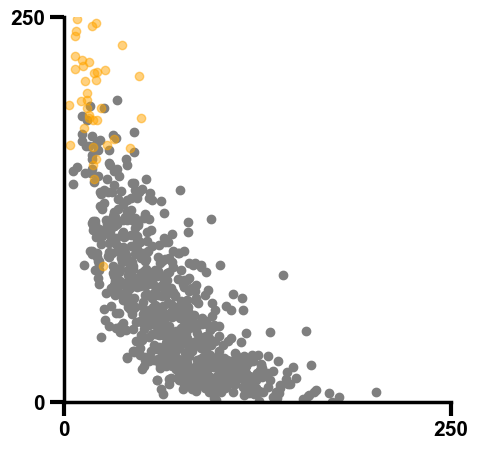

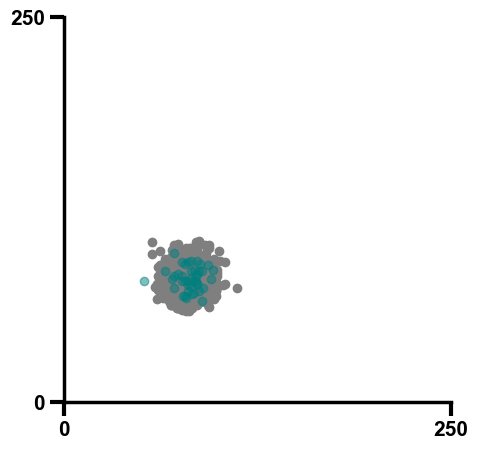

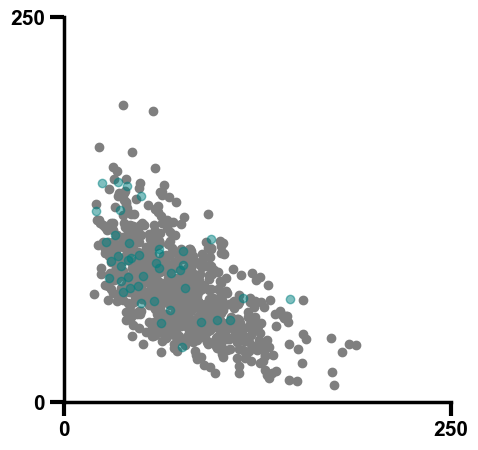

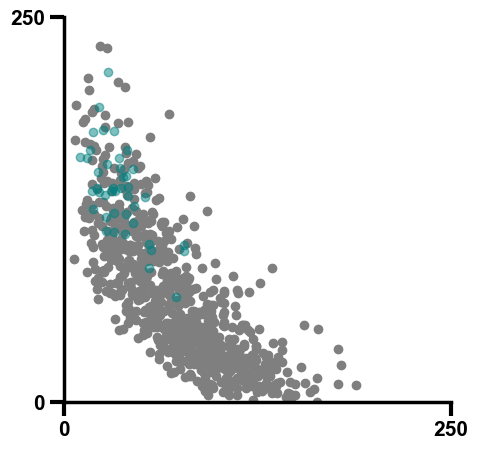

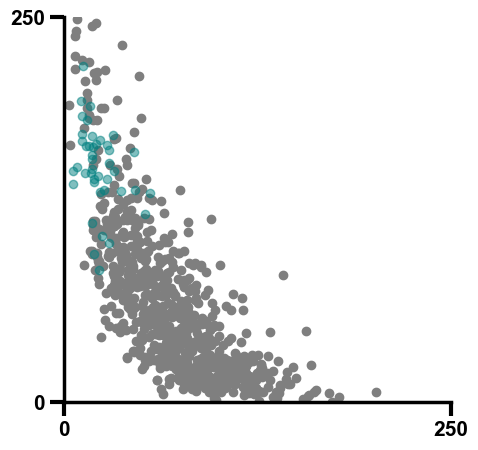

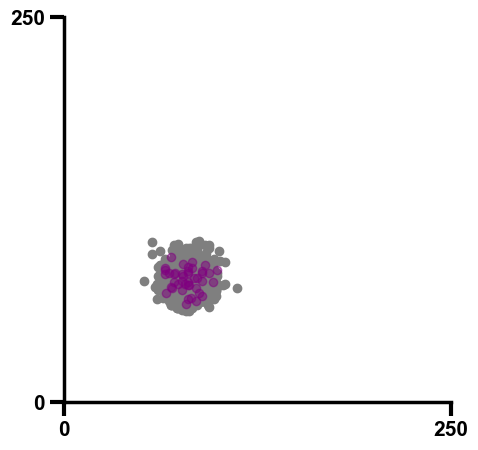

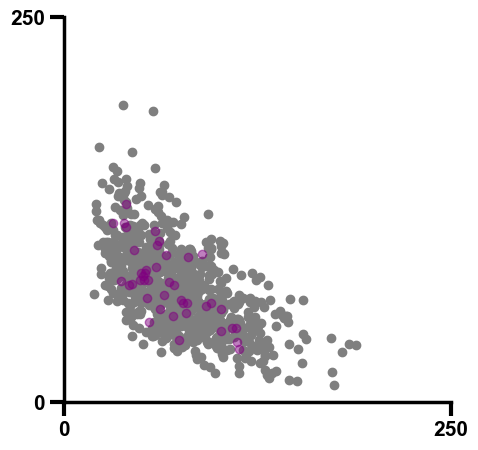

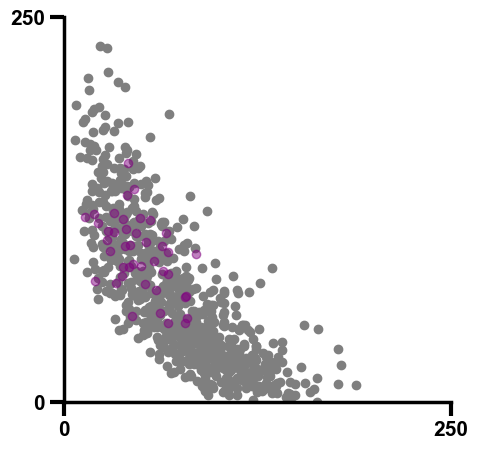

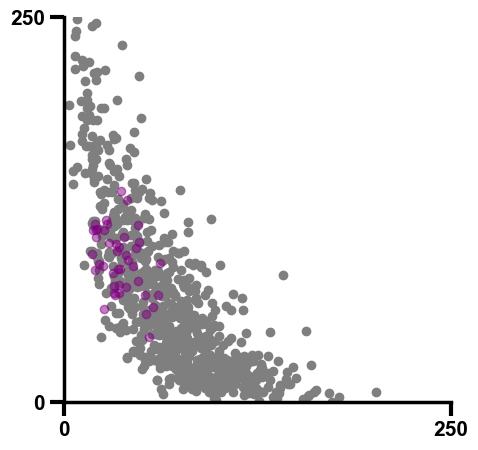

In [33]:

import os

datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/data_5_5/record'
save_dir = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/weight_sum_in_out_pop_individuals'

os.makedirs(save_dir, exist_ok=True)

times = [0, 50, 200, 1200]
pops = [[0], [1], [2]]   # 각 pop을 개별적으로 color coding

for pop in pops:
    pop_tag = '_'.join(str(p) for p in pop)   # 예: pop=[0] -> '0'
    for time in times:
        save_path = os.path.join(
            save_dir,
            f'figure3_weightsum_pop{pop_tag}_time{time}s.svg'
        )
        weight_sum_in_out_plot(
            datapath=datapath,
            save_path=save_path,
            time=time,
            pop=pop
        )

/home/inhoi/anaconda3/envs/gennenv/lib/python3.9/site-packages/matplotlib/lines.py:1206: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  neq = current != val


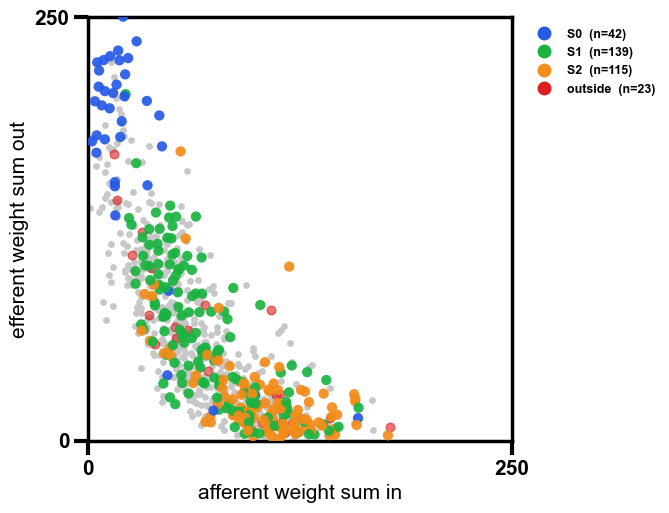

interval별 발화 수: [42, 139, 115]
  S0∩S1: 0
  S0∩S2: 0
  S1∩S2: 0
  전체 공통: 0
바깥 발화: 23 | 미발화: 481


In [7]:
spike_interval_overlap_plot(spikepath='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/csv',
                                     weightpath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/record',
                                      save_path='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/spike_over_time_8540_overlap_in_single_frame.svg',
                                       weight_time = 8540, intervals = [(8540515,8540518), (8540523,8540530), (8540532,8540541)],  context = (8540515, 8540546))

10738891-10738892ms | fired=1, bg(gray)=1599, out(red)=1, single=0, multi=0
10738892-10738893ms | fired=29, bg(gray)=1571, out(red)=0, single=29, multi=0
10738893-10738894ms | fired=13, bg(gray)=1587, out(red)=0, single=13, multi=0
10738894-10738895ms | fired=2, bg(gray)=1598, out(red)=2, single=0, multi=0
10738895-10738896ms | fired=3, bg(gray)=1597, out(red)=3, single=0, multi=0
10738896-10738897ms | fired=4, bg(gray)=1596, out(red)=4, single=0, multi=0
10738897-10738898ms | fired=3, bg(gray)=1597, out(red)=3, single=0, multi=0
10738898-10738899ms | fired=3, bg(gray)=1597, out(red)=0, single=3, multi=0
10738899-10738900ms | fired=5, bg(gray)=1595, out(red)=0, single=5, multi=0
10738900-10738901ms | fired=5, bg(gray)=1595, out(red)=0, single=5, multi=0
10738901-10738902ms | fired=18, bg(gray)=1582, out(red)=0, single=18, multi=0
10738902-10738903ms | fired=18, bg(gray)=1582, out(red)=0, single=18, multi=0
10738903-10738904ms | fired=14, bg(gray)=1586, out(red)=0, single=14, multi=0
10

/home/inhoi/anaconda3/envs/gennenv/lib/python3.9/site-packages/matplotlib/lines.py:1206: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  neq = current != val


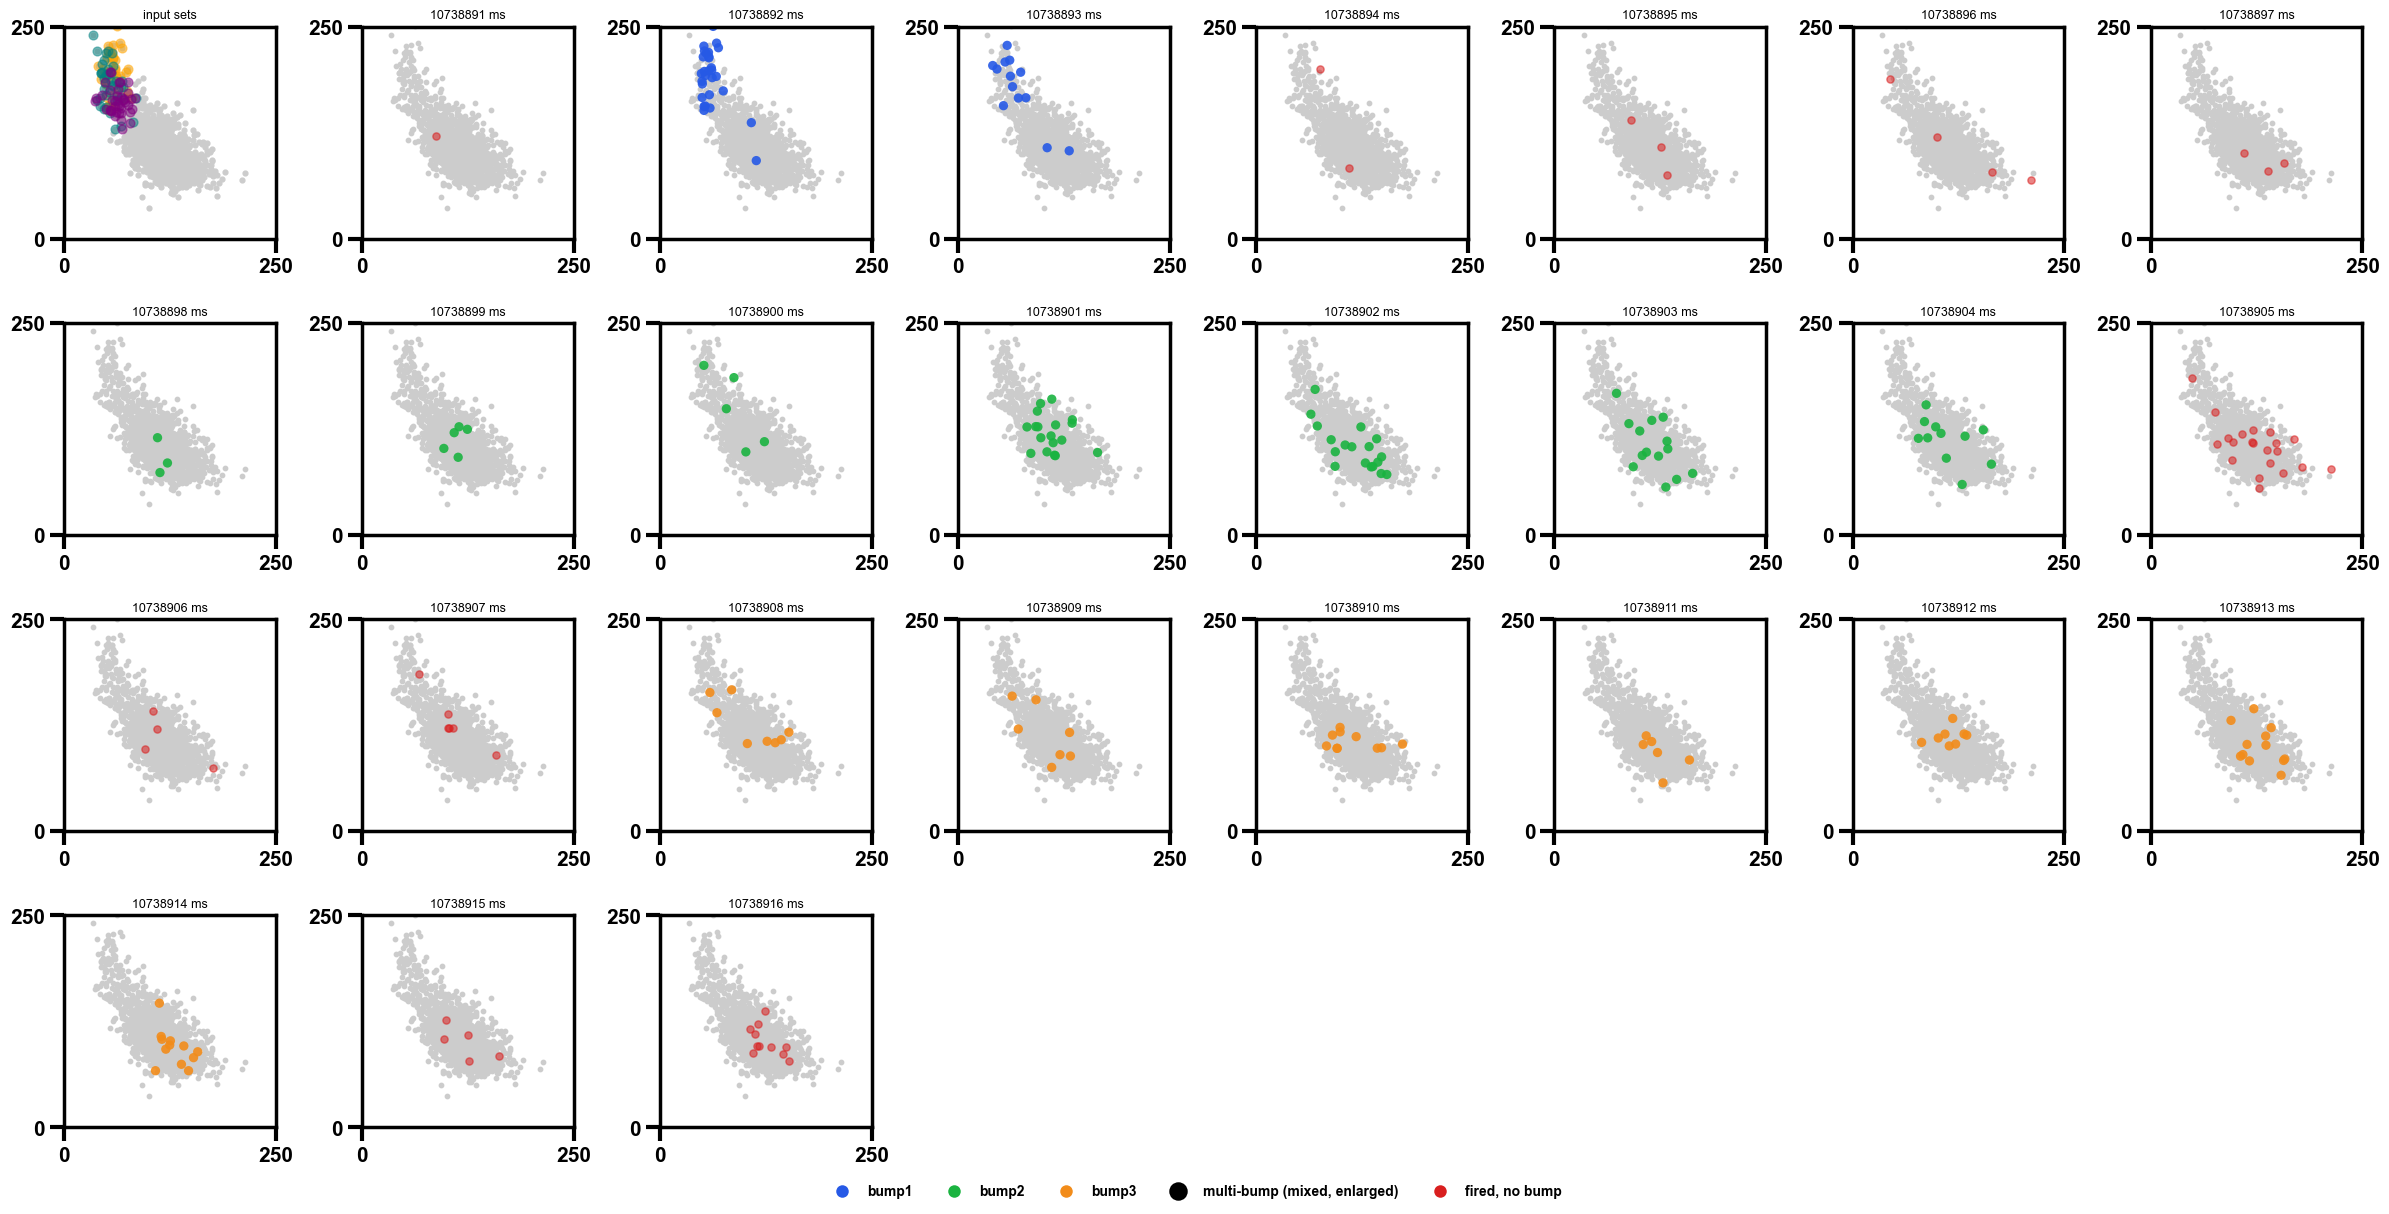

In [ ]:
#size scale factor 2

spike_bump_frames_plot(spikepath='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_size_scale_factor2(1)/csv',
                                     weightpath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_size_scale_factor2(1)/record',
                                      save_path= '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_size_scale_factor2(1)/spike_over_time_10740.svg',
                                       weight_time = 10740, bump_intervals = [(10738892,10738894), (10738898,10738905), (10738908,10738915)],  t_start=10738891, t_end=10738917, bin_ms= 1, matrix_size= 1600)

In [ ]:
#delay 1

spike_bump_frames_plot(spikepath='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_delay1(1)/csv',
                                     weightpath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_delay1(1)/record',
                                      save_path= '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_delay1(1)/raster_10783483.svg',
                                       weight_time = 1080, bump_intervals = [(10783483,10783486), (10783483,10783483), (10783483,10783483)],  t_start=10783483, t_end=9080284, bin_ms= 1)

In [ ]:
#delay 9
spike_bump_frames_plot(spikepath='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_delay9(1)/csv',
                                     weightpath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_delay9(1)/record',
                                      save_path='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_delay9(1)/spike_over_time_9080.svg',
                                       weight_time = 9080, bump_intervals = [(9080245,9080248), (9080257,9080266), (9080270,9080277)],  t_start=9080245, t_end=9080284, bin_ms= 1)  

8545027-8545028ms | fired=0, bg(gray)=800, out(red)=0, single=0, multi=0
8545028-8545029ms | fired=33, bg(gray)=767, out(red)=0, single=33, multi=0
8545029-8545030ms | fired=10, bg(gray)=790, out(red)=0, single=10, multi=0
8545030-8545031ms | fired=1, bg(gray)=799, out(red)=1, single=0, multi=0
8545031-8545032ms | fired=2, bg(gray)=798, out(red)=2, single=0, multi=0
8545032-8545033ms | fired=2, bg(gray)=798, out(red)=2, single=0, multi=0
8545033-8545034ms | fired=2, bg(gray)=798, out(red)=2, single=0, multi=0
8545034-8545035ms | fired=1, bg(gray)=799, out(red)=1, single=0, multi=0
8545035-8545036ms | fired=2, bg(gray)=798, out(red)=2, single=0, multi=0
8545036-8545037ms | fired=22, bg(gray)=778, out(red)=0, single=22, multi=0
8545037-8545038ms | fired=40, bg(gray)=760, out(red)=0, single=40, multi=0
8545038-8545039ms | fired=37, bg(gray)=763, out(red)=0, single=37, multi=0
8545039-8545040ms | fired=18, bg(gray)=782, out(red)=0, single=18, multi=0
8545040-8545041ms | fired=21, bg(gray)=

/home/inhoi/anaconda3/envs/gennenv/lib/python3.9/site-packages/matplotlib/lines.py:1206: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  neq = current != val


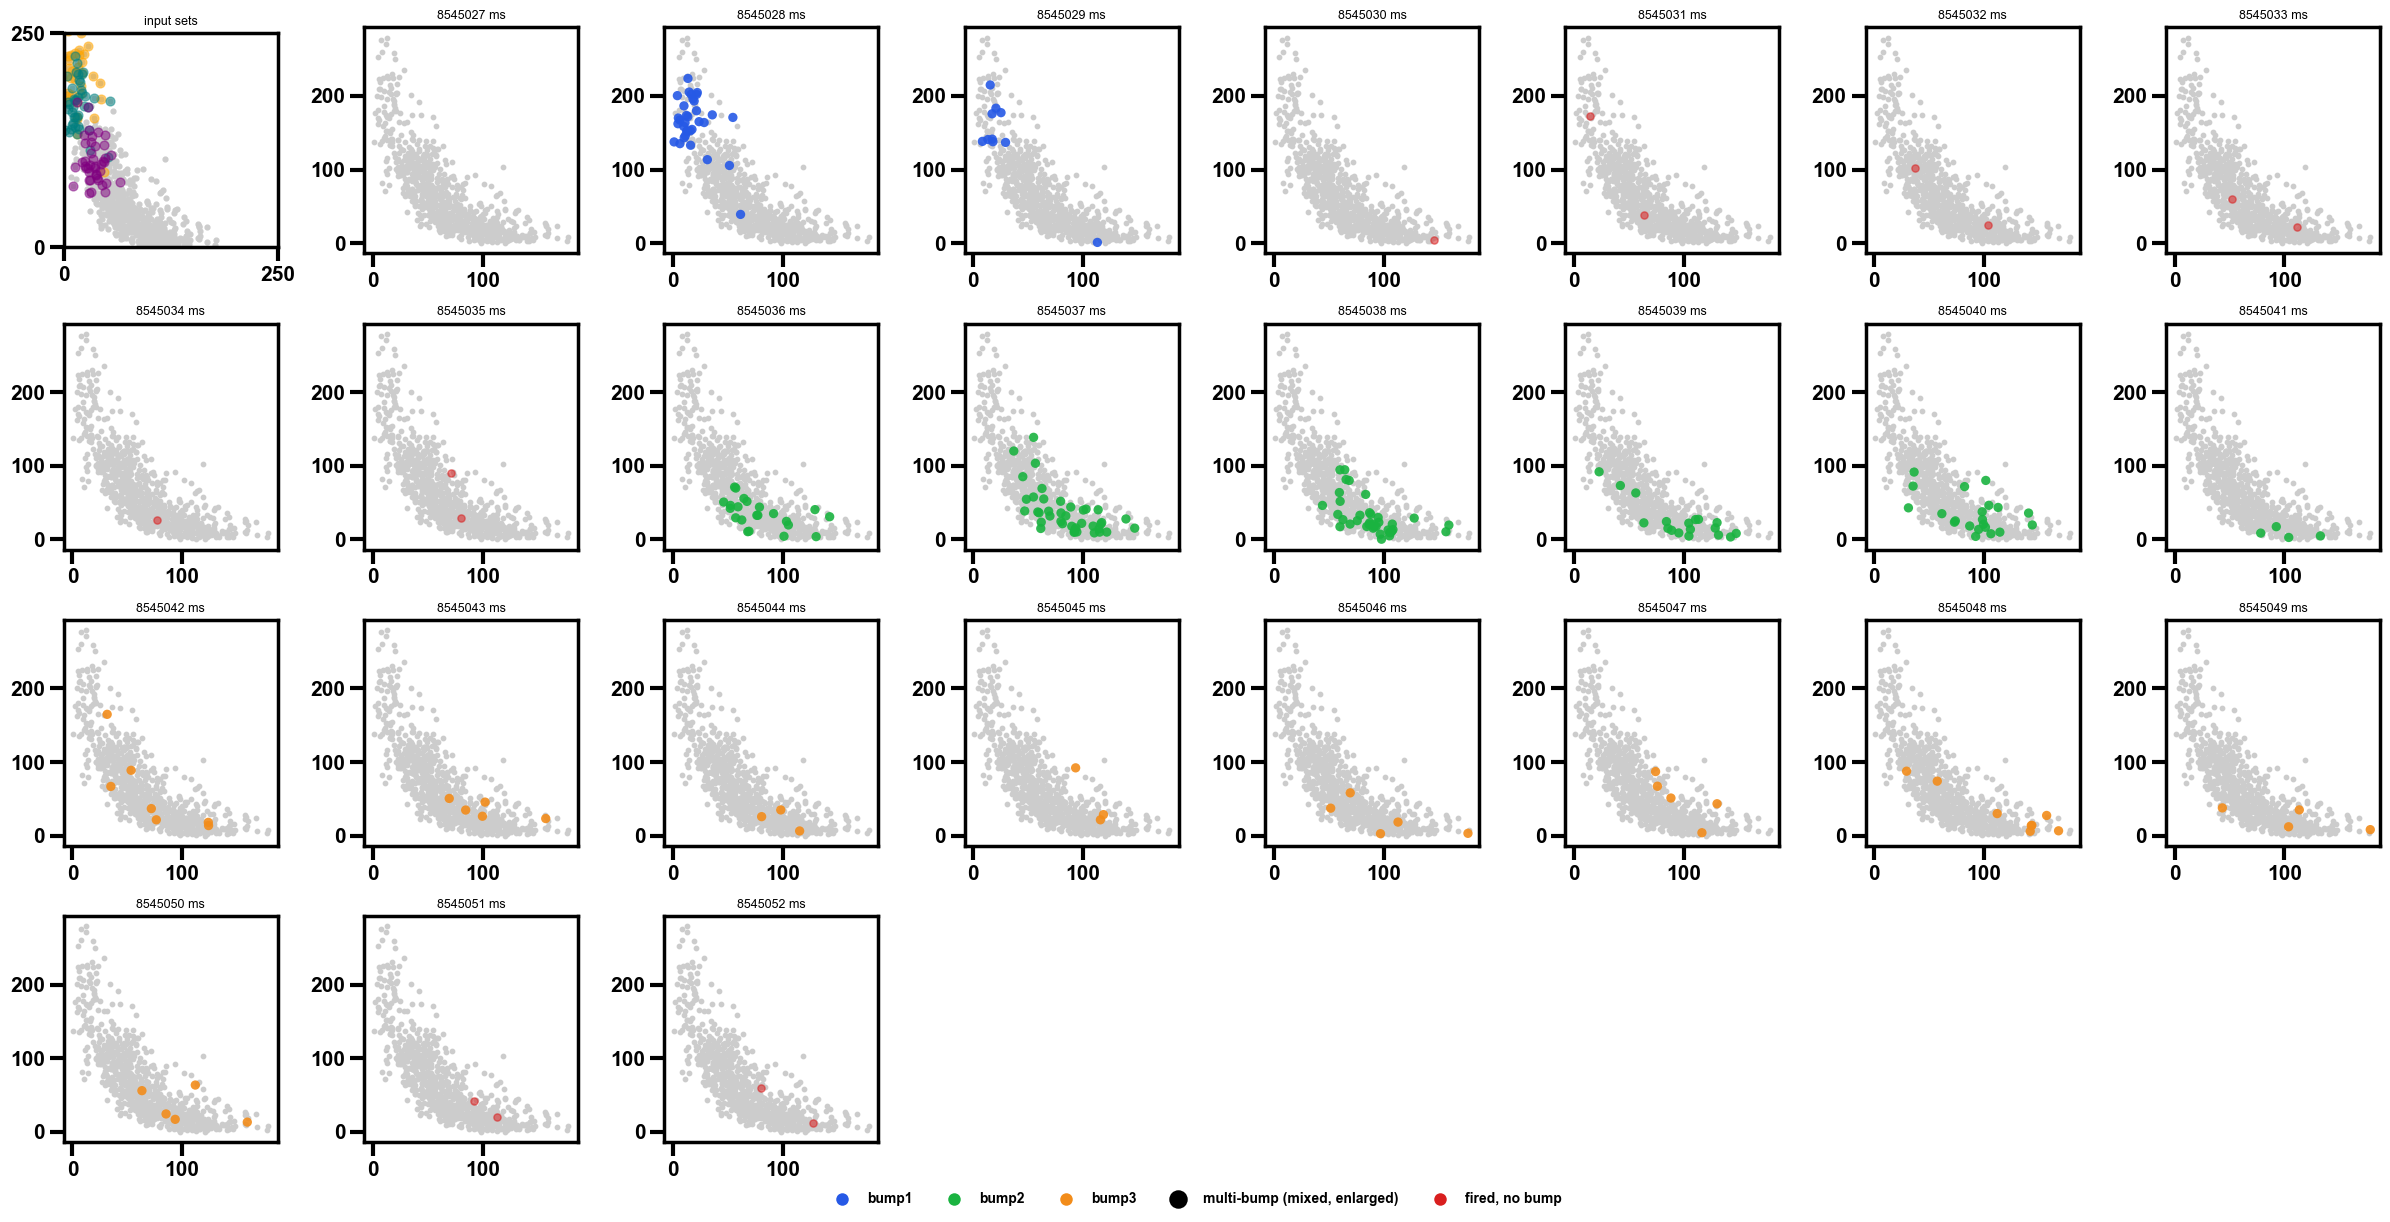

In [31]:
#group1에 대한 response
spike_bump_frames_plot(spikepath='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/csv',
                                     weightpath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/record',
                                      save_path='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/spike_over_time_8545027_overlap(group1_response).svg',
                                       weight_time = 8540, bump_intervals = [(8545027,8545030), (8545036,8545042), (8545042,8545051)],  t_start=8545027, t_end=8545053, bin_ms= 1)  


8533771-8533772ms | fired=0, bg(gray)=800, out(red)=0, single=0, multi=0
8533772-8533773ms | fired=27, bg(gray)=773, out(red)=0, single=27, multi=0
8533773-8533774ms | fired=18, bg(gray)=782, out(red)=0, single=18, multi=0
8533774-8533775ms | fired=2, bg(gray)=798, out(red)=2, single=0, multi=0
8533775-8533776ms | fired=3, bg(gray)=797, out(red)=3, single=0, multi=0
8533776-8533777ms | fired=0, bg(gray)=800, out(red)=0, single=0, multi=0
8533777-8533778ms | fired=1, bg(gray)=799, out(red)=1, single=0, multi=0
8533778-8533779ms | fired=1, bg(gray)=799, out(red)=1, single=0, multi=0
8533779-8533780ms | fired=2, bg(gray)=798, out(red)=0, single=2, multi=0
8533780-8533781ms | fired=9, bg(gray)=791, out(red)=0, single=9, multi=0
8533781-8533782ms | fired=16, bg(gray)=784, out(red)=0, single=16, multi=0
8533782-8533783ms | fired=19, bg(gray)=781, out(red)=0, single=19, multi=0
8533783-8533784ms | fired=18, bg(gray)=782, out(red)=0, single=18, multi=0
8533784-8533785ms | fired=8, bg(gray)=792

/home/inhoi/anaconda3/envs/gennenv/lib/python3.9/site-packages/matplotlib/lines.py:1206: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  neq = current != val


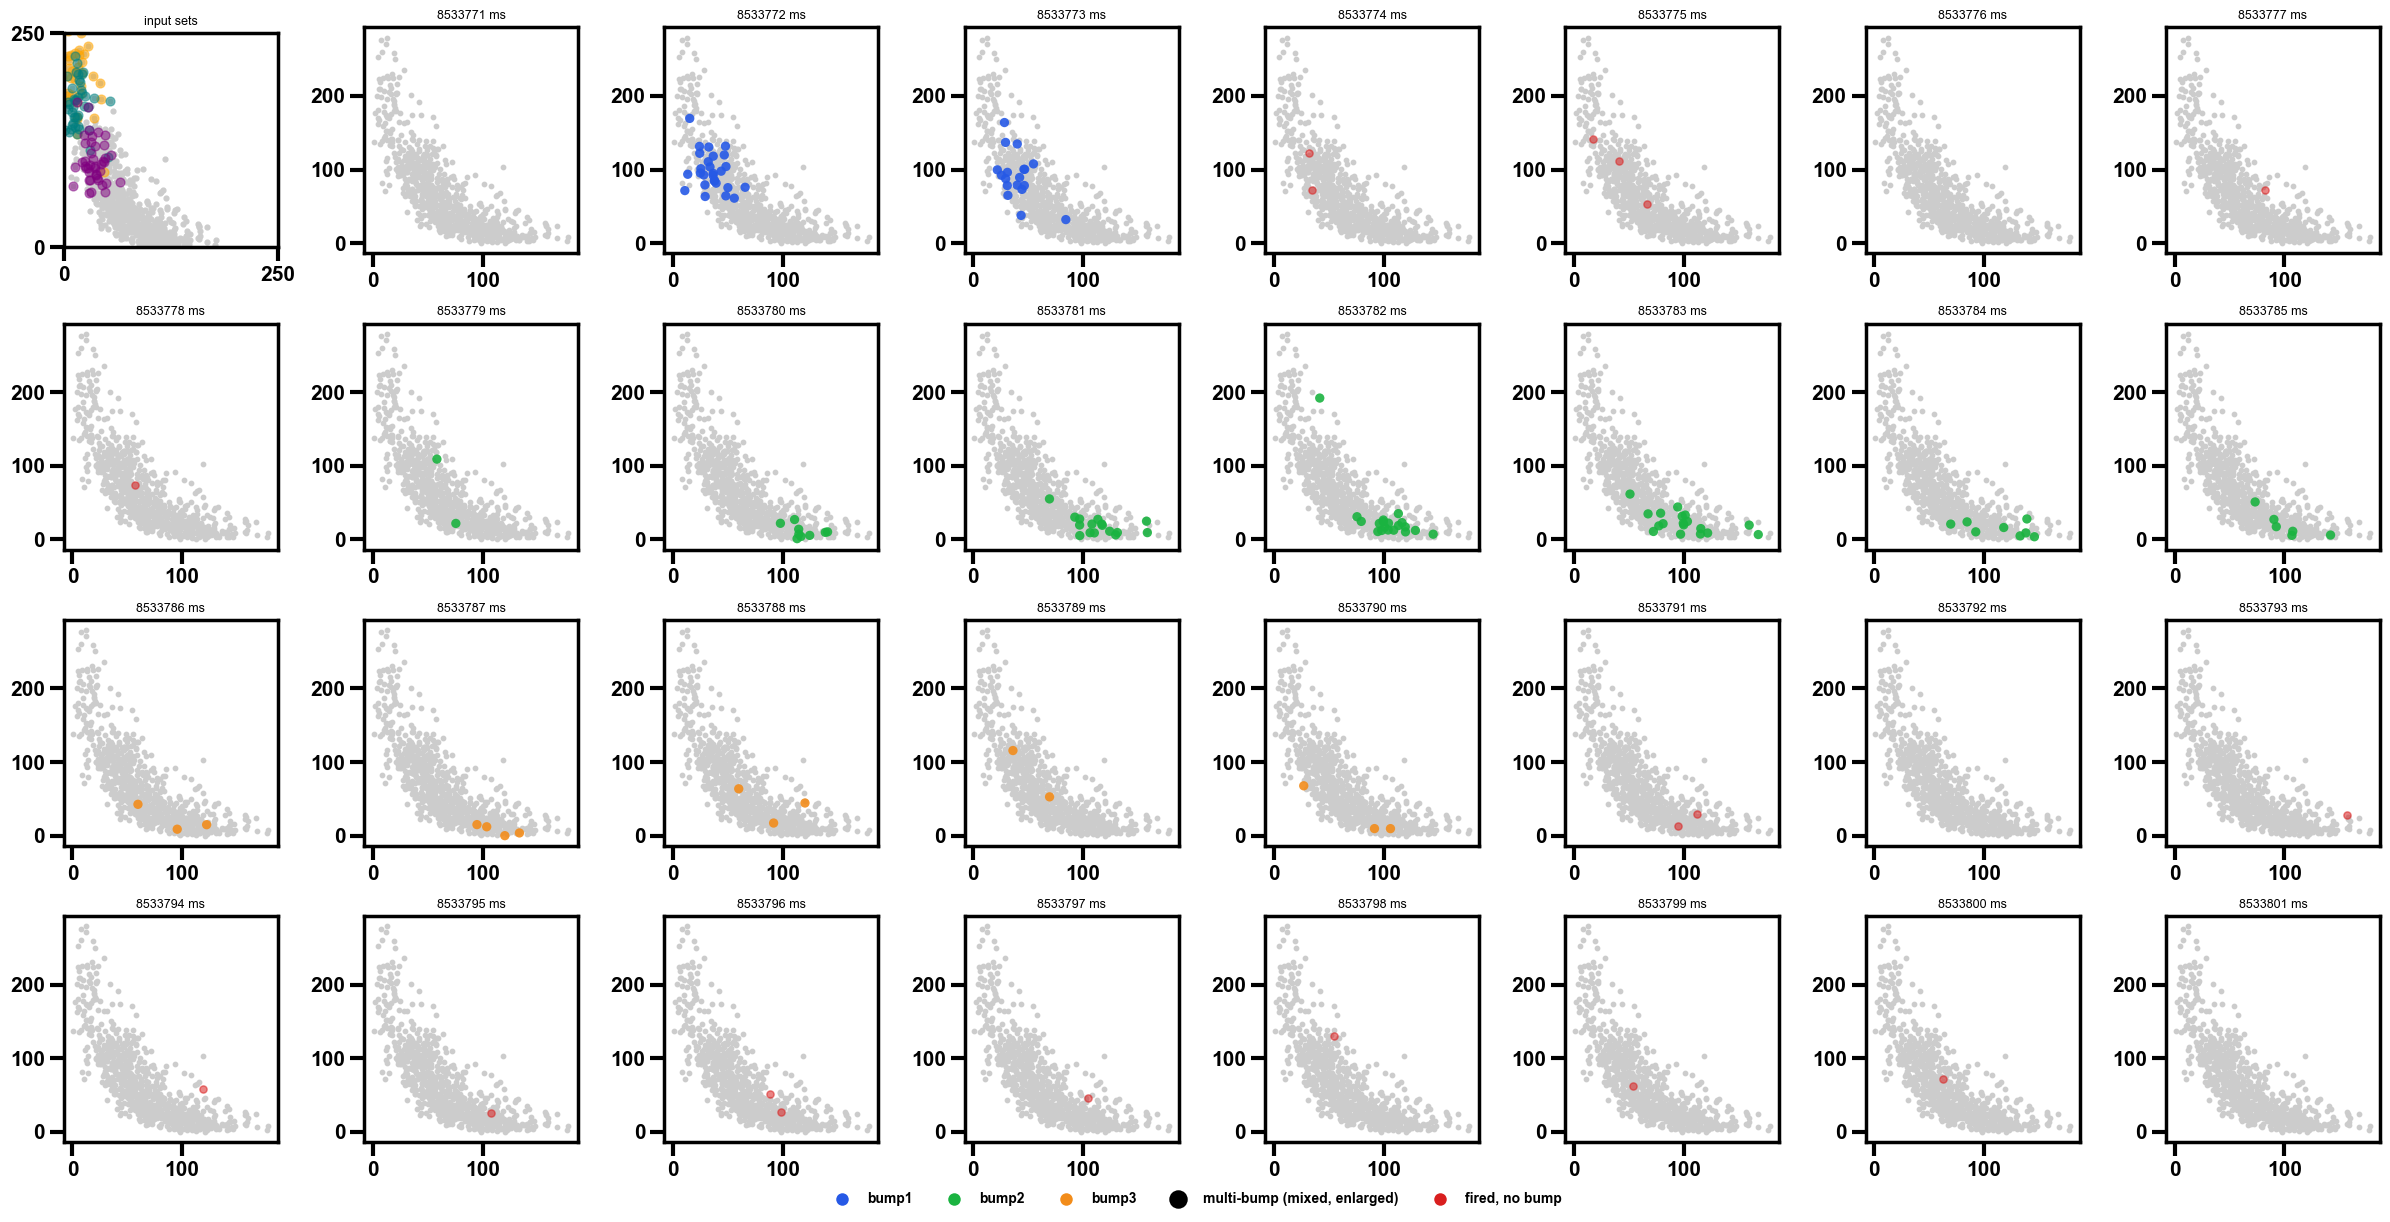

In [44]:
#group2에 대한 response
spike_bump_frames_plot(spikepath='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/csv',
                                     weightpath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/record',
                                      save_path='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/spike_over_time_8533771_overlap(group2_response).svg',
                                       weight_time = 8530, bump_intervals = [(8533771,8533774), (8533779,8533786), (8533786,8533791)],  t_start=8533771, t_end=8533802, bin_ms= 1)  


8540515-8540516ms | fired=1, bg(gray)=799, out(red)=0, single=1, multi=0
8540516-8540517ms | fired=30, bg(gray)=770, out(red)=0, single=30, multi=0
8540517-8540518ms | fired=11, bg(gray)=789, out(red)=0, single=11, multi=0
8540518-8540519ms | fired=1, bg(gray)=799, out(red)=1, single=0, multi=0
8540519-8540520ms | fired=0, bg(gray)=800, out(red)=0, single=0, multi=0
8540520-8540521ms | fired=0, bg(gray)=800, out(red)=0, single=0, multi=0
8540521-8540522ms | fired=3, bg(gray)=797, out(red)=3, single=0, multi=0
8540522-8540523ms | fired=2, bg(gray)=798, out(red)=2, single=0, multi=0
8540523-8540524ms | fired=3, bg(gray)=797, out(red)=0, single=3, multi=0
8540524-8540525ms | fired=19, bg(gray)=781, out(red)=0, single=19, multi=0
8540525-8540526ms | fired=33, bg(gray)=767, out(red)=0, single=33, multi=0
8540526-8540527ms | fired=37, bg(gray)=763, out(red)=0, single=37, multi=0
8540527-8540528ms | fired=21, bg(gray)=779, out(red)=0, single=21, multi=0
8540528-8540529ms | fired=13, bg(gray)=

/home/inhoi/anaconda3/envs/gennenv/lib/python3.9/site-packages/matplotlib/lines.py:1206: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  neq = current != val


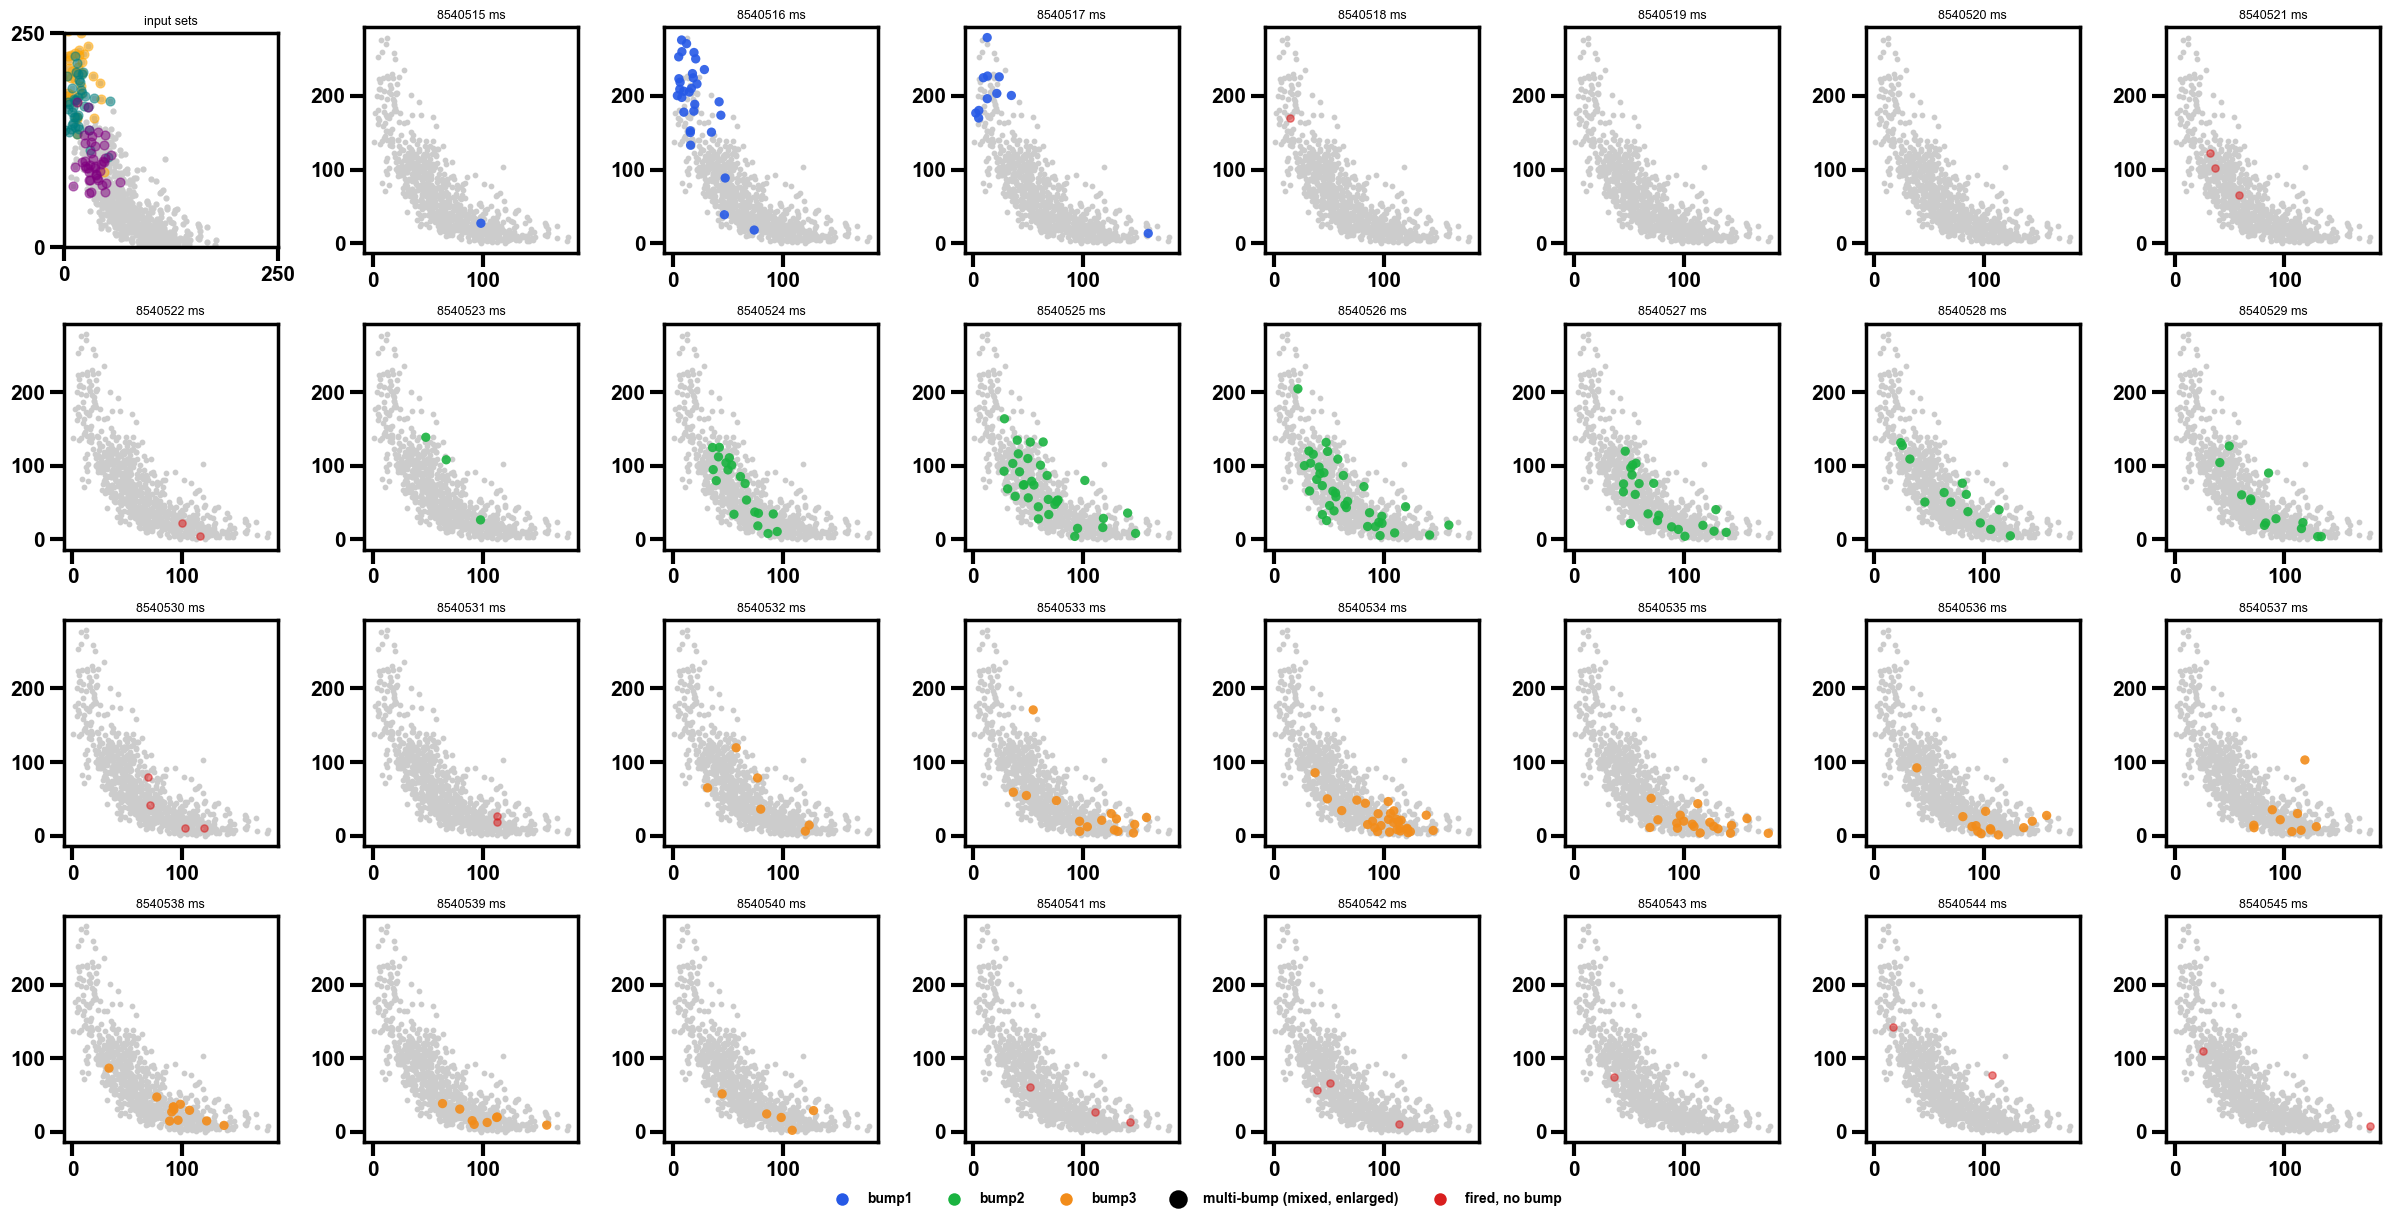

In [47]:
spike_bump_frames_plot(spikepath='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/csv',
                                     weightpath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/record',
                                      save_path='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/spike_over_time_8540_overlap.svg',
                                       weight_time = 8540, bump_intervals = [(8540515,8540518), (8540523,8540530), (8540532,8540541)],  t_start=8540515, t_end=8540546, bin_ms= 1)  

In [29]:
def bump_group_connectivity_sparse(spikepath, weightpath,  weight_time,
                                   bump_intervals, bump_labels=None,
                                   matrix_size=800):
    base = '5,5ms interval, weight in ' + str(weight_time) + 's'
    g    = np.load(os.path.join(weightpath, base + '_data.npy'))
    pre  = np.load(os.path.join(weightpath, base + '_row.npy')).astype(np.int64)
    post = np.load(os.path.join(weightpath, base + '_col.npy')).astype(np.int64)

    # --- bump 그룹 ---
    exc = pd.read_csv(os.path.join(spikepath, '5_5_izhikevich_e_spikes.csv'), header=0)
    t   = exc["Time [ms]"].values
    nid = exc[" Neuron ID"].values.astype(int)
    groups, gmask = [], []
    for lo, hi in bump_intervals:
        m = (t >= lo) & (t < hi) & (nid < matrix_size)
        ids = np.unique(nid[m])
        groups.append(ids)
        mk = np.zeros(matrix_size, bool); mk[ids] = True
        gmask.append(mk)
    n = len(groups)
    if bump_labels is None:
        bump_labels = ['bump%d' % (i+1) for i in range(n)]

    # 각 연결의 pre/post 가 어느 그룹인지
    pre_grp  = -np.ones(matrix_size, np.int64)
    post_grp = -np.ones(matrix_size, np.int64)
    for i in range(n):
        pre_grp[groups[i]]  = i     # 그룹 disjoint 전제 (앞서 교집합 0 확인됨)
        post_grp[groups[i]] = i

    gp, qp = pre_grp[pre], post_grp[post]

    mean_conn = np.full((n, n), np.nan)  # 존재 연결만 평균 (0 weight 도 '존재'로 포함)
    mean_all  = np.zeros((n, n))         # 가능한 모든 쌍 평균
    density   = np.zeros((n, n))
    n_edges   = np.zeros((n, n), int)
    for i in range(n):
        for j in range(n):
            sel = (gp == i) & (qp == j)        # 그룹 i->j 에 '존재하는' 연결
            w = g[sel]
            npair = len(groups[i]) * len(groups[j])
            n_edges[i, j]   = sel.sum()
            mean_conn[i, j] = w.mean() if w.size else np.nan
            mean_all[i, j]  = w.sum() / npair if npair else 0.0
            density[i, j]   = sel.sum() / npair if npair else 0.0

    print('그룹 크기:', [len(g_) for g_ in groups])
    print('연결 수(edge count):\n', n_edges)
    print('(A) 존재 연결만 평균:\n', np.round(mean_conn, 3))
    print('(B) 모든 쌍 평균:\n', np.round(mean_all, 3))
    print('density:\n', np.round(density, 3))

    # heatmap 은 기존과 동일하게 그리면 됨 (mean_conn, mean_all)
    return mean_conn, mean_all, density, n_edges, groups



def plot_bump_connectivity_all(mean_conn, mean_all, density, groups,
                               save_path, bump_labels=None):
    n = mean_conn.shape[0]
    if bump_labels is None:
        bump_labels = ['bump%d' % (i+1) for i in range(n)]

    # (D) effective drive = B * sending group size (행=pre 방향으로 곱)
    sending_size = np.array([len(g_) for g_ in groups])
    eff = mean_all * sending_size[:, None]

    panels = [(mean_conn, '(A) mean of existing weights',        'viridis', '%.2f'),
              (mean_all,  '(B) mean over all pairs',             'viridis', '%.2f'),
              (density,   '(C) connection density',              'magma',   '%.2f'),
              (eff,       '(D) effective drive',   'viridis', '%.1f')]

    fig, axes = plt.subplots(1, 4, figsize=(21, 5))
    for ax, (M, title, cmap, fmt) in zip(axes, panels):
        im = ax.imshow(M, cmap=cmap, vmin=0)
        ax.set_xticks(range(n)); ax.set_xticklabels(bump_labels)
        ax.set_yticks(range(n)); ax.set_yticklabels(bump_labels)
        ax.set_xlabel('post (receiving bump)')
        ax.set_ylabel('pre (sending bump)')
        ax.set_title(title, fontsize=12)
        vmin, vmax = np.nanmin(M), np.nanmax(M)
        for i in range(n):
            for j in range(n):
                val = M[i, j]
                if np.isnan(val):
                    txt, norm = '—', 0
                else:
                    txt = fmt % val
                    norm = (val - vmin) / (vmax - vmin + 1e-9)
                ax.text(j, i, txt, ha='center', va='center',
                        color='k' if norm > 0.5 else 'w',
                        fontsize=12, fontweight='bold')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(save_path, format='png', transparent=True, bbox_inches='tight')
    plt.show()
    return eff

def group_connectivity_from_input_sets(weightpath, weight_time,
                                       set_labels=None, matrix_size=800,
                                       n_sets=3):
    base = '5,5ms interval, weight in ' + str(weight_time) + 's'
    g    = np.load(os.path.join(weightpath, base + '_data.npy'))
    pre  = np.load(os.path.join(weightpath, base + '_row.npy')).astype(np.int64)
    post = np.load(os.path.join(weightpath, base + '_col.npy')).astype(np.int64)

    # --- 그룹 = input_sets (bump 대신) ---
    input_sets = np.load(os.path.join(weightpath, '5,5ms interval, input_sets.npy'))
    groups = [np.unique(input_sets[i][input_sets[i] < matrix_size]) for i in range(n_sets)]
    n = len(groups)
    if set_labels is None:
        set_labels = ['S%d' % i for i in range(n)]     # S0, S1, S2

    # 각 연결의 pre/post 가 어느 그룹인지
    pre_grp  = -np.ones(matrix_size, np.int64)
    post_grp = -np.ones(matrix_size, np.int64)
    for i in range(n):
        pre_grp[groups[i]]  = i
        post_grp[groups[i]] = i
    gp, qp = pre_grp[pre], post_grp[post]

    mean_conn = np.full((n, n), np.nan)
    mean_all  = np.zeros((n, n))
    density   = np.zeros((n, n))
    n_edges   = np.zeros((n, n), int)
    for i in range(n):
        for j in range(n):
            sel = (gp == i) & (qp == j)
            w = g[sel]
            npair = len(groups[i]) * len(groups[j])
            n_edges[i, j]   = sel.sum()
            mean_conn[i, j] = w.mean() if w.size else np.nan
            mean_all[i, j]  = w.sum() / npair if npair else 0.0
            density[i, j]   = sel.sum() / npair if npair else 0.0

    print('그룹 크기:', [len(g_) for g_ in groups])
    print('연결 수(edge count):\n', n_edges)
    print('(A) 존재 연결만 평균:\n', np.round(mean_conn, 3))
    print('(B) 모든 쌍 평균:\n', np.round(mean_all, 3))
    print('density:\n', np.round(density, 3))
    return mean_conn, mean_all, density, n_edges, groups

def plot_group_connectivity_all(mean_conn, mean_all, density, groups,
                                save_path, group_labels=None,
                                pre_axis_label='pre (sending set)',
                                post_axis_label='post (receiving set)'):
    n = mean_conn.shape[0]
    if group_labels is None:
        group_labels = ['S%d' % i for i in range(n)]

    sending_size = np.array([len(g_) for g_ in groups])
    eff = mean_all * sending_size[:, None]

    panels = [(mean_conn, '(A) mean of existing weights', 'viridis', '%.2f'),
              (mean_all,  '(B) mean over all pairs',      'viridis', '%.2f'),
              (density,   '(C) connection density',       'magma',   '%.2f'),
              (eff,       '(D) effective drive',          'viridis', '%.1f')]

    fig, axes = plt.subplots(1, 4, figsize=(21, 5))
    for ax, (M, title, cmap, fmt) in zip(axes, panels):
        im = ax.imshow(M, cmap=cmap, vmin=0)
        ax.set_xticks(range(n)); ax.set_xticklabels(group_labels)
        ax.set_yticks(range(n)); ax.set_yticklabels(group_labels)
        ax.set_xlabel(post_axis_label)
        ax.set_ylabel(pre_axis_label)
        ax.set_title(title, fontsize=12)
        vmin, vmax = np.nanmin(M), np.nanmax(M)
        for i in range(n):
            for j in range(n):
                val = M[i, j]
                if np.isnan(val):
                    txt, norm = '—', 0
                else:
                    txt = fmt % val
                    norm = (val - vmin) / (vmax - vmin + 1e-9)
                ax.text(j, i, txt, ha='center', va='center',
                        color='k' if norm > 0.5 else 'w',
                        fontsize=12, fontweight='bold')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(save_path, format='png', transparent=True, bbox_inches='tight')
    plt.show()
    return eff

그룹 크기: [39, 42, 42]
연결 수(edge count):
 [[122 123 166]
 [128 154 168]
 [139 174 165]]
(A) 존재 연결만 평균:
 [[0.079 3.409 3.802]
 [0.    0.38  2.886]
 [0.008 0.054 0.698]]
(B) 모든 쌍 평균:
 [[0.006 0.256 0.385]
 [0.    0.033 0.275]
 [0.001 0.005 0.065]]
density:
 [[0.08  0.075 0.101]
 [0.078 0.087 0.095]
 [0.085 0.099 0.094]]


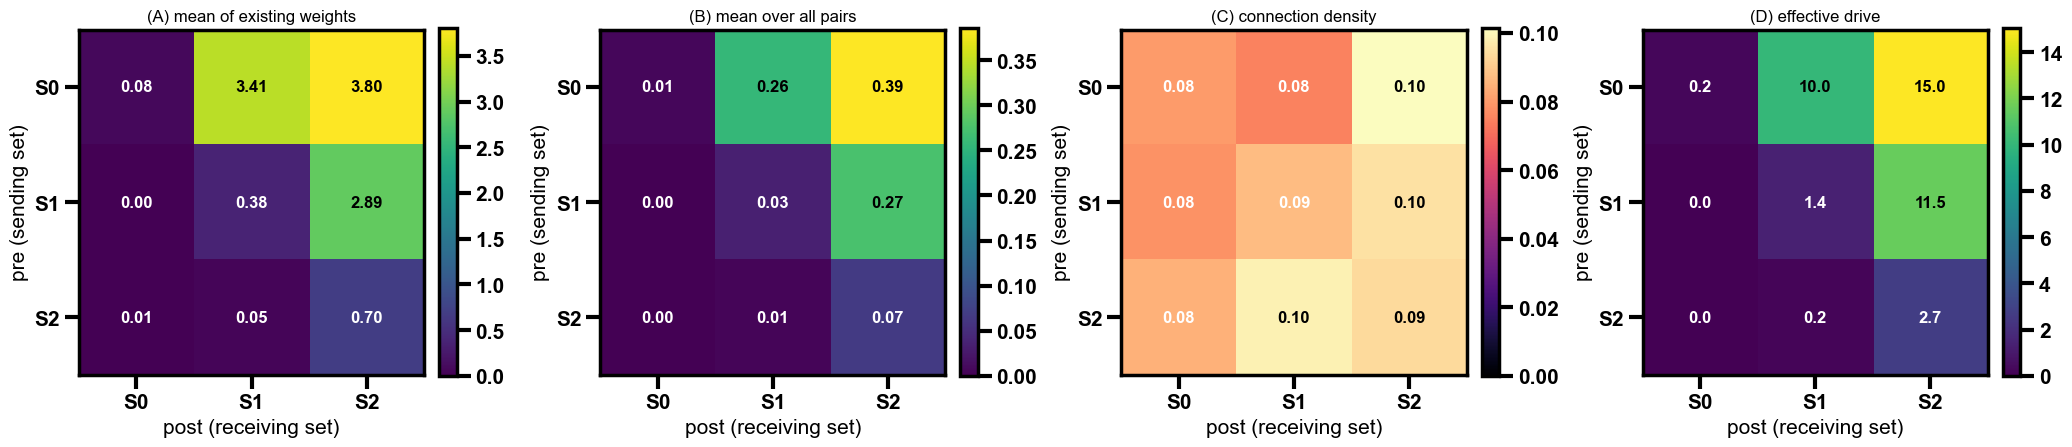

array([[2.46934527e-01, 9.98408350e+00, 1.50274691e+01],
       [5.03824194e-04, 1.39449093e+00, 1.15457188e+01],
       [2.70997728e-02, 2.22890361e-01, 2.74221777e+00]])

In [57]:
#bumps가 아니라 input sets 끼리 connectivity 분석
mean_conn, mean_all, density, n_edges, groups = group_connectivity_from_input_sets(
    weightpath='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_delay1(1)/record', weight_time=10660)
plot_group_connectivity_all(mean_all= mean_all, mean_conn= mean_conn, density = density, groups = groups, save_path='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_delay1(1)/connectivity btw input sets 012.svg')

그룹 크기: [39, 210, 145]
연결 수(edge count):
 [[ 164 1104  447]
 [ 791 4259 3177]
 [ 573 3006 2152]]
(A) 존재 연결만 평균:
 [[0.053 3.638 2.919]
 [0.307 0.529 2.012]
 [0.485 0.466 0.62 ]]
(B) 모든 쌍 평균:
 [[0.006 0.49  0.231]
 [0.03  0.051 0.21 ]
 [0.049 0.046 0.063]]
density:
 [[0.108 0.135 0.079]
 [0.097 0.097 0.104]
 [0.101 0.099 0.102]]


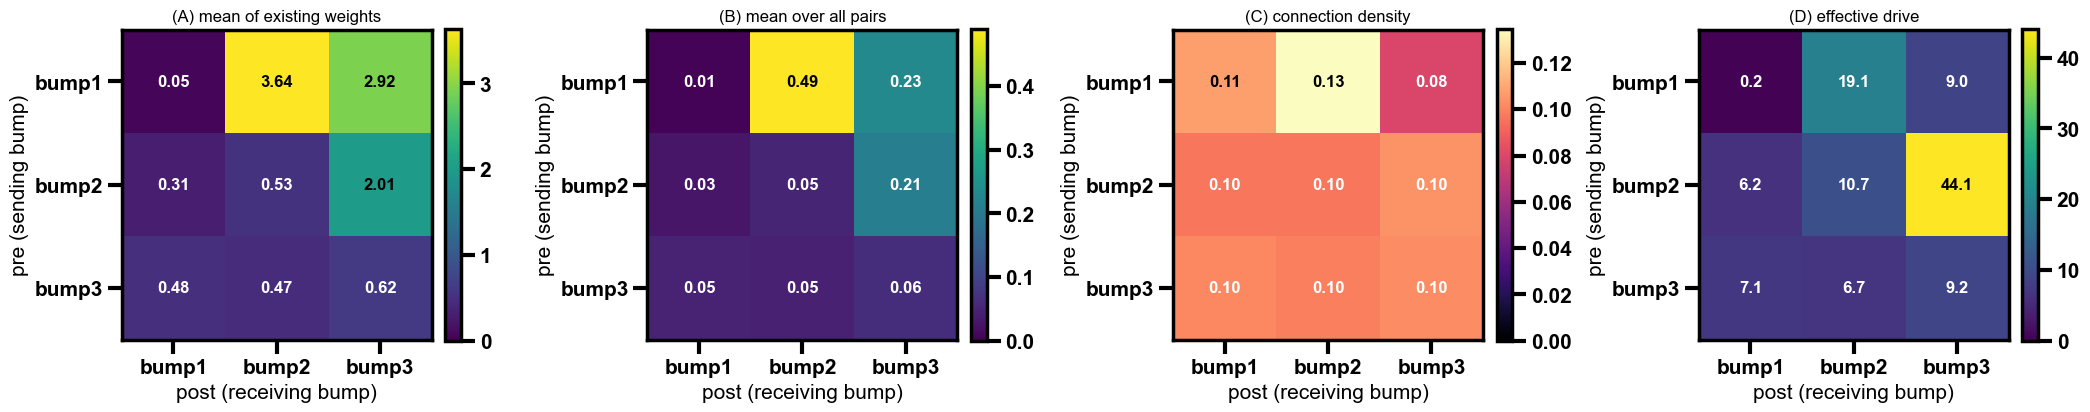

array([[ 0.22219449, 19.12691734,  8.99923439],
       [ 6.22638897, 10.7299443 , 44.07399902],
       [ 7.12316806,  6.66515605,  9.20373122]])

In [55]:
#group 0 response in 9ms delay

mean_conn, mean_all, density, n_edges, groups = bump_group_connectivity_sparse(spikepath='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_delay9(1)/csv',
                        weight_time= 9080, weightpath= '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_delay9(1)/record',
                         
                         bump_intervals = [(9080245,9080248), (9080257,9080266), (9080270,9080277)], )
plot_bump_connectivity_all(mean_all= mean_all, mean_conn= mean_conn, density = density, groups = groups, save_path='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_delay9(1)/connectivity btw bumps(group0 only response_9080).svg')

그룹 크기: [42, 139, 115]
연결 수(edge count):
 [[ 183  786  391]
 [ 580 1922 1766]
 [ 492 1634 1305]]
(A) 존재 연결만 평균:
 [[0.203 3.188 2.81 ]
 [0.207 0.681 1.526]
 [0.177 0.334 0.413]]
(B) 모든 쌍 평균:
 [[0.021 0.429 0.227]
 [0.021 0.068 0.169]
 [0.018 0.034 0.041]]
density:
 [[0.104 0.135 0.081]
 [0.099 0.099 0.11 ]
 [0.102 0.102 0.099]]


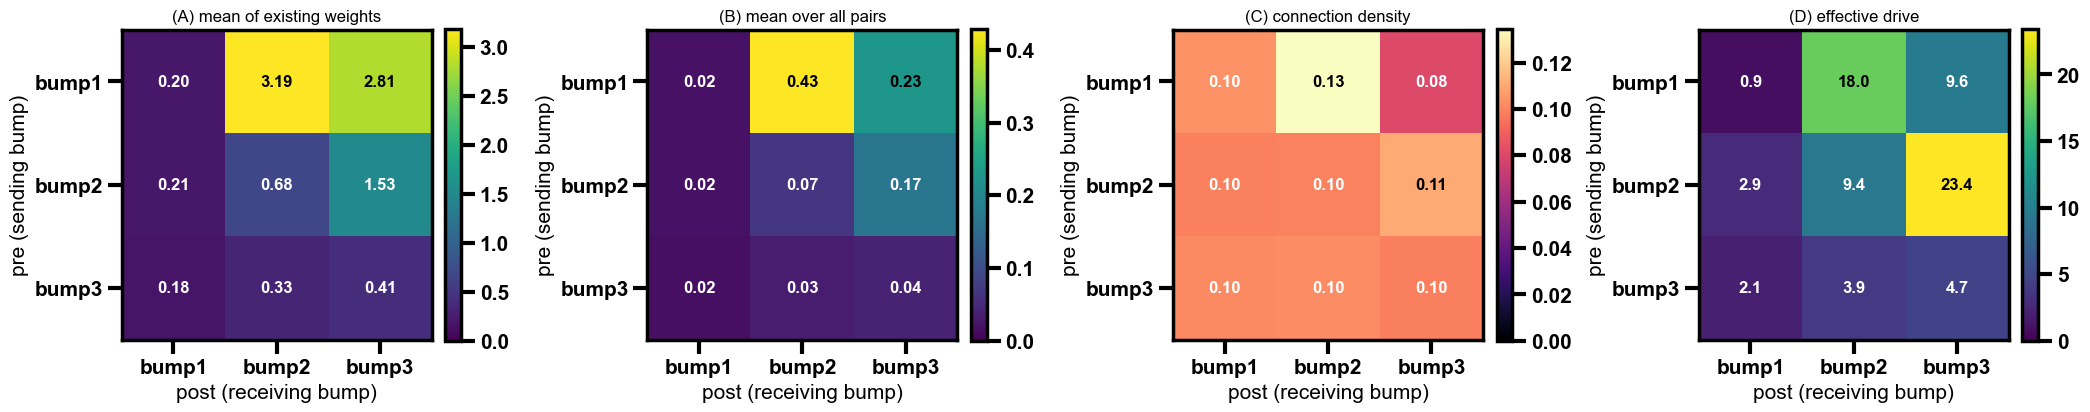

array([[ 0.88467775, 18.02614451,  9.55361012],
       [ 2.8561927 ,  9.41649511, 23.42667954],
       [ 2.06991039,  3.92826226,  4.68616888]])

In [46]:
#group 0 response
mean_conn, mean_all, density, n_edges, groups = bump_group_connectivity_sparse(spikepath='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/csv',
                        weight_time= 8540, weightpath= '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/record',
                         
                         bump_intervals = [(8540515,8540518), (8540523,8540530), (8540532,8540541)], )
plot_bump_connectivity_all(mean_all= mean_all, mean_conn= mean_conn, density = density, groups = groups, save_path='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/connectivity btw bumps(group0 only response_8540).svg')

그룹 크기: [45, 78, 15]
연결 수(edge count):
 [[190 443  58]
 [343 625 118]
 [ 53 112  19]]
(A) 존재 연결만 평균:
 [[0.19  2.918 2.531]
 [0.111 0.296 0.168]
 [0.266 0.672 0.474]]
(B) 모든 쌍 평균:
 [[0.018 0.368 0.218]
 [0.011 0.03  0.017]
 [0.021 0.064 0.04 ]]
density:
 [[0.094 0.126 0.086]
 [0.098 0.103 0.101]
 [0.079 0.096 0.084]]


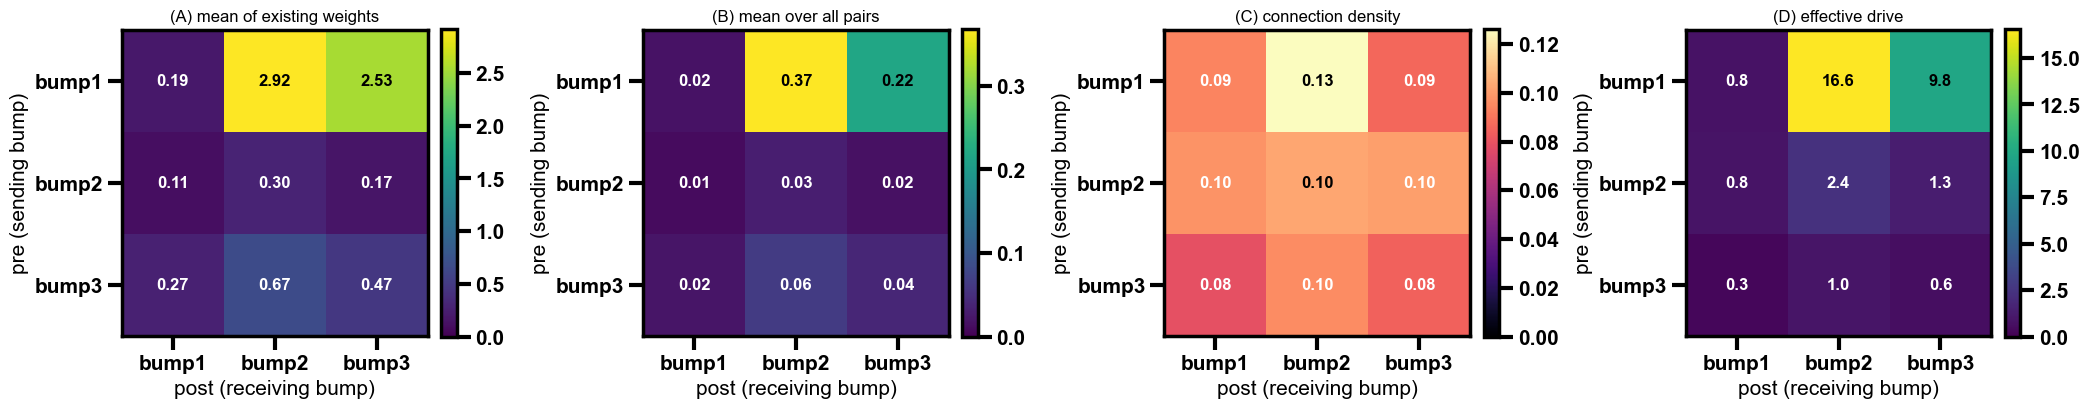

array([[ 0.80092016, 16.57435383,  9.7879789 ],
       [ 0.84593145,  2.37165055,  1.32129377],
       [ 0.3133125 ,  0.96493648,  0.59997469]])

In [45]:

#group 2 response
mean_conn, mean_all, density, n_edges, groups = bump_group_connectivity_sparse(spikepath='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/csv',
                        weight_time= 8530, weightpath= '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/record',
                         
                         bump_intervals = [(8533771,8533774), (8533779,8533786), (8533786,8533791)], )
plot_bump_connectivity_all(mean_all= mean_all, mean_conn= mean_conn, density = density, groups = groups, save_path='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/connectivity btw bumps(group2 only response).svg')

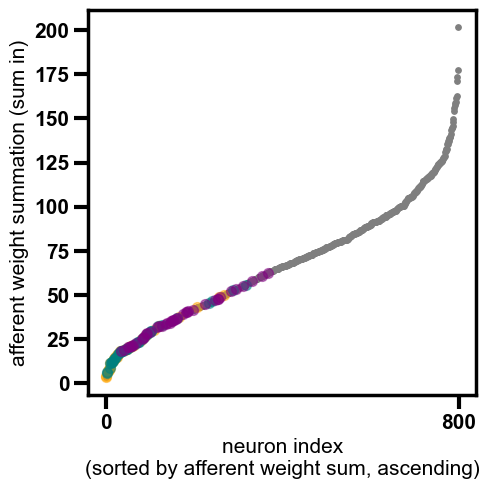

In [10]:
def afferent_sum_ascending_plot(datapath, save_path, time,
                                matrix_size=800, show_groups=True):
    # --- 원본 sparse 로드 ---
    g    = np.load(os.path.join(datapath, '5,5ms interval, weight in ' + str(time) + 's_data.npy'))
    post = np.load(os.path.join(datapath, '5,5ms interval, weight in ' + str(time) + 's_col.npy'))
    post = post.astype(np.int64)

    # --- afferent weight summation (sum-in): post 뉴런별 들어오는 weight 합 ---
    col_sums = np.zeros(matrix_size)
    np.add.at(col_sums, post, g)

    # --- ascending rank 부여 ---
    sorted_indices = np.argsort(col_sums, kind='stable')   # rank k 자리에 올 원래 뉴런 index
    rank           = np.argsort(sorted_indices, kind='stable')  # 각 뉴런의 rank
    sorted_sums    = col_sums[sorted_indices]              # ascending 정렬된 sum-in

    x = np.arange(matrix_size)   # 새 neuron index (= rank)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(x, sorted_sums, c='tab:gray', s=15.0)

    # --- 원하면 input_set 그룹을 자기 rank 위치에 겹쳐 찍기 ---
    if show_groups:
        input_sets = np.load(os.path.join(datapath, '5,5ms interval, input_sets.npy'))
        index0 = input_sets[0][input_sets[0] < matrix_size]
        index1 = input_sets[1][input_sets[1] < matrix_size]
        index2 = input_sets[2][input_sets[2] < matrix_size]
        ax.scatter(rank[index0], col_sums[index0], c='orange', alpha=0.5, s=50.0)
        ax.scatter(rank[index1], col_sums[index1], c='teal',   alpha=0.5, s=50.0)
        ax.scatter(rank[index2], col_sums[index2], c='purple', alpha=0.5, s=50.0)

    ax.set_xlabel('neuron index\n(sorted by afferent weight sum, ascending)', fontsize=15)
    ax.set_ylabel('afferent weight summation (sum in)', fontsize=15)
    ax.set_xticks([0, matrix_size])
    plt.savefig(save_path, format='png', transparent=True,bbox_inches='tight')
    
    plt.show()

afferent_sum_ascending_plot(datapath='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/record',
                             save_path='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/sumin_index.png',
                             time = 1200,show_groups= True)

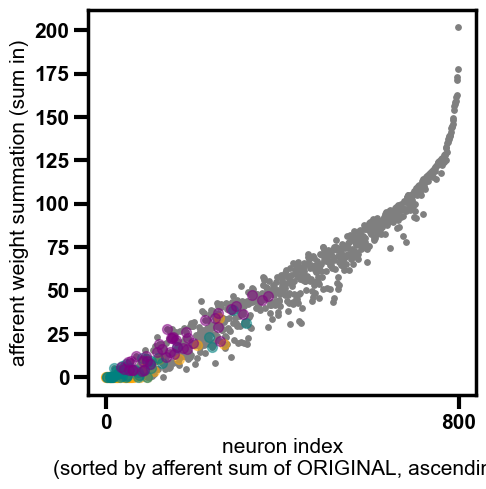

In [13]:
def _afferent_col_sums(datapath, time, matrix_size=800):
    base = '5,5ms interval, weight in ' + str(time) + 's'
    g    = np.load(os.path.join(datapath, base + '_data.npy'))
    post = np.load(os.path.join(datapath, base + '_col.npy')).astype(np.int64)
    col_sums = np.zeros(matrix_size)
    np.add.at(col_sums, post, g)   # post 별 합 = sum in
    return col_sums


def afferent_sum_plot_fixed_rank(datapath, save_path, time, rank,
                                 input_sets_path=None,
                                 matrix_size=800, show_groups=True):
    """
    rank        : x축 위치. 원본 sum-in ascending 으로 구한 값을 원본/tril 공통으로 넘긴다.
    datapath    : y축(sum-in)을 계산할 데이터 (원본이면 원본, tril이면 tril).
    input_sets_path : input_sets.npy 위치 (recovered 폴더엔 없으니 보통 원본 datapath).
    """
    col_sums = _afferent_col_sums(datapath, time, matrix_size)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(rank, col_sums, c='tab:gray', s=15.0)

    if show_groups:
        src = input_sets_path or datapath
        input_sets = np.load(os.path.join(src, '5,5ms interval, input_sets.npy'))
        for idx, c in zip(range(3), ['orange', 'teal', 'purple']):
            index = input_sets[idx][input_sets[idx] < matrix_size]
            ax.scatter(rank[index], col_sums[index], c=c, alpha=0.5, s=50.0)

    ax.set_xlabel('neuron index\n(sorted by afferent sum of ORIGINAL, ascending)', fontsize=15)
    ax.set_ylabel('afferent weight summation (sum in)', fontsize=15)
    ax.set_xticks([0, matrix_size])
    plt.savefig(save_path, format='png', transparent=True, bbox_inches='tight')
    plt.show()

col_sums_orig  = _afferent_col_sums('/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/record', 1200)
sorted_indices = np.argsort(col_sums_orig, kind='stable')
rank           = np.argsort(sorted_indices, kind='stable')

afferent_sum_plot_fixed_rank('/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/recovered_260806_data_5_5/data_5_5(4)/record', '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/recovered_260806_data_5_5/data_5_5(4)/neuron index Vs. sum in.png', 1200, rank,
                             input_sets_path='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/recovered_260806_data_5_5/data_5_5(4)/record')

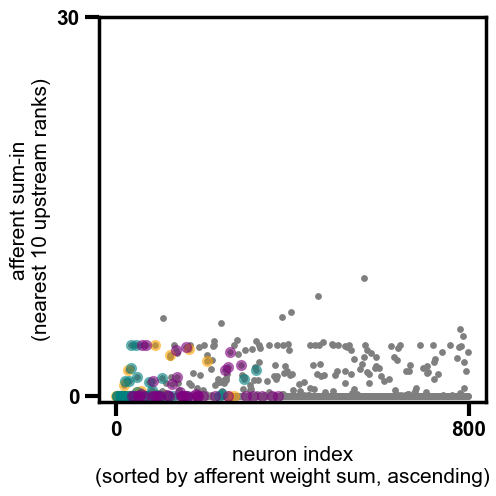

In [52]:
def afferent_sum_windowed_plot(datapath, save_path, time, n_window,
                               matrix_size=800, show_groups=True):
    base = '5,5ms interval, weight in ' + str(time) + 's'
    g    = np.load(os.path.join(datapath, base + '_data.npy'))
    pre  = np.load(os.path.join(datapath, base + '_row.npy')).astype(np.int64)
    post = np.load(os.path.join(datapath, base + '_col.npy')).astype(np.int64)

    # --- rank 는 '전체' afferent sum-in 으로 (x축을 이전 plot 과 동일하게 유지) ---
    col_sums = np.zeros(matrix_size)
    np.add.at(col_sums, post, g)
    sorted_indices = np.argsort(col_sums, kind='stable')
    rank = np.argsort(sorted_indices, kind='stable')     # rank[원래 뉴런]

    # --- 각 연결을 rank 좌표로 ---
    rank_pre  = rank[pre]
    rank_post = rank[post]

    # --- window: rank_post - n <= rank_pre <= rank_post (대각선 아래 n칸) ---
    keep = (rank_pre <= rank_post) & (rank_pre >= rank_post - n_window)

    windowed = np.zeros(matrix_size)
    np.add.at(windowed, post[keep], g[keep])             # post 뉴런별 국소 afferent 합

    x = np.arange(matrix_size)          # rank 위치
    y = windowed[sorted_indices]        # rank 순서대로 정렬된 windowed sum

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(x, y, c='tab:gray', s=15.0)

    if show_groups:
        input_sets = np.load(os.path.join(datapath, '5,5ms interval, input_sets.npy'))
        for idx, c in zip(range(3), ['orange', 'teal', 'purple']):
            index = input_sets[idx][input_sets[idx] < matrix_size]
            ax.scatter(rank[index], windowed[index], c=c, alpha=0.5, s=50.0)
            ax.set_yticks([0,30])

    ax.set_xlabel('neuron index\n(sorted by afferent weight sum, ascending)', fontsize=15)
    ax.set_ylabel('afferent sum-in\n(nearest %d upstream ranks)' % n_window, fontsize=15)
    ax.set_xticks([0, matrix_size])
    plt.savefig(save_path, format='png', transparent=True, bbox_inches='tight')
    plt.show()


afferent_sum_windowed_plot(datapath='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/record',
                             save_path='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/sumin_index_window10.png',
                             time = 1200, n_window=10, show_groups= True)

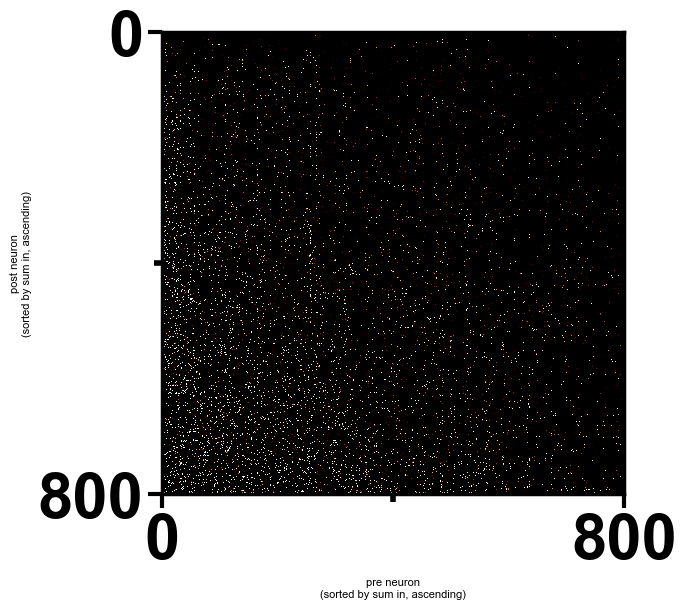

원본 연결 수: 64051, tril 후 남은 연결 수: 64051


(array([  0,   0,   0, ..., 799, 799, 799]),
 array([  1,  10,  35, ..., 787, 793, 795]),
 array([1.19926953e+00, 2.73658091e+00, 3.68321791e+00, ...,
        9.93458405e-02, 0.00000000e+00, 9.23882241e-26]),
 array([201, 446, 391, 795, 504, 553, 205, 265, 118, 469, 462, 708, 705,
        620, 591, 400,  11, 214, 773,  86, 723, 102, 624, 608, 574, 724,
        105, 178, 166,  12, 200, 741, 286, 567,  95, 368, 577, 353,  64,
        132, 267,  91, 451, 672, 721, 252, 294, 241, 491, 329, 520, 355,
        129, 770, 104, 564, 268, 682, 703, 100, 168, 684, 106, 728, 219,
        678, 213, 435, 243,  37, 366, 354, 666, 312, 618, 245, 191, 183,
        621, 601, 171, 217, 496, 554, 152, 786, 715, 317, 392,  60, 177,
        170, 785, 497, 699, 627, 301, 731, 509,   0, 463,   9, 271, 216,
        771, 537, 617, 501, 222, 116, 796, 772, 207, 275, 623, 169, 481,
        714, 430, 759, 156, 384,  32, 707,  81,  89, 385, 540,  53, 359,
        349, 339, 125, 333, 414, 206, 768, 460, 378, 610, 589

In [3]:
sum_in_ordered_tril_sparse(datapath='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/record', 
                           save_path = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/original_5_5(4).svg', time = 1200, tril_option = False,
                           recovered_save_dir='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/recovered_260806_data_5_5/data_5_5(4)/record')

In [ ]:
weight_sum_in_out_plot(datapath='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/recovered_260806_data_5_5/data_5_5(4)/record',
                       save_path = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/recovered_5_5(4)_weightsum_in_out.svg', time = 1200)

In [24]:
#raster 및 sdf를 그리기 위한 함수


def make_sdf(sT, t0, tmax, dt = 0.1, sigma = 0.5):
    kwdt= 3*sigma
    n= int((tmax-t0+2*kwdt)/dt)+1

    sdfs= np.zeros(n)
    
    
    kernel_len = int(2 * kwdt / dt) + 1  # +1 ensures odd length
    a = np.linspace(-kwdt, kwdt, kernel_len)
    x= np.exp(-np.power(a,2)/(2*sigma*sigma))
    x= x/(sigma*np.sqrt(2.0*np.pi))
    start_time = t0 - kwdt
    half = kernel_len // 2
    if sT is not None:
        for t in sT : 
            center = int(round((t - start_time) / dt))
            left= center-half
            right= left+kernel_len

            # 경계 자르기(커널/시그널을 함께 슬라이스)
            k_l = 0
            k_r = kernel_len
            if left < 0:
                k_l = -left
                left = 0
            if right > n:
                k_r = kernel_len - (right - n)
                right = n

            if k_l < k_r:                   # 유효 길이일 때만 더하기
                sdfs[left:right] += x[k_l:k_r]
            


    return sdfs[int(kwdt/dt):int((tmax-t0+kwdt)/dt)]

def raster_plot(datapath,inputset_path, save_path , time, exc_pop_size = 800):
    exc_spikes = pd.read_csv(os.path.join(datapath, '5_5_izhikevich_e_spikes.csv'), header = 0)
    time_range = [time-1, time+45]
    
    exc_start_idx = np.searchsorted(exc_spikes["Time [ms]"].values, time_range[0], side='left')
    exc_end_idx = np.searchsorted(exc_spikes["Time [ms]"].values, time_range[1], side='right')
    
    input_sets = np.load(os.path.join(inputset_path,  '5,5ms interval, input_sets.npy'))
    index0 = input_sets[0][input_sets[0] < exc_pop_size]
    index1 = input_sets[1][input_sets[1] < exc_pop_size]
    index2 = input_sets[2][input_sets[2] < exc_pop_size]
    
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.scatter(exc_spikes["Time [ms]"].values[exc_start_idx:exc_end_idx], exc_spikes[" Neuron ID"].values[exc_start_idx:exc_end_idx], s=5, edgecolors="none", color="gray")
    mask0 = np.isin(exc_spikes[" Neuron ID"].values[exc_start_idx:exc_end_idx],index0)
    mask1 = np.isin(exc_spikes[" Neuron ID"].values[exc_start_idx:exc_end_idx],index1)
    mask2 = np.isin(exc_spikes[" Neuron ID"].values[exc_start_idx:exc_end_idx],index2)
    ax.scatter(exc_spikes["Time [ms]"].values[exc_start_idx:exc_end_idx][mask0], exc_spikes[" Neuron ID"].values[exc_start_idx:exc_end_idx][mask0], s=10, edgecolors="none", color="orange", alpha = 0.5)
    ax.scatter(exc_spikes["Time [ms]"].values[exc_start_idx:exc_end_idx][mask1], exc_spikes[" Neuron ID"].values[exc_start_idx:exc_end_idx][mask1], s=10, edgecolors="none", color="teal", alpha = 0.5)
    ax.scatter(exc_spikes["Time [ms]"].values[exc_start_idx:exc_end_idx][mask2], exc_spikes[" Neuron ID"].values[exc_start_idx:exc_end_idx][mask2], s=10, edgecolors="none", color="purple", alpha = 0.5)

    ax.set_xlim([time-1,time+40])
    ax.set_ylim([0, exc_pop_size])
    #xticks = list(range(time, time_range[1], 10))
    #xticklabels = [int(x-time) for x in xticks]  
    ax.set_xticks([])
    #ax.set_xticklabels(xticklabels)
    ax.set_yticks(np.arange(0, exc_pop_size+1,200))
    
    plt.savefig(save_path, format='svg',  transparent=True)
    plt.show()

def sdf_plot(datapath , inputset_path, save_path , time, dt = 0.1,sigma = 0.5, exc_pop_size = 800, ymax = 80):
    time_range = [time-1, time+45]
    exc_spikes = pd.read_csv(os.path.join(datapath, '5_5_izhikevich_e_spikes.csv'), header = 0)
    stimulus_times = pd.read_csv(os.path.join(datapath, '5_5_izhikevich_stimulus_times.csv'), header = None)

    exc_start_idx = np.searchsorted(exc_spikes["Time [ms]"].values, time_range[0]-3*sigma, side='left')
    exc_end_idx = np.searchsorted(exc_spikes["Time [ms]"].values, time_range[1]+3*sigma, side='right')
    input_sets = np.load(os.path.join(inputset_path, '5,5ms interval, input_sets.npy'))
    

    index0 = input_sets[0][input_sets[0] < exc_pop_size]
    index1 = input_sets[1][input_sets[1] < exc_pop_size]
    index2 = input_sets[2][input_sets[2] < exc_pop_size]
    all_neurons = np.arange(exc_pop_size)  # 0 ~ 799까지의 뉴런 인덱스
    group_union = np.union1d(np.union1d(index0, index1), index2)
    index_rest = np.setdiff1d(all_neurons, group_union)
    
    mask0 = np.isin(exc_spikes[" Neuron ID"].values[exc_start_idx:exc_end_idx],index0)
    mask1 = np.isin(exc_spikes[" Neuron ID"].values[exc_start_idx:exc_end_idx],index1)
    mask2 = np.isin(exc_spikes[" Neuron ID"].values[exc_start_idx:exc_end_idx],index2)
    mask_rest = np.isin(exc_spikes[" Neuron ID"].values[exc_start_idx:exc_end_idx],index_rest)

    sdfs = make_sdf(exc_spikes["Time [ms]"].values[exc_start_idx:exc_end_idx],time_range[0], time_range[1], dt = dt, sigma = sigma)
    sdfs0 = make_sdf(exc_spikes["Time [ms]"].values[exc_start_idx:exc_end_idx][mask0],time_range[0], time_range[1], dt = dt, sigma = sigma)
    sdfs1 = make_sdf(exc_spikes["Time [ms]"].values[exc_start_idx:exc_end_idx][mask1],time_range[0], time_range[1], dt = dt, sigma = sigma)
    sdfs2 = make_sdf(exc_spikes["Time [ms]"].values[exc_start_idx:exc_end_idx][mask2],time_range[0], time_range[1], dt = dt, sigma = sigma)
    sdfs_rest = make_sdf(exc_spikes["Time [ms]"].values[exc_start_idx:exc_end_idx][mask_rest],time_range[0], time_range[1], dt = dt, sigma = sigma)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(np.arange(time_range[0], time_range[1]+dt, dt)[:len(sdfs_rest)], sdfs_rest, linewidth = 4, c = 'gray')
    ax.plot(np.arange(time_range[0], time_range[1]+dt, dt)[:len(sdfs)], sdfs, linewidth = 4, c = 'k')
    ax.plot(np.arange(time_range[0], time_range[1]+dt, dt)[:len(sdfs2)],sdfs2, linewidth = 4, c = 'purple')
    ax.plot(np.arange(time_range[0], time_range[1]+dt, dt)[:len(sdfs1)], sdfs1, linewidth = 4, c = 'teal')
    ax.plot(np.arange(time_range[0], time_range[1]+dt, dt)[:len(sdfs0)], sdfs0, linewidth = 4, c = 'orange')
    
    ax.set_xlim([time-1, time+40])
    ax.set_yticks(np.arange(0,ymax+1, 40))
    ax.set_ylim([-5, ymax])
    xticks = list(range(time, time+41, 10))
    xticklabels = [int(x-time) for x in xticks]   
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)


    plt.savefig(save_path, format='svg', transparent=True)
    plt.show()

def group_only_sdf_plot(datapath,  save_path ,  stim0time, stim1time, stim2time,stim012time, dt = 0.1,sigma = 0.5, ymax = 80):
    exc_spikes = pd.read_csv(os.path.join(datapath, '5_5_izhikevich_e_spikes.csv'), header = 0)
    stimulus_times = pd.read_csv(os.path.join(datapath, '5_5_izhikevich_stimulus_times.csv'), header = None)
    ######012에 대해서 
    time_range012 = [stim012time-1,stim012time+45]
    exc_start_idx = np.searchsorted(exc_spikes["Time [ms]"].values, time_range012[0]-3*sigma, side='left')
    exc_end_idx = np.searchsorted(exc_spikes["Time [ms]"].values, time_range012[1]+3*sigma, side='right')
    sdfs012 = make_sdf(exc_spikes["Time [ms]"].values[exc_start_idx:exc_end_idx],time_range012[0], time_range012[1], dt = dt, sigma = sigma)
    ######0에 대해서
    time_range0 = [stim0time-1,stim0time+45]
    exc_start_idx = np.searchsorted(exc_spikes["Time [ms]"].values, time_range0[0]-3*sigma, side='left')
    exc_end_idx = np.searchsorted(exc_spikes["Time [ms]"].values, time_range0[1]+3*sigma, side='right')
    sdfs0 = make_sdf(exc_spikes["Time [ms]"].values[exc_start_idx:exc_end_idx],time_range0[0], time_range0[1], dt = dt, sigma = sigma)
    ######1에 대해서
    time_range1 = [stim1time-1,stim1time+45]
    exc_start_idx = np.searchsorted(exc_spikes["Time [ms]"].values, time_range1[0]-3*sigma, side='left')
    exc_end_idx = np.searchsorted(exc_spikes["Time [ms]"].values, time_range1[1]+3*sigma, side='right')
    sdfs1 = make_sdf(exc_spikes["Time [ms]"].values[exc_start_idx:exc_end_idx],time_range1[0], time_range1[1], dt = dt, sigma = sigma)
    ######2에 대해서
    time_range2 = [stim2time-1,stim2time+45]
    exc_start_idx = np.searchsorted(exc_spikes["Time [ms]"].values, time_range2[0]-3*sigma, side='left')
    exc_end_idx = np.searchsorted(exc_spikes["Time [ms]"].values, time_range2[1]+3*sigma, side='right')
    sdfs2 = make_sdf(exc_spikes["Time [ms]"].values[exc_start_idx:exc_end_idx],time_range2[0], time_range2[1], dt = dt, sigma = sigma)
    
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(np.arange(-1, 45, dt), sdfs012, linewidth = 4, c = 'k')
    ax.plot(np.arange(-1, 45, dt), sdfs2, linewidth = 4, c = 'mediumvioletred')
    ax.plot(np.arange(-1, 45, dt), sdfs1, linewidth = 4, c = 'deepskyblue')
    ax.plot(np.arange(-1, 45, dt), sdfs0, linewidth = 4, c = 'orangered')
    ax.set_xlim([-1,40])
    ax.set_yticks(np.arange(0,ymax+1, 40))
    ax.set_ylim([-5, ymax])
    xticks = list(range(0,41, 10))
    xticklabels = xticks
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
    plt.savefig(save_path, format='svg', transparent=True)
    plt.show()

In [53]:
#group 3과 5에 대해서 response를 보기 위함 
def group_3_5_only_sdf_plot(datapath,  save_path ,  stim3time, stim5time, dt = 0.1,sigma = 0.5):
    exc_spikes = pd.read_csv(os.path.join(datapath, '5_5_izhikevich_e_spikes.csv'), header = 0)
    stimulus_times = pd.read_csv(os.path.join(datapath, '5_5_izhikevich_stimulus_times.csv'), header = None)

    ######3에 대해서
    time_range3 = [stim3time-1,stim3time+45]
    exc_start_idx = np.searchsorted(exc_spikes["Time [ms]"].values, time_range3[0]-3*sigma, side='left')
    exc_end_idx = np.searchsorted(exc_spikes["Time [ms]"].values, time_range3[1]+3*sigma, side='right')
    sdfs3 = make_sdf(exc_spikes["Time [ms]"].values[exc_start_idx:exc_end_idx],time_range3[0], time_range3[1], dt = dt, sigma = sigma)
    
    ######5에 대해서
    time_range5 = [stim5time-1,stim5time+45]
    exc_start_idx = np.searchsorted(exc_spikes["Time [ms]"].values, time_range5[0]-3*sigma, side='left')
    exc_end_idx = np.searchsorted(exc_spikes["Time [ms]"].values, time_range5[1]+3*sigma, side='right')
    sdfs5 = make_sdf(exc_spikes["Time [ms]"].values[exc_start_idx:exc_end_idx],time_range5[0], time_range5[1], dt = dt, sigma = sigma)

    
    fig, ax = plt.subplots(figsize=(8, 4))

    ax.plot(np.arange(-1, 45, dt), sdfs3, linewidth = 4, c = 'pink')
    ax.plot(np.arange(-1, 45, dt), sdfs5, linewidth = 4, c = 'brown')

    ax.set_xlim([-1,40])
    ax.set_yticks([0,40,80,120,160])
    ax.set_ylim([-5, 160])
    xticks = list(range(0,41, 10))
    xticklabels = xticks
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
    plt.savefig(save_path, format='svg', transparent=True)
    plt.show()

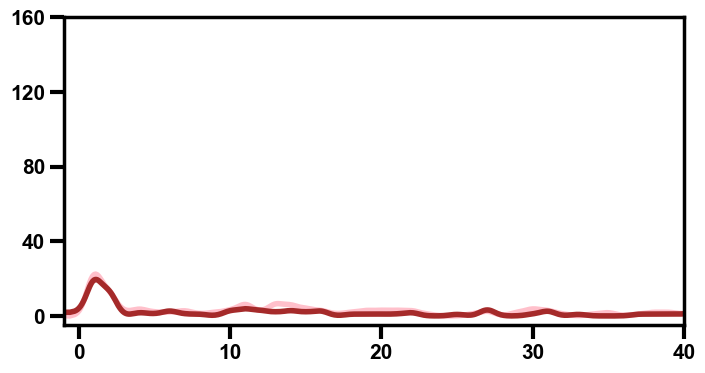

In [54]:
#
group_3_5_only_sdf_plot(datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(5)/csv',
            save_path = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(5)/sdf_group3_group5.svg', 
            stim3time = 10489235, stim5time= 10343914)

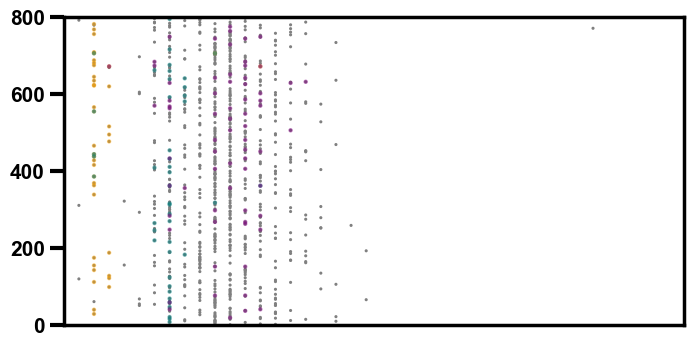

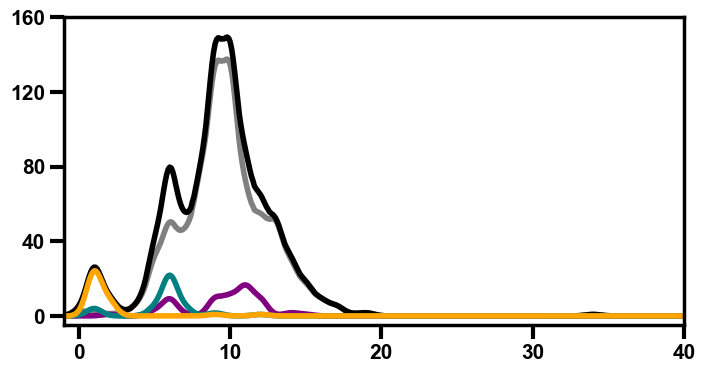

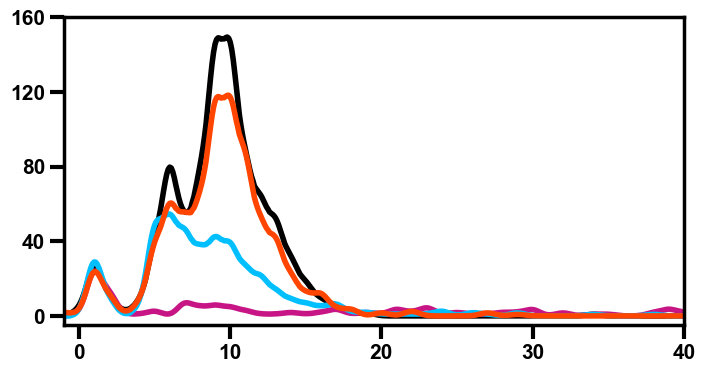

In [ ]:
#delay 1
raster_plot(datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_delay1(1)/csv',
            inputset_path= '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_delay1(1)/record',
            save_path = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_delay1(1)/raster_10660370.svg', time = 10660370)
sdf_plot(datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_delay1(1)/csv',
            inputset_path= '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_delay1(1)/record',
            save_path = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_delay1(1)/sdf_10660370.svg', time = 10660370)
group_only_sdf_plot(datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_delay1(1)/csv',
            save_path = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_delay1(1)/group_only_sdf.svg',stim012time = 10660370,
                    stim0time = 10783483, stim1time= 10752823, stim2time= 10668627)

In [ ]:


spike_bump_frames_plot(spikepath='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_size_scale_factor2(1)/csv',
                                     weightpath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_size_scale_factor2(1)/record',
                                      save_path= '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_size_scale_factor2(1)/raster_10738891.svg',
                                       weight_time = 10740, bump_intervals = [(10738892,10738894), (10738898,10738905), (10738908,10738915)],  t_start=10738891, t_end=10738917, bin_ms= 1, matrix_size= 1600)

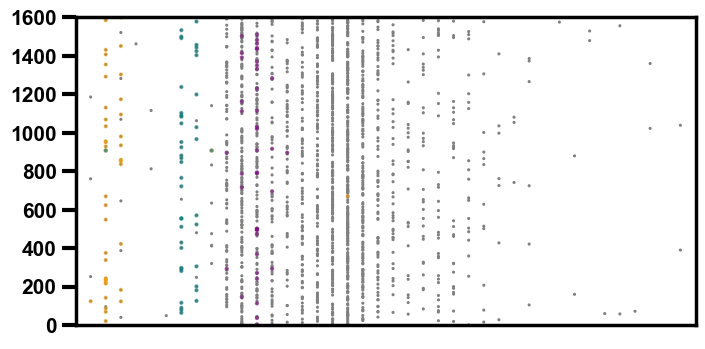

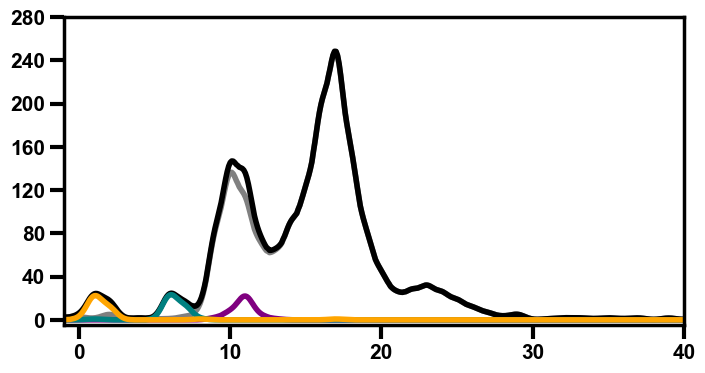

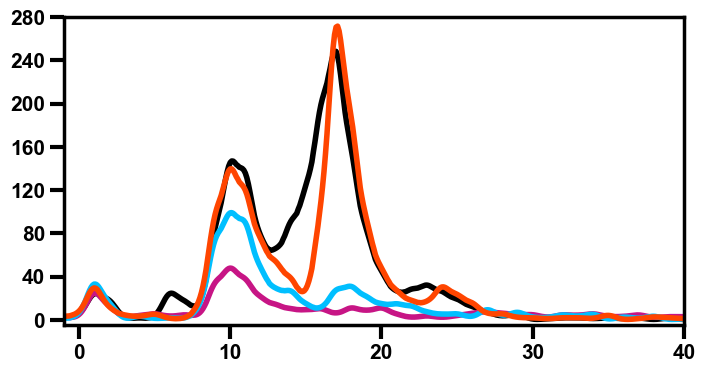

In [26]:
#size scale factor 2, no weight scale 
raster_plot(datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_size_scale_factor2_no_weight_scale(1)/csv',
            inputset_path= '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_size_scale_factor2_no_weight_scale(1)/record',
            save_path = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_size_scale_factor2_no_weight_scale(1)/raster_10535688.svg', 
            time =10535688, exc_pop_size= 1600)
sdf_plot(datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_size_scale_factor2_no_weight_scale(1)/csv',
           inputset_path= '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_size_scale_factor2_no_weight_scale(1)/record', 
            save_path = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_size_scale_factor2_no_weight_scale(1)/sdf_10535688.svg'
            ,time = 10535688, exc_pop_size= 1600, ymax = 280)
group_only_sdf_plot(datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_size_scale_factor2_no_weight_scale(1)/csv',
            save_path = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_size_scale_factor2_no_weight_scale(1)/group_only_sdf.svg',
                    stim0time = 10658976, stim1time= 10726424, stim2time= 10480457, stim012time= 10535688, ymax = 280)

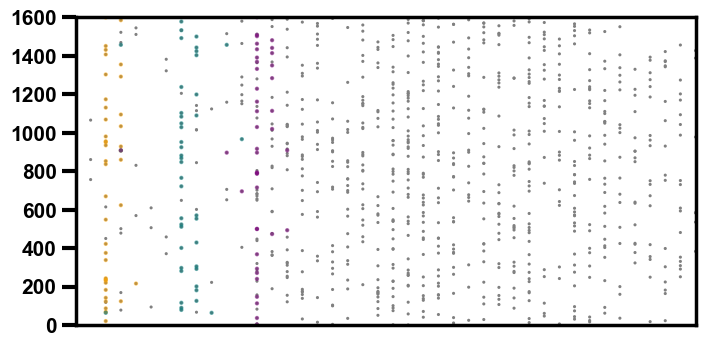

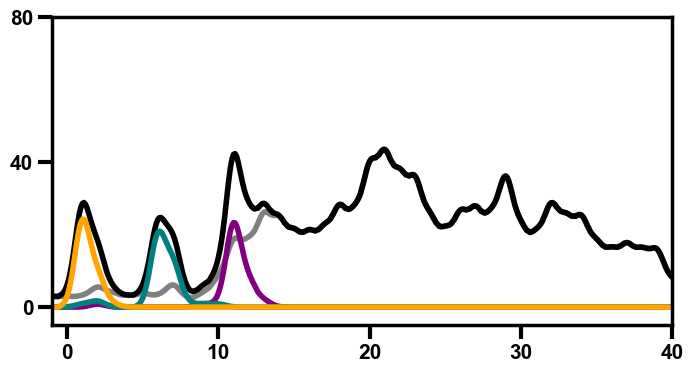

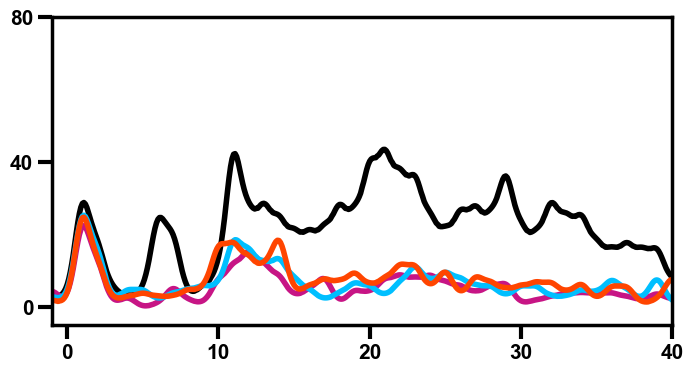

In [27]:
#size scale factor 2
raster_plot(datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_size_scale_factor2(1)/csv',
            inputset_path= '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_size_scale_factor2(1)/record',
            save_path = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_size_scale_factor2(1)/raster_10507069.svg', 
            time =10507069, exc_pop_size= 1600)
sdf_plot(datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_size_scale_factor2(1)/csv',
           inputset_path= '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_size_scale_factor2(1)/record', 
            save_path = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_size_scale_factor2(1)/sdf_10507069.svg'
            ,time = 10507069, exc_pop_size= 1600, ymax = 80)
group_only_sdf_plot(datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_size_scale_factor2(1)/csv',
            save_path = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_size_scale_factor2(1)/group_only_sdf.svg',
                    stim0time = 10738891, stim1time= 10373810, stim2time= 10375844, stim012time= 10507069, ymax = 80)

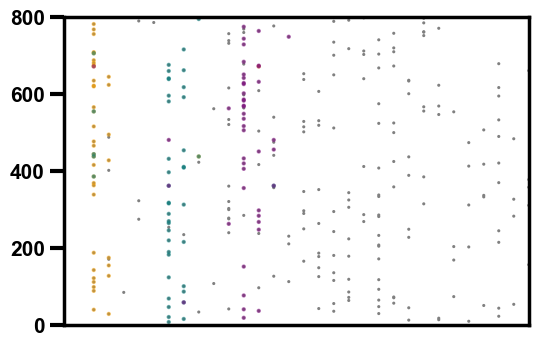

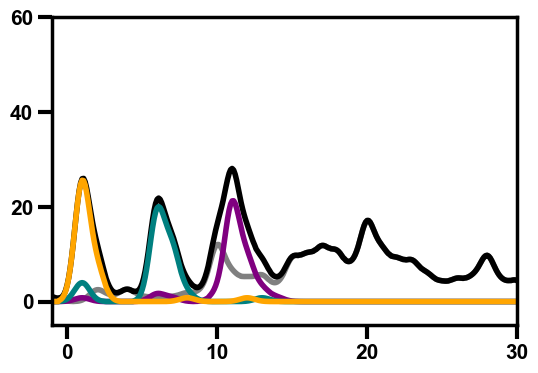

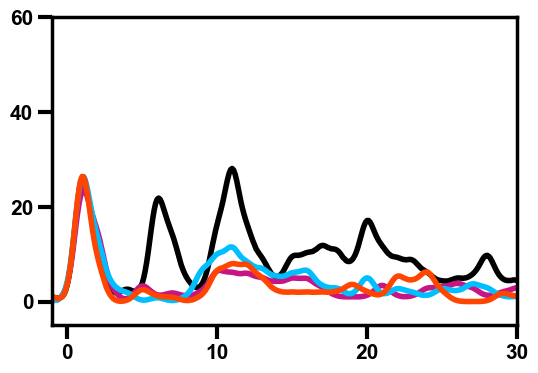

In [18]:
#sparsity 0.05
raster_plot(datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_sparsity0.05(1)/csv',
            inputset_path= '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_sparsity0.05(1)/record',
            save_path = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_sparsity0.05(1)/raster_10098901.svg', time = 10098901)
sdf_plot(datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_sparsity0.05(1)/csv',
           inputset_path= '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_sparsity0.05(1)/record', 
            save_path = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_sparsity0.05(1)/sdf_10098901.svg',time = 10098901)
group_only_sdf_plot(datapath='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_sparsity0.05(1)/csv',
                    save_path='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5_sparsity0.05(1)/group_only_sdf_10098901.svg',
                    stim0time = 10035354, stim1time= 9957357, stim2time= 10094823, stim012time= 10098901)

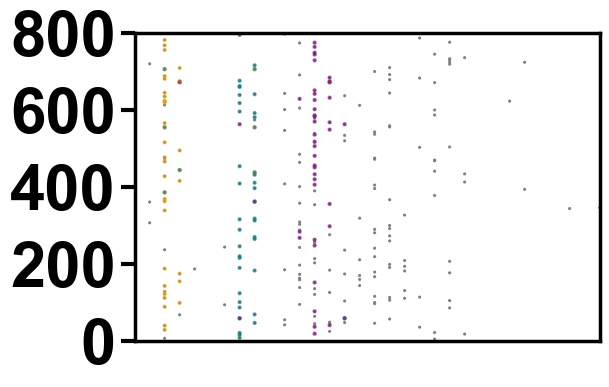

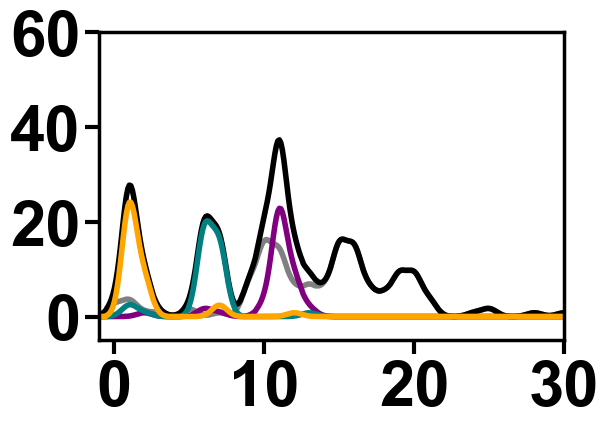

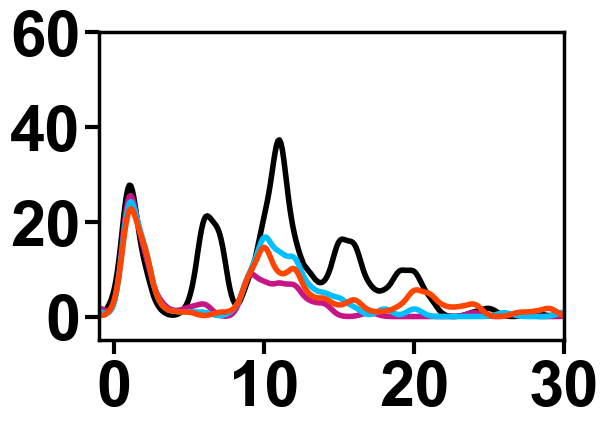

In [55]:
#inh -20 for 검증
#original
raster_plot(datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)_inh_-20/',
            inputset_path= '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)_inh_-20',
            save_path = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)_inh_-20/raster_900062.svg', time = 900062)
sdf_plot(datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)_inh_-20',
           inputset_path= '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)_inh_-20', 
            save_path = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)_inh_-20/sdf_900062.svg',time = 900062)
group_only_sdf_plot(datapath='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)_inh_-20',
                    save_path='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)_inh_-20/group_only_sdf_900062.svg',
                    stim0time = 1500080, stim1time= 1700082, stim2time= 1900096, stim012time= 900062)

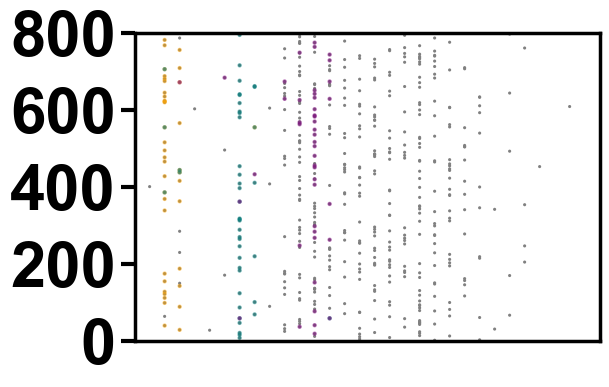

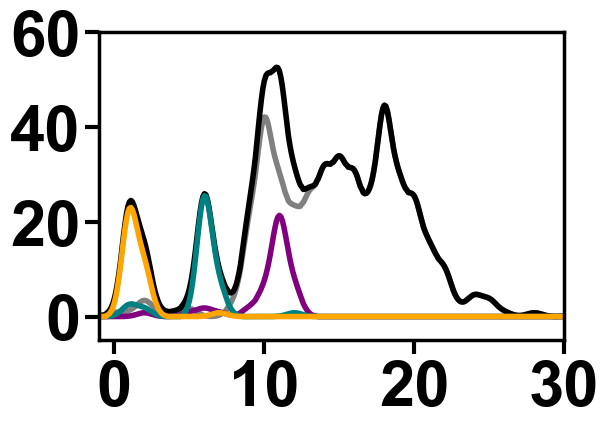

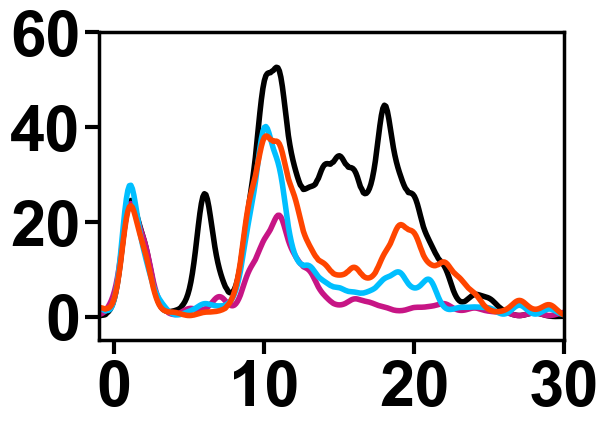

In [53]:
#no inh synapse
#original
raster_plot(datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)_no inh synapse/',
            inputset_path= '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)_no inh synapse',
            save_path = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)_no inh synapse/raster_500019.svg', time = 500019)
sdf_plot(datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)_no inh synapse',
           inputset_path= '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)_no inh synapse', 
            save_path = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)_no inh synapse/sdf_500019.svg',time = 500019)
group_only_sdf_plot(datapath='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)_no inh synapse',
                    save_path='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)_no inh synapse/group_only_sdf_500019.svg',
                    stim0time = 3500156, stim1time= 1700072, stim2time= 1900076, stim012time= 500019)

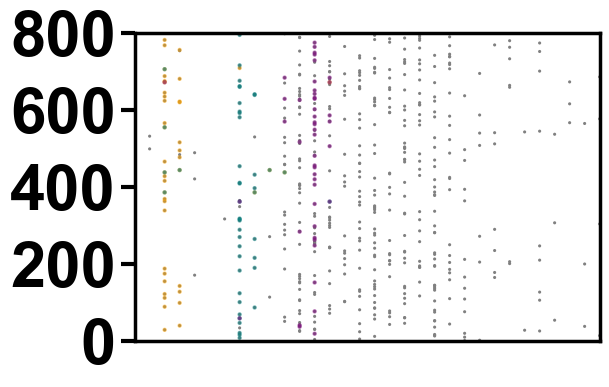

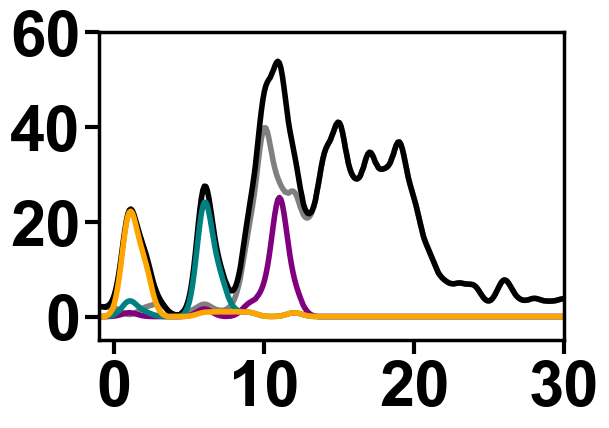

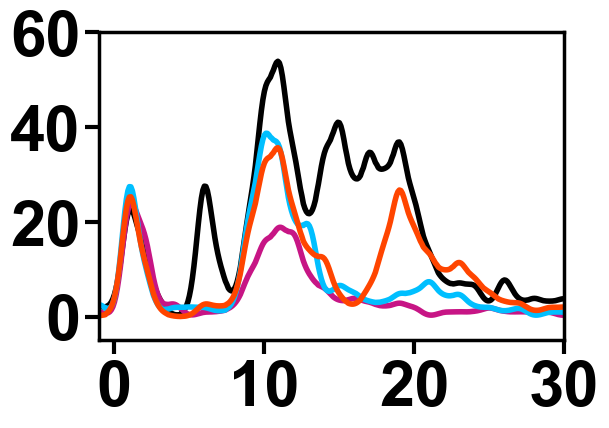

In [22]:
#original
raster_plot(datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/csv',
            inputset_path= '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/record',
            save_path = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/raster.svg', time = 8531715)
sdf_plot(datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/csv',
           inputset_path= '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/record', 
            save_path = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/sdf.svg',time = 8531715)
group_only_sdf_plot(datapath='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/csv',
                    save_path='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/group_only_sdf.svg',
                    stim0time = 8540515 , stim1time= 8545027, stim2time= 8533771, stim012time= 8531715)

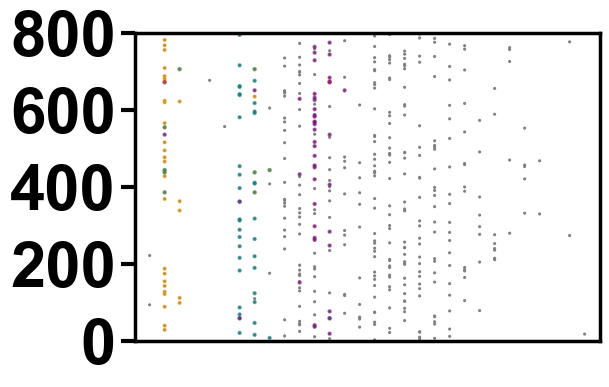

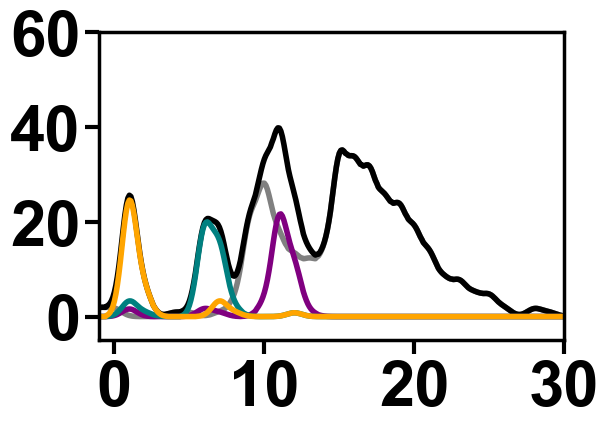

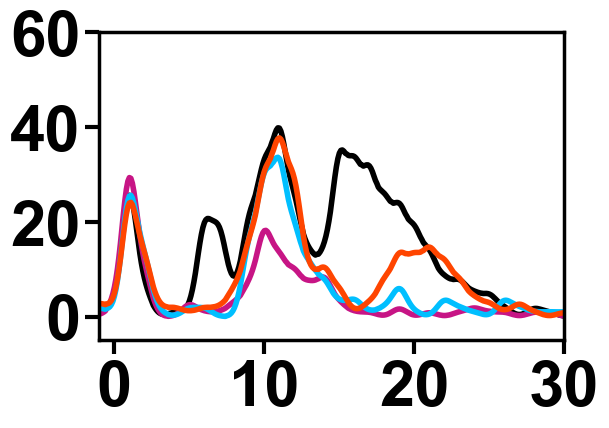

In [10]:
#recovered
raster_plot(datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)',
            inputset_path= '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)',
            save_path = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)/raster_3800144.svg', time = 3800144)
sdf_plot(datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)',
           inputset_path= '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)', 
            save_path = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)/sdf_3800144.svg',time = 3800144)
group_only_sdf_plot(datapath='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)',
                    save_path='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)/group_only_sdf_3800144.svg',
                    stim0time = 4000149 , stim1time= 4900184, stim2time= 5200193, stim012time=3800144 )

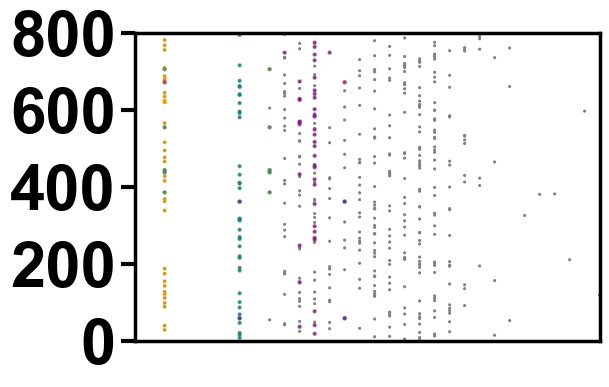

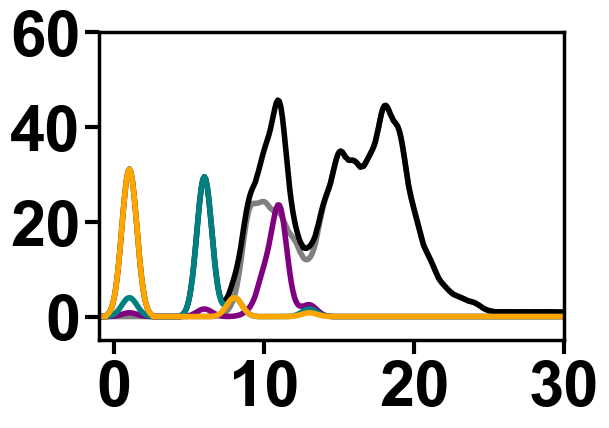

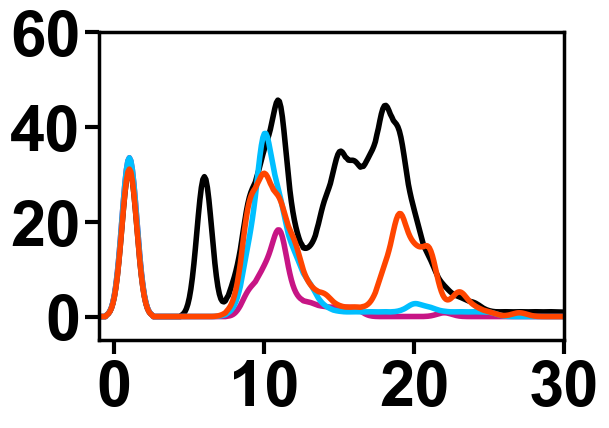

In [12]:
#recovered
raster_plot(datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)_no_noise',
            inputset_path= '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)_no_noise',
            save_path = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)_no_noise/raster_4100176.svg', time = 4100176)
sdf_plot(datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)_no_noise',
           inputset_path= '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)_no_noise', 
            save_path = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)_no_noise/sdf_4100176.svg',time = 4100176)
group_only_sdf_plot(datapath='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)_no_noise',
                    save_path='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)_no_noise/group_only_sdf_4100176.svg',
                    stim0time = 4400195 , stim1time= 4900213, stim2time= 3800161, stim012time=4100176 )

In [36]:
def raster_plot(datapath,inputset_path, save_path , time):
    exc_spikes = pd.read_csv(os.path.join(datapath, '5_5_izhikevich_e_spikes.csv'), header = 0)
    inh_spikes = pd.read_csv(os.path.join(datapath, '5_5_izhikevich_i_spikes.csv'), header = 0)
    time_range = [time-1, time+35]
    
    exc_start_idx = np.searchsorted(exc_spikes["Time [ms]"].values, time_range[0], side='left')
    exc_end_idx = np.searchsorted(exc_spikes["Time [ms]"].values, time_range[1], side='right')
    inh_start_idx = np.searchsorted(inh_spikes["Time [ms]"].values, time_range[0], side='left')
    inh_end_idx = np.searchsorted(inh_spikes["Time [ms]"].values, time_range[1], side='right')    
    
    input_sets = np.load(os.path.join(inputset_path,  '5,5ms interval, input_sets.npy'))
    index0 = input_sets[0][input_sets[0] < 800]
    index1 = input_sets[1][input_sets[1] < 800]
    index2 = input_sets[2][input_sets[2] < 800]
    
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(exc_spikes["Time [ms]"].values[exc_start_idx:exc_end_idx], exc_spikes[" Neuron ID"].values[exc_start_idx:exc_end_idx], s=5, edgecolors="none", color="gray")
    ax.scatter(inh_spikes["Time [ms]"].values[inh_start_idx:inh_end_idx], inh_spikes[" Neuron ID"].values[inh_start_idx:inh_end_idx]+800, s = 5, edgecolors = "none", color = 'blue' )
    mask0 = np.isin(exc_spikes[" Neuron ID"].values[exc_start_idx:exc_end_idx],index0)
    mask1 = np.isin(exc_spikes[" Neuron ID"].values[exc_start_idx:exc_end_idx],index1)
    mask2 = np.isin(exc_spikes[" Neuron ID"].values[exc_start_idx:exc_end_idx],index2)
    ax.scatter(exc_spikes["Time [ms]"].values[exc_start_idx:exc_end_idx][mask0], exc_spikes[" Neuron ID"].values[exc_start_idx:exc_end_idx][mask0], s=10, edgecolors="none", color="orange", alpha = 0.5)
    ax.scatter(exc_spikes["Time [ms]"].values[exc_start_idx:exc_end_idx][mask1], exc_spikes[" Neuron ID"].values[exc_start_idx:exc_end_idx][mask1], s=10, edgecolors="none", color="teal", alpha = 0.5)
    ax.scatter(exc_spikes["Time [ms]"].values[exc_start_idx:exc_end_idx][mask2], exc_spikes[" Neuron ID"].values[exc_start_idx:exc_end_idx][mask2], s=10, edgecolors="none", color="purple", alpha = 0.5)
    
    ax.set_xlim([time-1,time+30])
    ax.set_ylim([0, 1000])
    #xticks = list(range(time, time_range[1], 10))
    #xticklabels = [int(x-time) for x in xticks]  
    ax.set_xticks([])
    #ax.set_xticklabels(xticklabels)
    ax.set_yticks([0,200,400,600, 800,1000])
    
    plt.savefig(save_path, format='svg',  transparent=True)
    plt.show()

In [ ]:
stim0time = 145639 , stim1time= 134379, stim2time= 165902, stim012time=136221

In [ ]:
raster_plot(datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)',
            inputset_path= '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)',
            save_path = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)/raster_only0.svg', time = 145639)
raster_plot(datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)',
            inputset_path= '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)',
            save_path = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)/raster_only1.svg', time = 134379)
raster_plot(datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)',
            inputset_path= '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)',
            save_path = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)/raster_only2.svg', time = 165902)
raster_plot(datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)',
            inputset_path= '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)',
            save_path = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)/raster_012.svg', time = 136221)


In [61]:
#graph 그리기. publication quality
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

STIM_COLS = ["time", "g1", "g2", "g3", "iti_12", "iti_23"]

def load_stimulus_times(datapath):
    return pd.read_csv(
        os.path.join(datapath, "5_5_izhikevich_stimulus_times.csv"),
        header=None, names=STIM_COLS,
    )

def find_times(df, pattern):
    """pattern = (g1, g2, g3, iti_12, iti_23); None -> 그 칸이 NaN(비어있음)."""
    keys = ["g1", "g2", "g3", "iti_12", "iti_23"]
    mask = pd.Series(True, index=df.index)
    for k, v in zip(keys, pattern):
        mask &= df[k].isna() if v is None else (df[k] == v)
    return df.loc[mask, "time"].to_numpy()

def compute_sdf(spike_times, stimtime, dt=0.1, sigma=0.5, pre=1, post=35):
    t0, t1 = stimtime - pre, stimtime + post
    lo = np.searchsorted(spike_times, t0 - 3 * sigma, side="left")
    hi = np.searchsorted(spike_times, t1 + 3 * sigma, side="right")
    return make_sdf(spike_times[lo:hi], t0, t1, dt=dt, sigma=sigma)

def plot_group_only(sdf_dict, save_path, dt=0.1, pre=1, post=35):
    x = np.arange(-pre, post, dt)
    style = {"012": "k", "2": "mediumvioletred",
             "1": "deepskyblue", "0": "orangered"}
    fig, ax = plt.subplots(figsize=(6, 4))
    for key in ["012", "2", "1", "0"]:          # 원본과 동일한 그리기 순서
        if sdf_dict.get(key) is not None:
            y = sdf_dict[key]
            ax.plot(x[:len(y)], y, linewidth=4, c=style[key])
    ax.set_xlim([-1, 30]); ax.set_ylim([-5, 60])
    ax.set_yticks([0, 20, 40, 60]); ax.set_xticks(range(0, 31, 10))
    plt.savefig(save_path, format="svg", transparent=True)
    plt.close(fig)

def group_only_sdf_auto(datapath, save_path, dt=0.1, sigma=0.5,
                        pre=1, post=35, n_average=None, seed=None):
    """
    n_average: 각 패턴에서 무작위로 몇 개의 occurrence를 뽑아 평균낼지.
               None이면 발견된 전부를 평균.
    seed: 무작위 추출 재현용 (None이면 매번 다르게).
    """
    exc = pd.read_csv(os.path.join(datapath, "5_5_izhikevich_e_spikes.csv"), header=0)
    spikes = np.sort(exc["Time [ms]"].to_numpy())
    df = load_stimulus_times(datapath)

    patterns = {
        "0":   (0, None, None, None, None),
        "1":   (1, None, None, None, None),
        "2":   (2, None, None, None, None),
        "012": (0, 1, 2, 5, 5),
    }

    rng = np.random.default_rng(seed)
    sdf_dict = {}
    for k, p in patterns.items():
        ts = find_times(df, p)
        if n_average is not None and n_average < len(ts):
            ts = rng.choice(ts, n_average, replace=False)
        print(f"pattern {k}: {len(ts)}개 평균 -> {ts}")
        if len(ts) == 0:
            sdf_dict[k] = None
            continue
        stacked = np.stack([compute_sdf(spikes, t, dt, sigma, pre, post) for t in ts])
        sdf_dict[k] = stacked.mean(axis=0)

    plot_group_only(sdf_dict, save_path, dt, pre, post)

def compute_group_sdfs(datapath, dt=0.1, sigma=0.5, pre=1, post=35,
                       n_average=None, seed=None):
    """플롯 없이 각 패턴의 평균 SDF dict만 반환."""
    exc = pd.read_csv(os.path.join(datapath, "5_5_izhikevich_e_spikes.csv"), header=0)
    spikes = np.sort(exc["Time [ms]"].to_numpy())
    df = load_stimulus_times(datapath)

    patterns = {
        "0":   (0, None, None, None, None),
        "1":   (1, None, None, None, None),
        "2":   (2, None, None, None, None),
        "012": (0, 1, 2, 5, 5),
    }

    rng = np.random.default_rng(seed)
    sdf_dict = {}
    for k, p in patterns.items():
        ts = find_times(df, p)
        if n_average is not None and n_average < len(ts):
            ts = rng.choice(ts, n_average, replace=False)
        print(f"[{os.path.basename(datapath)}] pattern {k}: {len(ts)}개 -> {ts}")
        if len(ts) == 0:
            sdf_dict[k] = None
            continue
        stacked = np.stack([compute_sdf(spikes, t, dt, sigma, pre, post) for t in ts])
        sdf_dict[k] = stacked.mean(axis=0)
    return sdf_dict

def plot_sdf_profiles_and_differences(
        datapath_a, datapath_b, save_dir,
        dt=0.1, sigma=0.5, pre=1, post=35,
        n_average=None, seed=None, label_a="A", label_b="B"):
    """
    두 데이터셋 각각의 group-only SDF profile 2장 + 패턴별 차이(A-B) 4장 = 총 6장 저장.
    profile과 차이는 동일한 무작위 선택 결과를 공유.
    """
    os.makedirs(save_dir, exist_ok=True)

    # 각 데이터셋에서 무작위 n_average개를 뽑아 평균 (이 결과를 이후 전부 재사용)
    sdf_a = compute_group_sdfs(datapath_a, dt, sigma, pre, post, n_average, seed)
    sdf_b = compute_group_sdfs(datapath_b, dt, sigma, pre, post, n_average, seed)

    # 1) 각 데이터셋의 profile 1장씩
    plot_group_only(sdf_a, os.path.join(save_dir, f"profile_{label_a}.svg"), dt, pre, post)
    plot_group_only(sdf_b, os.path.join(save_dir, f"profile_{label_b}.svg"), dt, pre, post)
    print(f"저장: profile_{label_a}.svg, profile_{label_b}.svg")

    # 2) 패턴별 차이 4장
    x = np.arange(-pre, post, dt)
    style = {"012": "k", "2": "mediumvioletred",
             "1": "deepskyblue", "0": "orangered"}

    for key in ["0", "1", "2", "012"]:
        ya, yb = sdf_a.get(key), sdf_b.get(key)
        if ya is None or yb is None:
            print(f"pattern {key}: 한쪽 데이터가 없어 건너뜀")
            continue
        n = min(len(ya), len(yb))
        diff = ya[:n] - yb[:n]

        fig, ax = plt.subplots(figsize=(6, 4))
        ax.axhline(0, color="gray", lw=1, ls="--")
        ax.plot(x[:n], diff, linewidth=4, c=style[key])
        ax.set_xlim([-1, 30])
        ax.set_title(f"pattern {key}: {label_a} - {label_b}")
        save_path = os.path.join(save_dir, f"sdf_diff_{key}.svg")
        plt.savefig(save_path, format="svg", transparent=True)
        plt.close(fig)
        print(f"저장: {save_path}")

In [ ]:
plot_sdf_profiles_and_differences(datapath_a='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)_original1200', datapath_b='/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)',
                                  save_dir='response_test_5_5_time1200(4)andresponse_test_5_5_time1200(4)_original1200_figure',n_average = 10, seed = 1234)

[response_test_5_5_time1200(4)_original1200] pattern 0: 10개 -> [3300141. 8500363. 3500145. 2500104. 8300350. 1100051. 8400359. 7800320.
 3400142. 7000275.]
[response_test_5_5_time1200(4)_original1200] pattern 1: 10개 -> [1700072. 5700224. 1400062. 3800156.  700027. 2800123.  600020. 6100228.
 7700311. 7400301.]
[response_test_5_5_time1200(4)_original1200] pattern 2: 10개 -> [1000046. 1300054.  100007. 5100207. 7500302. 2600111. 6400246. 4200184.
 3700152. 5000207.]
[response_test_5_5_time1200(4)_original1200] pattern 012: 10개 -> [3600148. 4900207.  900041.  400014. 7600306. 5300210. 1900084. 3000131.
 2400102. 8600364.]
[response_test_5_5_time1200(4)] pattern 0: 10개 -> [2700105. 5500206. 3900148. 2000081. 4800177. 1500054. 5400199. 4600169.
 3600134. 4400164.]
[response_test_5_5_time1200(4)] pattern 1: 10개 -> [1200051. 5100192. 2100083. 5900228. 1100045. 2900108.  700029. 3000109.
 5700218. 4900184.]
[response_test_5_5_time1200(4)] pattern 2: 10개 -> [3500127. 5200193.  200011. 4100154. 5

In [64]:
"""
group_sdf_analysis.py

두 데이터셋의 group-only SDF profile과 패턴별 차이(A-B)를 publication quality로 생성.

사용 예:
    from group_sdf_analysis import (
        group_only_sdf_auto,
        plot_sdf_profiles_and_differences,
    )

    base = ".../260806_PRE_analysis"

    # 단일 데이터셋 profile 1장
    group_only_sdf_auto(
        datapath=f"{base}/response_test_5_5_time1200(4)_original1200",
        save_path=f"{base}/response_test_5_5_time1200(4)_original1200/averaged_group_only_sdf.svg",
        n_average=10, seed=1234,
    )

    # 두 데이터셋 profile 2장 + 패턴별 차이 4장 = 총 6장
    plot_sdf_profiles_and_differences(
        datapath_a=f"{base}/response_test_5_5_time1200(4)_original1200",
        datapath_b=f"{base}/response_test_5_5_time1200(4)",
        save_dir=f"{base}/sdf_output",
        n_average=10, seed=1234,
        label_a="original1200", label_b="(4)",
    )

주의: make_sdf(spike_times, t_start, t_stop, dt, sigma) 는 기존에 쓰던 구현을
      그대로 아래 자리에 넣어주세요.
"""

import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------------
# make_sdf : 기존 구현을 여기에 넣으세요.
# ---------------------------------------------------------------------------

def make_sdf(sT, t0, tmax, dt = 0.1, sigma = 0.5):
    kwdt= 3*sigma
    n= int((tmax-t0+2*kwdt)/dt)+1

    sdfs= np.zeros(n)
    
    
    kernel_len = int(2 * kwdt / dt) + 1  # +1 ensures odd length
    a = np.linspace(-kwdt, kwdt, kernel_len)
    x= np.exp(-np.power(a,2)/(2*sigma*sigma))
    x= x/(sigma*np.sqrt(2.0*np.pi))
    start_time = t0 - kwdt
    half = kernel_len // 2
    if sT is not None:
        for t in sT : 
            center = int(round((t - start_time) / dt))
            left= center-half
            right= left+kernel_len

            # 경계 자르기(커널/시그널을 함께 슬라이스)
            k_l = 0
            k_r = kernel_len
            if left < 0:
                k_l = -left
                left = 0
            if right > n:
                k_r = kernel_len - (right - n)
                right = n

            if k_l < k_r:                   # 유효 길이일 때만 더하기
                sdfs[left:right] += x[k_l:k_r]
            


    return sdfs[int(kwdt/dt):int((tmax-t0+kwdt)/dt)]

# ---------------------------------------------------------------------------
# CSV 로딩 / 패턴 매칭
# ---------------------------------------------------------------------------
# 5_5_izhikevich_stimulus_times.csv 컬럼 구조
#   0: time      첫 자극 시각
#   1: g1        1st stimuli group
#   2: g2        2nd stimuli group
#   3: g3        3rd stimuli group
#   4: iti_12    1st-2nd 자극 간격
#   5: iti_23    2nd-3rd 자극 간격
STIM_COLS = ["time", "g1", "g2", "g3", "iti_12", "iti_23"]

# 찾을 자극 패턴. None -> 그 칸이 비어있음(NaN)이어야 함.
PATTERNS = {
    "0":   (0, None, None, None, None),
    "1":   (1, None, None, None, None),
    "2":   (2, None, None, None, None),
    "012": (0, 1, 2, 5, 5),
}

# 곡선 색상 / 그리기 순서
STYLE = {"012": "k", "2": "mediumvioletred", "1": "deepskyblue", "0": "orangered"}
DRAW_ORDER = ["012", "2", "1", "0"]


def load_stimulus_times(datapath):
    return pd.read_csv(
        os.path.join(datapath, "5_5_izhikevich_stimulus_times.csv"),
        header=None, names=STIM_COLS,
    )


def find_times(df, pattern):
    """pattern = (g1, g2, g3, iti_12, iti_23); None -> 그 칸이 NaN(비어있음)."""
    keys = ["g1", "g2", "g3", "iti_12", "iti_23"]
    mask = pd.Series(True, index=df.index)
    for k, v in zip(keys, pattern):
        mask &= df[k].isna() if v is None else (df[k] == v)
    return df.loc[mask, "time"].to_numpy()


# ---------------------------------------------------------------------------
# SDF 계산
# ---------------------------------------------------------------------------
def compute_sdf(spike_times, stimtime, dt=0.1, sigma=0.5, pre=1, post=35):
    t0, t1 = stimtime - pre, stimtime + post
    lo = np.searchsorted(spike_times, t0 - 3 * sigma, side="left")
    hi = np.searchsorted(spike_times, t1 + 3 * sigma, side="right")
    return make_sdf(spike_times[lo:hi], t0, t1, dt=dt, sigma=sigma)


def compute_group_sdfs(datapath, dt=0.1, sigma=0.5, pre=1, post=35,
                       n_average=None, seed=None):
    """플롯 없이 각 패턴의 평균 SDF dict만 반환.

    n_average: 각 패턴에서 무작위로 몇 개의 occurrence를 뽑아 평균낼지.
               None이면 발견된 전부를 평균.
    seed:      무작위 추출 재현용 (None이면 매번 다르게).
    """
    exc = pd.read_csv(
        os.path.join(datapath, "5_5_izhikevich_e_spikes.csv"), header=0
    )
    spikes = np.sort(exc["Time [ms]"].to_numpy())   # searchsorted 위해 정렬 보장
    df = load_stimulus_times(datapath)

    rng = np.random.default_rng(seed)
    sdf_dict = {}
    for k, p in PATTERNS.items():
        ts = find_times(df, p)
        if n_average is not None and n_average < len(ts):
            ts = rng.choice(ts, n_average, replace=False)
        print(f"[{os.path.basename(datapath)}] pattern {k}: {len(ts)}개 평균 -> {ts}")
        if len(ts) == 0:
            sdf_dict[k] = None
            continue
        stacked = np.stack([compute_sdf(spikes, t, dt, sigma, pre, post) for t in ts])
        sdf_dict[k] = stacked.mean(axis=0)
    return sdf_dict


# ---------------------------------------------------------------------------
# Publication 스타일
# ---------------------------------------------------------------------------
def set_publication_style(tick_fs=32, use_arial=True):
    """figure.svg와 동일한 계열의 publication 스타일 적용."""
    if use_arial:
        mpl.rcParams["font.family"] = "sans-serif"
        mpl.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
    mpl.rcParams.update({
        "svg.fonttype": "none",        # 텍스트를 편집가능한 <text>로 저장
        "font.weight": "bold",
        "axes.linewidth": 2.5,         # spine 두께
        "xtick.major.width": 3,
        "ytick.major.width": 3,
        "xtick.major.size": 6,
        "ytick.major.size": 6,
        "xtick.labelsize": tick_fs,
        "ytick.labelsize": tick_fs,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "axes.spines.top": True,       # 4면 box (figure.svg와 동일)
        "axes.spines.right": True,
    })


def _style_axes(ax):
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight("bold")


# ---------------------------------------------------------------------------
# 플로팅
# ---------------------------------------------------------------------------
def plot_group_only(sdf_dict, save_path, dt=0.1, pre=1, post=35):
    x = np.arange(-pre, post, dt)
    fig, ax = plt.subplots(figsize=(6, 4))
    for key in DRAW_ORDER:
        if sdf_dict.get(key) is not None:
            y = sdf_dict[key]
            ax.plot(x[:len(y)], y, linewidth=4, c=STYLE[key], solid_capstyle="round")
    ax.set_xlim([-1, 30]); ax.set_ylim([-5, 60])
    ax.set_yticks([0, 20, 40, 60]); ax.set_xticks(range(0, 31, 10))
    _style_axes(ax)
    fig.tight_layout()
    fig.savefig(save_path, format="svg", transparent=True)
    plt.close(fig)


def _plot_diff(x, diff, color, save_path, title=None, ylim=None):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.axhline(0, color="gray", lw=1.5, ls="--")
    ax.plot(x, diff, linewidth=4, c=color, solid_capstyle="round")
    ax.set_xlim([-1, 30]); ax.set_xticks(range(0, 31, 10))
    if ylim is not None:
        ax.set_ylim(ylim)
    if title:
        ax.set_title(title, fontweight="bold")
    _style_axes(ax)
    fig.tight_layout()
    fig.savefig(save_path, format="svg", transparent=True)
    plt.close(fig)


# ---------------------------------------------------------------------------
# 공개 API
# ---------------------------------------------------------------------------
def group_only_sdf_auto(datapath, save_path, dt=0.1, sigma=0.5,
                        pre=1, post=35, n_average=None, seed=None, tick_fs=32):
    """단일 데이터셋에서 group-only SDF profile 1장 생성."""
    set_publication_style(tick_fs=tick_fs)
    sdf_dict = compute_group_sdfs(datapath, dt, sigma, pre, post, n_average, seed)
    plot_group_only(sdf_dict, save_path, dt, pre, post)
    print(f"저장: {save_path}")


def plot_sdf_profiles_and_differences(
        datapath_a, datapath_b, save_dir,
        dt=0.1, sigma=0.5, pre=1, post=35,
        n_average=None, seed=None, label_a="A", label_b="B",
        tick_fs=32, diff_ylim=None):
    """
    두 데이터셋 각각의 group-only SDF profile 2장 + 패턴별 차이(A-B) 4장 = 총 6장 저장.
    profile과 차이는 동일한 무작위 선택 결과를 공유한다.

    diff_ylim: 차이 그래프 y축 고정범위 (예: (-20, 20)). None이면 자동.
    """
    set_publication_style(tick_fs=tick_fs)
    os.makedirs(save_dir, exist_ok=True)

    # 무작위 n_average개를 뽑아 평균 (이 결과를 profile/차이 양쪽에 재사용)
    sdf_a = compute_group_sdfs(datapath_a, dt, sigma, pre, post, n_average, seed)
    sdf_b = compute_group_sdfs(datapath_b, dt, sigma, pre, post, n_average, seed)

    # 1) 각 데이터셋 profile 1장씩
    p_a = os.path.join(save_dir, f"profile_{label_a}.svg")
    p_b = os.path.join(save_dir, f"profile_{label_b}.svg")
    plot_group_only(sdf_a, p_a, dt, pre, post)
    plot_group_only(sdf_b, p_b, dt, pre, post)
    print(f"저장: {p_a}\n저장: {p_b}")

    # 2) 패턴별 차이 4장
    x = np.arange(-pre, post, dt)
    for key in ["0", "1", "2", "012"]:
        ya, yb = sdf_a.get(key), sdf_b.get(key)
        if ya is None or yb is None:
            print(f"pattern {key}: 한쪽 데이터 없음, 건너뜀")
            continue
        n = min(len(ya), len(yb))
        save_path = os.path.join(save_dir, f"sdf_diff_{key}.svg")
        _plot_diff(x[:n], ya[:n] - yb[:n], STYLE[key], save_path,
                   title=f"{key}: {label_a} - {label_b}", ylim=diff_ylim)
        print(f"저장: {save_path}")


if __name__ == "__main__":
    base = ("/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/"
            "Triplet_Raster/260806_PRE_analysis")

    plot_sdf_profiles_and_differences(
        datapath_a=f"{base}/response_test_5_5_time1200(4)_original1200",
        datapath_b=f"{base}/response_test_5_5_time1200(4)",
        save_dir=f"{base}/sdf_output",
        n_average=10, seed=1234,
        label_a="original1200", label_b="(4)",
    )

[response_test_5_5_time1200(4)_original1200] pattern 0: 10개 평균 -> [3300141. 8500363. 3500145. 2500104. 8300350. 1100051. 8400359. 7800320.
 3400142. 7000275.]
[response_test_5_5_time1200(4)_original1200] pattern 1: 10개 평균 -> [1700072. 5700224. 1400062. 3800156.  700027. 2800123.  600020. 6100228.
 7700311. 7400301.]
[response_test_5_5_time1200(4)_original1200] pattern 2: 10개 평균 -> [1000046. 1300054.  100007. 5100207. 7500302. 2600111. 6400246. 4200184.
 3700152. 5000207.]
[response_test_5_5_time1200(4)_original1200] pattern 012: 10개 평균 -> [3600148. 4900207.  900041.  400014. 7600306. 5300210. 1900084. 3000131.
 2400102. 8600364.]
[response_test_5_5_time1200(4)] pattern 0: 10개 평균 -> [2700105. 5500206. 3900148. 2000081. 4800177. 1500054. 5400199. 4600169.
 3600134. 4400164.]
[response_test_5_5_time1200(4)] pattern 1: 10개 평균 -> [1200051. 5100192. 2100083. 5900228. 1100045. 2900108.  700029. 3000109.
 5700218. 4900184.]
[response_test_5_5_time1200(4)] pattern 2: 10개 평균 -> [3500127. 5200193

In [ ]:
#
group_only_sdf_auto(datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)_original1200',
                     save_path= "/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/response_test_5_5_time1200(4)_original1200/averaged_group_only_sdf.svg",
                    n_average=10, seed=1234)

pattern 0: 10개 평균 -> [1400074. 5300234. 2000101. 2500116. 4700204. 1200059. 4800213. 1000042.
 1600083. 3900182.]
pattern 1: 7개 평균 -> [ 100007.  300018.  700034. 1800096. 2400107. 4500198. 5400235.]
pattern 2: 10개 평균 -> [1100051. 4300195. 2300103. 5500238.  900038. 3000146.  200012. 3300158.
 5000217. 4100191.]
pattern 012: 10개 평균 -> [ 500026. 5800247.  400020. 3600175. 5900255. 2600118. 5600241. 2200102.
 1300068. 4600204.]


In [ ]:
#non normality 분석, inhibitory weights를 포함하여 전체 matrix에서 분석하자. 
datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/record'
time = 1200


ee_g = np.load(os.path.join(datapath, '5,5ms interval, weight in ' + str(time) + 's_data.npy'))
ee_pre = np.load(os.path.join(datapath, '5,5ms interval, weight in ' + str(time) + 's_row.npy'))
ee_post = np.load(os.path.join(datapath, '5,5ms interval, weight in ' + str(time) + 's_col.npy'))
ei_g = np.load(os.path.join(datapath, '5,5ms interval, EI weight in ' + str(time) + 's_data.npy'))
ei_pre = np.load(os.path.join(datapath, '5,5ms interval, EI weight in ' + str(time) + 's_row.npy'))
ei_post = np.load(os.path.join(datapath, '5,5ms interval, EI weight in ' + str(time) + 's_col.npy'))
ie_post = np.load(os.path.join(datapath, '5,5ms interval, IE_col.npy'))
ie_pre = np.load(os.path.join(datapath, '5,5ms interval, IE_row.npy'))
ii_post = np.load(os.path.join(datapath, '5,5ms interval, II_col.npy'))
ii_pre = np.load(os.path.join(datapath, '5,5ms interval, II_row.npy'))

In [40]:
"""
Henrici's departure from normality 로 weight matrix 의 non-normality 를 평가.

두 대상:
  (1) EE network 만 (800x800, 흥분성)
  (2) 전체 network E+I (1000x1000, 흥분 + 억제)

정의:
  dep_F(A) = sqrt( ||A||_F^2 - sum_i |lambda_i|^2 )
  - normal 이면 0, non-normal 일수록 커짐
  - transpose 에 불변 (pre->post / post->reo 방향 무관)
  - 상대값 dep_F(A)/||A||_F 도 함께 리포트 (크기 무관 비교용)

주의: 억제성(II, IE)은 저장 파일에 구조만 있고 g 는 없음(static 상수).
      전체 행렬에서는 inh_weight(기본 -1.0)를 부호까지 넣어 채운다.
"""

import os
import numpy as np


def henrici_departure(A):
    """Frobenius Henrici departure from normality."""
    A = np.asarray(A, dtype=np.float64)
    fro2 = np.sum(A * A)                       # ||A||_F^2
    eig = np.linalg.eigvals(A)                 # 비대칭 실수행렬 -> 복소 고유값
    sum_lam2 = np.sum(np.abs(eig) ** 2)        # sum |lambda_i|^2
    dep = np.sqrt(max(fro2 - sum_lam2, 0.0))   # 수치오차 음수 방지
    fro = np.sqrt(fro2)
    return {
        "departure": dep,
        "fro_norm": fro,
        "relative": dep / fro if fro > 0 else 0.0,   # dep / ||A||_F
        "n_eig": len(eig),
        "spectral_radius": np.max(np.abs(eig)),
    }


def load_all(datapath, time):
    def L(tag):
        return np.load(os.path.join(datapath, f'5,5ms interval, {tag}.npy'))
    ee_g   = L(f'weight in {time}s_data')
    ee_pre = L(f'weight in {time}s_row').astype(np.int64)
    ee_post= L(f'weight in {time}s_col').astype(np.int64)
    ei_g   = L(f'EI weight in {time}s_data')
    ei_pre = L(f'EI weight in {time}s_row').astype(np.int64)
    ei_post= L(f'EI weight in {time}s_col').astype(np.int64)
    ie_pre = L('IE_row').astype(np.int64)
    ie_post= L('IE_col').astype(np.int64)
    ii_pre = L('II_row').astype(np.int64)
    ii_post= L('II_col').astype(np.int64)
    return dict(ee_g=ee_g, ee_pre=ee_pre, ee_post=ee_post,
                ei_g=ei_g, ei_pre=ei_pre, ei_post=ei_post,
                ie_pre=ie_pre, ie_post=ie_post,
                ii_pre=ii_pre, ii_post=ii_post)


def build_ee_matrix(d, n_exc=800):
    """EE 만: row=pre, col=post, 흥분성 g."""
    M = np.zeros((n_exc, n_exc))
    M[d['ee_pre'], d['ee_post']] = d['ee_g']
    return M


def build_full_matrix(d, n_exc=800, n_inh=200, inh_weight=-1.0):
    """전체 E+I: 0..n_exc-1 = E, n_exc..n_exc+n_inh-1 = I. row=pre, col=post.
       흥분(EE,EI)은 +g, 억제(IE,II)는 inh_weight(부호 포함)."""
    N = n_exc + n_inh
    M = np.zeros((N, N))
    # EE: E->E
    M[d['ee_pre'], d['ee_post']] = d['ee_g']
    # EI: E->I  (post 는 I 블록으로 shift)
    M[d['ei_pre'], d['ei_post'] + n_exc] = d['ei_g']
    # IE: I->E  (pre 는 I 블록으로 shift)
    M[d['ie_pre'] + n_exc, d['ie_post']] = inh_weight
    # II: I->I  (둘 다 I 블록)
    M[d['ii_pre'] + n_exc, d['ii_post'] + n_exc] = inh_weight
    return M



In [43]:

if __name__ == "__main__":
    datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/record'
    time = 1200
    INH_WEIGHT = -1.0   # frozen 모델의 inh_weight 와 반드시 일치시킬 것

    d = load_all(datapath, time)

    # 인덱스 범위 확인
    assert d['ee_pre'].max() < 800 and d['ee_post'].max() < 800
    assert d['ei_pre'].max() < 800 and d['ei_post'].max() < 200
    assert d['ie_pre'].max() < 200 and d['ie_post'].max() < 800
    assert d['ii_pre'].max() < 200 and d['ii_post'].max() < 200

    # (1) EE only
    M_ee = build_ee_matrix(d)
    r_ee = henrici_departure(M_ee)
    print("=== EE network (800x800) ===")
    print(f"  connections     : {len(d['ee_g'])}")
    print(f"  ||A||_F         : {r_ee['fro_norm']:.4f}")
    print(f"  spectral radius : {r_ee['spectral_radius']:.4f}")
    print(f"  departure       : {r_ee['departure']:.4f}")
    print(f"  relative (dep/F): {r_ee['relative']:.4f}")

    # (2) full E+I
    M_full = build_full_matrix(d, inh_weight=INH_WEIGHT)
    r_full = henrici_departure(M_full)
    print("\n=== Full network E+I (1000x1000) ===")
    print(f"  EE/EI/IE/II conns: {len(d['ee_g'])}/{len(d['ei_g'])}/{len(d['ie_pre'])}/{len(d['ii_pre'])}")
    print(f"  inh_weight       : {INH_WEIGHT}")
    print(f"  ||A||_F          : {r_full['fro_norm']:.4f}")
    print(f"  spectral radius  : {r_full['spectral_radius']:.4f}")
    print(f"  departure        : {r_full['departure']:.4f}")
    print(f"  relative (dep/F) : {r_full['relative']:.4f}")

=== EE network (800x800) ===
  connections     : 64051
  ||A||_F         : 421.8290
  spectral radius : 49.9393
  departure       : 356.5166
  relative (dep/F): 0.8452

=== Full network E+I (1000x1000) ===
  EE/EI/IE/II conns: 64051/15899/16004/3971
  inh_weight       : -1.0
  ||A||_F          : 490.8685
  spectral radius  : 22.5162
  departure        : 410.4264
  relative (dep/F) : 0.8361


In [51]:
#Random matrix. weights를 그대로 가져와 순서만 섞는다.
def random_ee_departure_valpreserve(M_ee, n_rep=200, exclude_diagonal=False, seed=0):
    N = M_ee.shape[0]
    vals = M_ee[M_ee != 0.0].copy()          # 실제 EE weight 값들 그대로
    k = len(vals)
    cand = (np.flatnonzero(~np.eye(N, dtype=bool).ravel())
            if exclude_diagonal else np.arange(N * N))
    rng = np.random.default_rng(seed)
    deps = np.empty(n_rep); specs = np.empty(n_rep); fros = np.empty(n_rep)
    for r in range(n_rep):
        R = np.zeros((N, N))
        chosen = rng.choice(cand, size=k, replace=False)
        R.flat[chosen] = vals[rng.permutation(k)]
        res = henrici_departure(R)
        deps[r] = res['departure']; specs[r] = res['spectral_radius']; fros[r] = res['fro_norm']
    return {'departure': deps, 'spectral_radius': specs, 'fro_norm': fros, 'k': k, 'N': N}

def randomize_full_departure(M_full, N_E=800, N_I=200,
                             blocks=('EE', 'EI', 'IE', 'II'),
                             inh_value=-1.0, n_rep=200, seed=0):
    """
    각 블록(EE/EI/IE/II)을 '블록 내부에서만' 무작위화한 null.
      - EE/EI(흥분성) : 원본 weight 값 multiset 을 그대로 재배치 (부호·크기 보존)
      - IE/II(억제성) : 값이 inh_value 상수 -> 개수만 맞춰 위치 무작위
    blocks 에 지정한 블록만 셔플, 나머지는 원본 유지.
    """
    N = N_E + N_I
    assert M_full.shape == (N, N)
    block_def = {           # (row_slice, col_slice, 대각블록여부, 상수억제여부)
        'EE': (slice(0, N_E),   slice(0, N_E),   True,  False),
        'EI': (slice(0, N_E),   slice(N_E, N),   False, False),
        'IE': (slice(N_E, N),   slice(0, N_E),   False, True),
        'II': (slice(N_E, N),   slice(N_E, N),   True,  True),
    }
    rng = np.random.default_rng(seed)

    base = M_full.copy()
    prepared = []
    for name in blocks:
        rs, cs, is_diag, is_inh = block_def[name]
        sub = M_full[rs, cs]
        nr, nc = sub.shape
        cand = (np.flatnonzero(~np.eye(nr, dtype=bool).ravel())
                if is_diag else np.arange(nr * nc))
        k = int(np.count_nonzero(sub))
        vals = None if is_inh else sub[sub != 0.0].copy()
        prepared.append((rs, cs, cand, nr, nc, k, is_inh, vals))
        base[rs, cs] = 0.0

    deps = np.empty(n_rep); specs = np.empty(n_rep); fros = np.empty(n_rep)
    for r in range(n_rep):
        R = base.copy()
        for (rs, cs, cand, nr, nc, k, is_inh, vals) in prepared:
            chosen = rng.choice(cand, size=k, replace=False)
            flat = np.zeros(nr * nc)
            if is_inh:
                flat[chosen] = inh_value
            else:
                flat[chosen] = vals[rng.permutation(k)]
            R[rs, cs] = flat.reshape(nr, nc)
        res = henrici_departure(R)
        deps[r] = res['departure']; specs[r] = res['spectral_radius']; fros[r] = res['fro_norm']
    return {'departure': deps, 'spectral_radius': specs, 'fro_norm': fros, 'blocks': blocks}

if __name__ == "__main__":
    datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/record'
    time = 1200
    INH_WEIGHT = -1.0
    N_REP = 100
    SEED = 0

    d = load_all(datapath, time)

    assert d['ee_pre'].max() < 800 and d['ee_post'].max() < 800
    assert d['ei_pre'].max() < 800 and d['ei_post'].max() < 200
    assert d['ie_pre'].max() < 200 and d['ie_post'].max() < 800
    assert d['ii_pre'].max() < 200 and d['ii_post'].max() < 200

    def report(name, r_actual, rnd):
        dep_a = r_actual['departure']
        mu, sd = rnd['departure'].mean(), rnd['departure'].std()
        z = (dep_a - mu) / sd if sd > 0 else np.nan
        print(f"=== {name} ===")
        print(f"  ||A||_F         : actual {r_actual['fro_norm']:.4f}   "
              f"null {rnd['fro_norm'].mean():.4f}   (일치해야 정상)")
        print(f"  spectral radius : actual {r_actual['spectral_radius']:.4f}   "
              f"null {rnd['spectral_radius'].mean():.4f} ± {rnd['spectral_radius'].std():.4f}")
        print(f"  departure       : actual {dep_a:.4f}   "
              f"null {mu:.4f} ± {sd:.4f}")
        print(f"  z-score         : {z:.2f}")
        print()

    # ---------- (1) EE only (800x800) ----------
    M_ee = build_ee_matrix(d)
    r_ee = henrici_departure(M_ee)
    rnd_ee = random_ee_departure_valpreserve(M_ee, n_rep=N_REP, seed=SEED)
    print(f"[EE] connections: {len(d['ee_g'])}, nonzeros(k)={rnd_ee['k']}\n")
    report("EE network (800x800)", r_ee, rnd_ee)

    # ---------- (2) full E+I (1000x1000) ----------
    M_full = build_full_matrix(d, inh_weight=INH_WEIGHT)
    r_full = henrici_departure(M_full)
    rnd_full = randomize_full_departure(M_full, N_E=800, N_I=200,
                                        blocks=('EE', 'EI', 'IE', 'II'),
                                        inh_value=INH_WEIGHT,
                                        n_rep=N_REP, seed=SEED)
    print(f"[full] EE/EI/IE/II conns: "
          f"{len(d['ee_g'])}/{len(d['ei_g'])}/{len(d['ie_pre'])}/{len(d['ii_pre'])}, "
          f"inh_weight={INH_WEIGHT}\n")
    report("Full network E+I (1000x1000)", r_full, rnd_full)

[EE] connections: 64051, nonzeros(k)=51022

=== EE network (800x800) ===
  ||A||_F         : actual 421.8290   null 421.8290   (일치해야 정상)
  spectral radius : actual 49.9393   null 67.6471 ± 0.1175
  departure       : actual 356.5166   null 297.5379 ± 0.3777
  z-score         : 156.16

[full] EE/EI/IE/II conns: 64051/15899/16004/3971, inh_weight=-1.0

=== Full network E+I (1000x1000) ===
  ||A||_F         : actual 490.8685   null 490.8685   (일치해야 정상)
  spectral radius : actual 22.5162   null 48.8278 ± 0.2884
  departure       : actual 410.4264   null 358.2826 ± 0.2882
  z-score         : 180.94



In [44]:
if __name__ == "__main__":
    datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/recovered_260806_data_5_5/data_5_5(4)/record'
    time = 1200
    INH_WEIGHT = -1.0   # frozen 모델의 inh_weight 와 반드시 일치시킬 것

    d = load_all(datapath, time)

    # 인덱스 범위 확인
    assert d['ee_pre'].max() < 800 and d['ee_post'].max() < 800
    assert d['ei_pre'].max() < 800 and d['ei_post'].max() < 200
    assert d['ie_pre'].max() < 200 and d['ie_post'].max() < 800
    assert d['ii_pre'].max() < 200 and d['ii_post'].max() < 200

    # (1) EE only
    M_ee = build_ee_matrix(d)
    r_ee = henrici_departure(M_ee)
    print("=== EE network (800x800) ===")
    print(f"  connections     : {len(d['ee_g'])}")
    print(f"  ||A||_F         : {r_ee['fro_norm']:.4f}")
    print(f"  spectral radius : {r_ee['spectral_radius']:.4f}")
    print(f"  departure       : {r_ee['departure']:.4f}")
    print(f"  relative (dep/F): {r_ee['relative']:.4f}")

    # (2) full E+I
    M_full = build_full_matrix(d, inh_weight=INH_WEIGHT)
    r_full = henrici_departure(M_full)
    print("\n=== Full network E+I (1000x1000) ===")
    print(f"  EE/EI/IE/II conns: {len(d['ee_g'])}/{len(d['ei_g'])}/{len(d['ie_pre'])}/{len(d['ii_pre'])}")
    print(f"  inh_weight       : {INH_WEIGHT}")
    print(f"  ||A||_F          : {r_full['fro_norm']:.4f}")
    print(f"  spectral radius  : {r_full['spectral_radius']:.4f}")
    print(f"  departure        : {r_full['departure']:.4f}")
    print(f"  relative (dep/F) : {r_full['relative']:.4f}")

=== EE network (800x800) ===
  connections     : 32590
  ||A||_F         : 385.6872
  spectral radius : 0.0000
  departure       : 385.6872
  relative (dep/F): 1.0000

=== Full network E+I (1000x1000) ===
  EE/EI/IE/II conns: 32590/15899/16004/3971
  inh_weight       : -1.0
  ||A||_F          : 460.1812
  spectral radius  : 34.2306
  departure        : 413.4276
  relative (dep/F) : 0.8984


In [41]:
#random matrix에 대해서 henri's departure from normality 구하기- 요지는 학습된 weight matrix와 비교하는 것이다. 
#initialize 경우 

if __name__ == "__main__":
    datapath = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/260806_PRE_analysis/260806_data_5_5/data_5_5(4)/record'
    time = 0
    INH_WEIGHT = -1.0   # frozen 모델의 inh_weight 와 반드시 일치시킬 것

    d = load_all(datapath, time)

    # 인덱스 범위 확인
    assert d['ee_pre'].max() < 800 and d['ee_post'].max() < 800
    assert d['ei_pre'].max() < 800 and d['ei_post'].max() < 200
    assert d['ie_pre'].max() < 200 and d['ie_post'].max() < 800
    assert d['ii_pre'].max() < 200 and d['ii_post'].max() < 200

    # (1) EE only
    M_ee = build_ee_matrix(d)
    r_ee = henrici_departure(M_ee)
    print("=== EE network (800x800) ===")
    print(f"  connections     : {len(d['ee_g'])}")
    print(f"  ||A||_F         : {r_ee['fro_norm']:.4f}")
    print(f"  spectral radius : {r_ee['spectral_radius']:.4f}")
    print(f"  departure       : {r_ee['departure']:.4f}")
    print(f"  relative (dep/F): {r_ee['relative']:.4f}")

    # (2) full E+I
    M_full = build_full_matrix(d, inh_weight=INH_WEIGHT)
    r_full = henrici_departure(M_full)
    print("\n=== Full network E+I (1000x1000) ===")
    print(f"  EE/EI/IE/II conns: {len(d['ee_g'])}/{len(d['ei_g'])}/{len(d['ie_pre'])}/{len(d['ii_pre'])}")
    print(f"  inh_weight       : {INH_WEIGHT}")
    print(f"  ||A||_F          : {r_full['fro_norm']:.4f}")
    print(f"  spectral radius  : {r_full['spectral_radius']:.4f}")
    print(f"  departure        : {r_full['departure']:.4f}")
    print(f"  relative (dep/F) : {r_full['relative']:.4f}")

=== EE network (800x800) ===
  connections     : 64051
  ||A||_F         : 253.0830
  spectral radius : 80.0744
  departure       : 170.2084
  relative (dep/F): 0.6725

=== Full network E+I (1000x1000) ===
  EE/EI/IE/II conns: 64051/15899/16004/3971
  inh_weight       : -1.0
  ||A||_F          : 316.1092
  spectral radius  : 60.2845
  departure        : 226.9303
  relative (dep/F) : 0.7179


In [66]:
#loop length statistic
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt


def build_ee_matrix(d, n_exc=800):
    """EE 만: row=pre, col=post, 흥분성 g."""
    M = np.zeros((n_exc, n_exc))
    M[d['ee_pre'], d['ee_post']] = d['ee_g']
    return M


def binarize(M, thr=2.0):
    """weight >= thr -> 1, else 0."""
    return (M >= thr).astype(np.float64)


def loop_counts(A, k_max=10):
    """길이 k별 closed walk 수 = trace(A^k) = sum_i lambda_i^k."""
    eig = np.linalg.eigvals(A)
    ks = np.arange(1, k_max + 1)
    counts = np.array([np.real(np.sum(eig ** k)) for k in ks])
    return ks, counts

def shuffle_ee(M_ee, rng):
    """
    EE 블록만 셔플: nonzero weight multiset을 보존한 채 무작위 재배치.
    self-loop 존재 -> 대각 포함 전체 위치를 후보로 사용. (연속 weight 도메인에서 섞음)
    """
    n = M_ee.shape[0]
    cand = np.arange(n * n)                 # 대각 포함 전체 위치
    vals = M_ee[M_ee != 0.0]
    k = vals.size
    chosen = rng.choice(cand, size=k, replace=False)
    flat = np.zeros(n * n)
    flat[chosen] = vals[rng.permutation(k)]
    return flat.reshape(n, n)


def loop_length_ratio_ee(M_ee, thr=2.0, k_max=10, n_rep=200, seed=0):
    """
    실제 EE 네트워크의 길이별 closed-walk 수를,
    weight distribution 보존 셔플 null의 평균으로 나눈 ratio 반환.
    이진화(>=thr -> 1)는 실제/null 양쪽 모두 '마지막 단계'로 적용.
    """
    # 실제
    A_real = binarize(M_ee, thr)
    ks, real_counts = loop_counts(A_real, k_max)

    # null
    rng = np.random.default_rng(seed)
    null_counts = np.empty((n_rep, k_max))
    for r in range(n_rep):
        R = shuffle_ee(M_ee, rng)          # 연속 weight 도메인에서 셔플
        A_null = binarize(R, thr)          # 그 다음 이진화
        _, null_counts[r] = loop_counts(A_null, k_max)

    null_mean = null_counts.mean(axis=0)
    ratio = np.divide(real_counts, null_mean,
                      out=np.full_like(real_counts, np.nan),
                      where=null_mean != 0)

    return {
        "k": ks,
        "real": real_counts,
        "null_mean": null_mean,
        "null_std": null_counts.std(axis=0),
        "ratio": ratio,
        "null_counts": null_counts,
    }


def set_publication_style(tick_fs=28):
    mpl.rcParams["font.family"] = "sans-serif"
    mpl.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
    mpl.rcParams.update({
        "svg.fonttype": "none", "font.weight": "bold",
        "axes.linewidth": 2.5,
        "xtick.major.width": 3, "ytick.major.width": 3,
        "xtick.major.size": 6, "ytick.major.size": 6,
        "xtick.labelsize": tick_fs, "ytick.labelsize": tick_fs,
        "xtick.direction": "out", "ytick.direction": "out",
    })


def plot_loop_ratio(res, save_path, color="k"):
    set_publication_style()
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.axhline(1.0, color="gray", lw=1.5, ls="--")
    ax.plot(res["k"], res["ratio"], "-o", lw=4, ms=10,
            c=color, solid_capstyle="round")
    ax.set_xlabel("loop length", fontweight="bold")
    ax.set_ylabel("ratio (real / null)", fontweight="bold")
    ax.set_xticks(res["k"])
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight("bold")
    fig.tight_layout()
    fig.savefig(save_path, format="svg", transparent=True)
    plt.close(fig)

def plot_loop_ratio_compare(res_a, res_b, save_path,
                            label_a="A", label_b="B",
                            color_a="k", color_b="orangered"):
    """두 데이터셋의 loop-length ratio를 한 그래프에 겹쳐 그림."""
    set_publication_style()
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.axhline(1.0, color="gray", lw=1.5, ls="--")          # ratio=1 기준선
    ax.plot(res_a["k"], res_a["ratio"], "-o", lw=4, ms=10,
            c=color_a, solid_capstyle="round", label=label_a)
    ax.plot(res_b["k"], res_b["ratio"], "-o", lw=4, ms=10,
            c=color_b, solid_capstyle="round", label=label_b)
    ax.set_xlabel("loop length", fontweight="bold")
    ax.set_ylabel("ratio (real / null)", fontweight="bold")
    ax.set_xticks(res_a["k"])
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight("bold")
    leg = ax.legend(frameon=False, prop={"weight": "bold", "size": 20})
    fig.tight_layout()
    fig.savefig(save_path, format="svg", transparent=True)
    plt.close(fig)


def compare_two_datapaths(datapath_a, datapath_b, time, save_path,
                          n_exc=800, thr=2.0, k_max=10, n_rep=200, seed=0,
                          label_a="A", label_b="B",
                          color_a="k", color_b="orangered"):
    """
    두 datapath 각각 EE loop-length ratio를 구해 한 그래프에 비교.
    """
    d_a = load_all(datapath_a, time)
    d_b = load_all(datapath_b, time)
    M_a = build_ee_matrix(d_a, n_exc=n_exc)
    M_b = build_ee_matrix(d_b, n_exc=n_exc)

    res_a = loop_length_ratio_ee(M_a, thr=thr, k_max=k_max, n_rep=n_rep, seed=seed)
    res_b = loop_length_ratio_ee(M_b, thr=thr, k_max=k_max, n_rep=n_rep, seed=seed)

    plot_loop_ratio_compare(res_a, res_b, save_path,
                            label_a=label_a, label_b=label_b,
                            color_a=color_a, color_b=color_b)
    return res_a, res_b

In [69]:
base = ("/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/"
        "Triplet_Raster/260806_PRE_analysis")

res_a, res_b = compare_two_datapaths(
    datapath_a=f"{base}/260806_data_5_5/data_5_5(4)/record",
    datapath_b=f"{base}/recovered_260806_data_5_5/data_5_5(4)/record",
    time=1200,                       # load_all의 time 인자
    save_path=f"{base}/loop_ratio_compare.svg",
    label_a="original", label_b="lower triangle version",
)